# Colab 시작 페이지

In [4]:
import pandas as pd

# 1. 엑셀 파일 경로 (이미 Colab에 업로드되어 있다고 가정)
excel_path = "radar_1000_parts_bom.xlsx"

# 2. 엑셀 파일 읽기
df = pd.read_excel(excel_path)

# 3. 부품 개수 확인 (행 개수)
num_parts = len(df)
print(f"부품 개수: {num_parts}")

# 4. 부품이 정확히 1000개인지 검증
assert num_parts == 1000, "⚠️ 부품 개수가 1000개가 아닙니다!"

# 5. CSV로 저장 (모든 컬럼 유지, 인덱스 제거)
csv_path = "radar_1000_parts_bom.csv"
df.to_csv(csv_path, index=False, encoding="utf-8-sig")

print("✅ CSV 변환 완료!")
print(f"저장 위치: {csv_path}")


부품 개수: 1000
✅ CSV 변환 완료!
저장 위치: radar_1000_parts_bom.csv


In [5]:
!pip install deap


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.0/136.0 kB 5.3 MB/s eta 0:00:00


In [6]:
import pandas as pd

csv_path = "radar_1000_parts_bom.csv"
df = pd.read_csv(csv_path)

print(df.shape)
df.head()


(1000, 31)


,Part_ID,Parent_ID,Level,Item_Type,Category,Maint_Action,Maint_Echelon,Unit_Price_KRW,Failure_Rate,MTBF_Hours,...,SoH_Score,PM_Cycle,PM_Maint_Hour_MH,PM_Cost_KRW,PM_Time_Hours,CM_Maint_Hour_MH,CM_Cost_KRW,CM_Time_Hours,Condemnation_Rate_Pct,CSP_Status
0,RAD-L1-0001,NaN,L1,Assembly (조립체),안테나체계,Repair (수리),창정비 (Depot),27229423,0.04485,195318,...,77.83,1Y,3.4,528467,4.1,41.2,18496371,84.8,1.52,Required
1,RAD-L2-0002,RAD-L1-0001,L2,Assembly (조립체),수신기세트,Repair (수리),창정비 (Depot),1007443,0.14718,59519,...,79.00,1Y,2.0,22256,2.4,39.7,778976,60.6,3.74,Optional
2,RAD-L3-0003,RAD-L2-0002,L3,Assembly (조립체),주요조립체_01,Replace,야전정비 (Intermediate),864576,0.03650,240000,...,73.00,6M,7.4,19766,8.9,14.0,691818,36.0,6.57,Optional
3,RAD-L4-0004,RAD-L3-0003,L4,Assembly (조립체),배선장치,Replace,야전정비 (Intermediate),477432,0.13926,62904,...,59.00,6M,4.2,13599,5.0,19.0,475978,42.5,93.59,Optional
4,RAD-L5-0005,RAD-L4-0004,L5,Part (단품),케이블조립체,Replace (교체),부대정비 (Organizational),330315,0.13982,62652,...,79.00,1Y,21.7,4742,26.0,4.4,165989,23.6,80.95,Optional


In [7]:
import numpy as np

# 숫자 컬럼만 추출
numeric_cols = df.select_dtypes(include=[np.number]).columns
print("사용 컬럼:", numeric_cols)


사용 컬럼: Index(['Unit_Price_KRW', 'Failure_Rate', 'MTBF_Hours', 'Release_Year',
       'Total_Lead_Time_H', 'Transport_Time_H', 'Transport_Cost_KRW',
       'Annual_Rad_Hours', 'Env_Resistance', 'Rad_Degradation_Index',
       'SoH_Score', 'PM_Maint_Hour_MH', 'PM_Cost_KRW', 'PM_Time_Hours',
       'CM_Maint_Hour_MH', 'CM_Cost_KRW', 'CM_Time_Hours',
       'Condemnation_Rate_Pct'],
      dtype='object')


In [25]:
from deap import base, creator, tools, algorithms
import random

NUM_PARTS = len(df)

# 목적함수: (cost ↓, effectiveness ↑)
creator.create("FitnessMulti", base.Fitness, weights=(-1.0, 1.0))
creator.create("Individual", list, fitness=creator.FitnessMulti)

toolbox = base.Toolbox()

# 유전자: 각 부품 선택 여부 (0 or 1)
toolbox.register("attr_bool", random.randint, 0, 1)
toolbox.register("individual", tools.initRepeat, creator.Individual,
                 toolbox.attr_bool, n=NUM_PARTS)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)


/usr/local/lib/python3.12/dist-packages/deap/creator.py:185: RuntimeWarning: A class named 'FitnessMulti' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "
/usr/local/lib/python3.12/dist-packages/deap/creator.py:185: RuntimeWarning: A class named 'Individual' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "


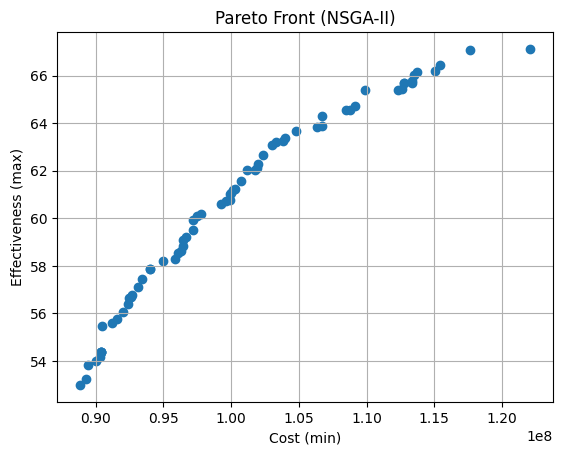

In [26]:
import matplotlib.pyplot as plt

pareto_front = tools.sortNondominated(population, len(population), first_front_only=True)[0]

costs = [ind.fitness.values[0] for ind in pareto_front]
effects = [ind.fitness.values[1] for ind in pareto_front]

plt.scatter(costs, effects)
plt.xlabel("Cost (min)")
plt.ylabel("Effectiveness (max)")
plt.title("Pareto Front (NSGA-II)")
plt.grid()
plt.show()


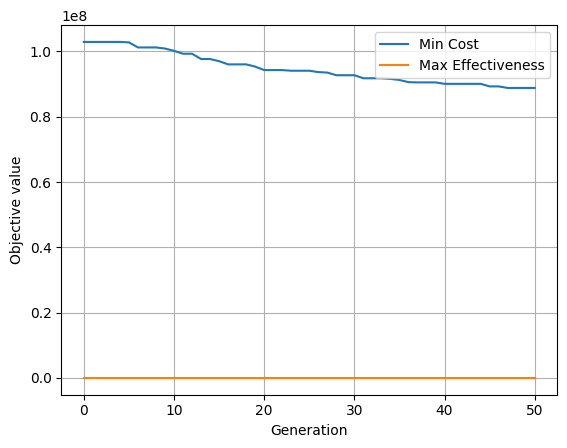

In [27]:
gen = logbook.select("gen")
min_cost = [m[0] for m in logbook.select("min")]
max_eff = [m[1] for m in logbook.select("max")]

plt.plot(gen, min_cost, label="Min Cost")
plt.plot(gen, max_eff, label="Max Effectiveness")
plt.xlabel("Generation")
plt.ylabel("Objective value")
plt.legend()
plt.grid()
plt.show()


In [8]:
COLUMN_MAP = {

    # ======================
    # 1️⃣ Risk Function
    # ======================

    # 신뢰도 → Failure_Rate 기반 (높을수록 나쁨)
    "reliability": "Failure_Rate",

    # 빔 방사 시간
    "beam_time": "Annual_Rad_Hours",

    # 환경 영향 (열화 + 환경 저항성 조합)
    "env_impact": "Rad_Degradation_Index",


    # ======================
    # 2️⃣ Supply Chain Function
    # ======================

    # 공급 안정성 → CSP 상태 (공급문제 여부)
    "supply_stability": "CSP_Status",

    # 조달 리드타임
    "lead_time": "Total_Lead_Time_H",

    # 공급 복잡도 proxy → Transport Time
    "supplier_count": "Transport_Time_H",


    # ======================
    # 3️⃣ Maintenance Function
    # ======================

    # 정비 시간 (예방 + 고장 평균)
    "maintenance_time": "PM_Time_Hours",

    # 하위 BOM 개수 proxy → Parent 구조 기반 계산 필요
    "bom_children": "Parent_ID",

    # BOM depth
    "bom_depth": "Level"
}


In [9]:
import pandas as pd
import numpy as np

df = pd.read_csv("radar_1000_parts_bom.csv")

print(df.shape)
df.head()


(1000, 31)


,Part_ID,Parent_ID,Level,Item_Type,Category,Maint_Action,Maint_Echelon,Unit_Price_KRW,Failure_Rate,MTBF_Hours,...,SoH_Score,PM_Cycle,PM_Maint_Hour_MH,PM_Cost_KRW,PM_Time_Hours,CM_Maint_Hour_MH,CM_Cost_KRW,CM_Time_Hours,Condemnation_Rate_Pct,CSP_Status
0,RAD-L1-0001,NaN,L1,Assembly (조립체),안테나체계,Repair (수리),창정비 (Depot),27229423,0.04485,195318,...,77.83,1Y,3.4,528467,4.1,41.2,18496371,84.8,1.52,Required
1,RAD-L2-0002,RAD-L1-0001,L2,Assembly (조립체),수신기세트,Repair (수리),창정비 (Depot),1007443,0.14718,59519,...,79.00,1Y,2.0,22256,2.4,39.7,778976,60.6,3.74,Optional
2,RAD-L3-0003,RAD-L2-0002,L3,Assembly (조립체),주요조립체_01,Replace,야전정비 (Intermediate),864576,0.03650,240000,...,73.00,6M,7.4,19766,8.9,14.0,691818,36.0,6.57,Optional
3,RAD-L4-0004,RAD-L3-0003,L4,Assembly (조립체),배선장치,Replace,야전정비 (Intermediate),477432,0.13926,62904,...,59.00,6M,4.2,13599,5.0,19.0,475978,42.5,93.59,Optional
4,RAD-L5-0005,RAD-L4-0004,L5,Part (단품),케이블조립체,Replace (교체),부대정비 (Organizational),330315,0.13982,62652,...,79.00,1Y,21.7,4742,26.0,4.4,165989,23.6,80.95,Optional


In [10]:
df["Obs_Risk_Label"].value_counts()


,count
Obs_Risk_Label,
High,377
Critical,235
Medium,200
Low,188


In [11]:
OBS_RISK_MAP = {
    "High": 1.0,
    "Medium": 0.5,
    "Low": 0.0,
    "Required": 1.0,
    "Optional": 0.5,
    "Not Required": 0.0
}

df["Obs_Risk_Score"] = df["Obs_Risk_Label"].map(OBS_RISK_MAP)


In [12]:
df["Obs_Risk_Score"] = df["Obs_Risk_Score"].fillna(0.5)


In [13]:
child_count = df.groupby("Parent_ID").size()

df["bom_children_calc"] = df["Part_ID"].map(child_count).fillna(0)


In [14]:
COLUMN_MAP = {

    # Risk
    "reliability": "Failure_Rate",
    "beam_time": "Annual_Rad_Hours",
    "env_impact": "Env_Resistance",

    # Supply chain
    "supply_stability": "Obs_Risk_Score",
    "lead_time": "Total_Lead_Time_H",
    "supplier_count": "Transport_Time_H",

    # Maintenance
    "maintenance_time": "CM_Time_Hours",
    "bom_children": "bom_children_calc",
    "bom_depth": "Level"
}


In [15]:
def normalize(col):
    col = col.astype(float)
    return (col - col.min()) / (col.max() - col.min() + 1e-9)


In [38]:
df_norm = df.copy()

for key, col in COLUMN_MAP.items():
    df_norm[key] = normalize(df[col])


ValueError: could not convert string to float: 'L1'

In [16]:
# 'L1', 'L2' → 1, 2
df["Level_num"] = (
    df["Level"]
    .astype(str)
    .str.replace("L", "", regex=False)
    .astype(int)
)


In [17]:
COLUMN_MAP["bom_depth"] = "Level_num"


In [18]:
df_norm = df.copy()

for key, col in COLUMN_MAP.items():
    df_norm[key] = normalize(df[col])


In [19]:
df["CM_Time_Hours"] = (
    df["CM_Time_Hours"]
    .astype(str)
    .str.replace(" h", "", regex=False)
    .astype(float)
)


In [20]:
import numpy as np

def risk_mean(x, df):
    x = np.array(x)
    return np.mean(x * (
        0.4 * (1 - df["reliability"].values) +
        0.3 * df["beam_time"].values +
        0.3 * df["env_impact"].values
    ))

def supply_mean(x, df):
    x = np.array(x)
    return np.mean(x * (
        0.5 * (1 - df["supply_stability"].values) +
        0.3 * df["lead_time"].values +
        0.2 * (1 - df["supplier_count"].values)
    ))

def maintenance_mean(x, df):
    x = np.array(x)
    return np.mean(x * (
        0.4 * df["maintenance_time"].values +
        0.4 * df["bom_children"].values +
        0.2 * df["bom_depth"].values
    ))


In [21]:
N_TEST = 20  # 테스트 개체 수

risk_vals = []
supply_vals = []
maint_vals = []

for _ in range(N_TEST):
    x = np.random.randint(0, 2, size=len(df_norm))

    risk_vals.append(risk_mean(x, df_norm))
    supply_vals.append(supply_mean(x, df_norm))
    maint_vals.append(maintenance_mean(x, df_norm))

# 결과 출력
for i in range(N_TEST):
    print(
        f"[{i:02d}] "
        f"Risk={risk_vals[i]:.4f} | "
        f"Supply={supply_vals[i]:.4f} | "
        f"Maint={maint_vals[i]:.4f}"
    )


[00] Risk=0.2647 | Supply=0.2187 | Maint=0.1635
[01] Risk=0.2763 | Supply=0.2246 | Maint=0.1754
[02] Risk=0.2830 | Supply=0.2332 | Maint=0.1829
[03] Risk=0.2645 | Supply=0.2155 | Maint=0.1648
[04] Risk=0.2648 | Supply=0.2204 | Maint=0.1665
[05] Risk=0.2722 | Supply=0.2200 | Maint=0.1728
[06] Risk=0.2683 | Supply=0.2158 | Maint=0.1663
[07] Risk=0.2670 | Supply=0.2213 | Maint=0.1713
[08] Risk=0.2773 | Supply=0.2243 | Maint=0.1712
[09] Risk=0.2600 | Supply=0.2139 | Maint=0.1665
[10] Risk=0.2737 | Supply=0.2255 | Maint=0.1724
[11] Risk=0.2607 | Supply=0.2124 | Maint=0.1625
[12] Risk=0.2689 | Supply=0.2229 | Maint=0.1712
[13] Risk=0.2535 | Supply=0.2121 | Maint=0.1628
[14] Risk=0.2755 | Supply=0.2333 | Maint=0.1761
[15] Risk=0.2712 | Supply=0.2233 | Maint=0.1726
[16] Risk=0.2775 | Supply=0.2318 | Maint=0.1772
[17] Risk=0.2673 | Supply=0.2165 | Maint=0.1697
[18] Risk=0.2771 | Supply=0.2276 | Maint=0.1755
[19] Risk=0.2651 | Supply=0.2166 | Maint=0.1696


In [22]:
print("\n=== Scale Summary ===")
print(f"Risk        : min={min(risk_vals):.4f}, max={max(risk_vals):.4f}")
print(f"Supply      : min={min(supply_vals):.4f}, max={max(supply_vals):.4f}")
print(f"Maintenance : min={min(maint_vals):.4f}, max={max(maint_vals):.4f}")



=== Scale Summary ===
Risk        : min=0.2535, max=0.2830
Supply      : min=0.2121, max=0.2333
Maintenance : min=0.1625, max=0.1829


In [38]:
!pip -q install pymoo

import numpy as np
import pandas as pd

from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.core.problem import Problem
from pymoo.optimize import minimize
from pymoo.termination import get_termination


# ============================================================
# 0) Load data (CSV)
# ============================================================
CSV_PATH = "radar_1000_parts_bom.csv"   # 너 파일명에 맞게 수정
df = pd.read_csv(CSV_PATH)
df.columns = [c.strip() for c in df.columns]
N = len(df)
print("Loaded:", CSV_PATH, "N=", N)


# ============================================================
# 1) Column mapping (이전 평균스케일 기준으로 사용했던 매핑)
#    (필요하면 여기만 네 실제 컬럼명으로 수정)
# ============================================================
COLUMN_MAP = {
    # Risk
    "reliability": "Failure_Rate",      # 높을수록 나쁨
    "beam_time": "Annual_Rad_Hours",
    "env_impact": "Env_Resistance",     # 높을수록 좋다면 뒤집기 필요

    # Supply
    "supply_stability": "Obs_Risk_Label",   # 라벨이면 수치화 필요
    "lead_time": "Total_Lead_Time_H",
    "supplier_count": "Transport_Time_H",

    # Maintenance
    "maintenance_time": "CM_Time_Hours",
    "bom_children": "Parent_ID",        # 필요 시 파생
    "bom_depth": "Level",

    # Cost (옵션)
    "unit_price": "Unit_Price_KRW"
}

# ============================================================
# 2) Preprocess helpers
# ============================================================
def to_numeric_series(s):
    return pd.to_numeric(s, errors="coerce")

def label_to_score(s):
    # Obs_Risk_Label이 텍스트일 경우를 대비
    raw = s.astype(str).str.strip().str.lower()
    m = {"required":1.0,"high":1.0,"h":1.0,
         "medium":0.5,"m":0.5,
         "optional":0.5,
         "low":0.0,"l":0.0}
    return raw.map(lambda z: m.get(z, np.nan)).astype(float)

def robust_norm(x):
    x = np.asarray(x, float)
    med = np.nanmedian(x)
    iqr = np.nanpercentile(x, 75) - np.nanpercentile(x, 25)
    if not np.isfinite(iqr) or iqr == 0:
        return np.zeros_like(x)
    z = (x - med) / iqr
    # squash to 0~1
    y = 1/(1+np.exp(-z))
    return y

def rank_norm(x):
    x = np.asarray(x, float)
    order = np.argsort(x)
    r = np.empty_like(order, dtype=float)
    r[order] = np.linspace(0, 1, len(x))
    return r

def masked_mean_penalty(x, v, alpha=0.4):
    x = np.asarray(x, float)
    v = np.asarray(v, float)
    sel = x > 0.5
    if sel.sum() == 0:
        return 1.0  # 선택 0이면 최악(큰 값)으로
    base = float(np.mean(v[sel]))
    # 너무 적게 고르면 패널티(선택률이 alpha보다 작으면 벌점)
    ratio = sel.mean()
    if ratio < alpha:
        base = base + (alpha - ratio) * 0.5
    return base


# ============================================================
# 3) Build df_norm (robust/rank 기반)
# ============================================================
df_norm = pd.DataFrame(index=df.index)

# reliability (Failure_Rate) : 높을수록 나쁨 → 그대로 (0~1)
df_norm["reliability"] = rank_norm(to_numeric_series(df[COLUMN_MAP["reliability"]]).fillna(
    to_numeric_series(df[COLUMN_MAP["reliability"]]).median()
))

# beam_time
df_norm["beam_time"] = robust_norm(to_numeric_series(df[COLUMN_MAP["beam_time"]]).fillna(
    to_numeric_series(df[COLUMN_MAP["beam_time"]]).median()
))

# env_impact (Env_Resistance가 높을수록 좋다면 1-로 뒤집기)
env_raw = to_numeric_series(df[COLUMN_MAP["env_impact"]]).fillna(
    to_numeric_series(df[COLUMN_MAP["env_impact"]]).median()
)
df_norm["env_impact"] = 1.0 - robust_norm(env_raw)   # 🔥 뒤집어서 "높을수록 나쁨"으로 통일

# supply_stability (라벨이면 수치화 후 정규화)
sup_raw = df[COLUMN_MAP["supply_stability"]]
sup_score = label_to_score(sup_raw)
sup_score = sup_score.fillna(sup_score.median() if np.isfinite(sup_score.median()) else 0.5)
df_norm["supply_stability"] = sup_score.to_numpy(float)

# lead_time
df_norm["lead_time"] = robust_norm(to_numeric_series(df[COLUMN_MAP["lead_time"]]).fillna(
    to_numeric_series(df[COLUMN_MAP["lead_time"]]).median()
))

# supplier_count proxy (transport)
df_norm["supplier_count"] = robust_norm(to_numeric_series(df[COLUMN_MAP["supplier_count"]]).fillna(
    to_numeric_series(df[COLUMN_MAP["supplier_count"]]).median()
))

# maintenance_time
df_norm["maintenance_time"] = robust_norm(to_numeric_series(df[COLUMN_MAP["maintenance_time"]]).fillna(
    to_numeric_series(df[COLUMN_MAP["maintenance_time"]]).median()
))

# bom_depth (Level이 L1 같은 문자열이면 숫자화)
lvl = df[COLUMN_MAP["bom_depth"]].astype(str).str.replace("L","", regex=False)
lvl_num = pd.to_numeric(lvl, errors="coerce").fillna(pd.to_numeric(lvl, errors="coerce").median())
df_norm["bom_depth"] = robust_norm(lvl_num)

# bom_children: Parent_ID로부터 "자식 수" 파생 (없으면 0)
if COLUMN_MAP["bom_children"] in df.columns:
    parent = df[COLUMN_MAP["bom_children"]].astype(str)
    child_cnt = parent.value_counts()
    df_norm["bom_children"] = robust_norm(parent.map(child_cnt).astype(float))
else:
    df_norm["bom_children"] = 0.0

# cost (옵션)
if COLUMN_MAP["unit_price"] in df.columns:
    df_norm["unit_price"] = robust_norm(to_numeric_series(df[COLUMN_MAP["unit_price"]]).fillna(
        to_numeric_series(df[COLUMN_MAP["unit_price"]]).median()
    ))
else:
    df_norm["unit_price"] = 0.0


# ============================================================
# 4) Define objectives (합 기반 + 비선형 확대)
# ============================================================
ALPHA = 0.20   # 선택률 패널티 기준(너가 원하는 low-cost 구간 보이려면 더 낮게)
PWR = 3        # 비선형 확대(2~4 추천)

def risk_obj(x):
    v = (0.5*df_norm["reliability"].values
         + 0.2*df_norm["beam_time"].values
         + 0.3*df_norm["env_impact"].values)
    base = masked_mean_penalty(x, v, ALPHA)
    return base**PWR

def supply_obj(x):
    v = (0.5*df_norm["supply_stability"].values
         + 0.3*df_norm["lead_time"].values
         + 0.2*df_norm["supplier_count"].values)
    base = masked_mean_penalty(x, v, ALPHA)
    return base**PWR

def maint_obj(x):
    v = (0.6*df_norm["maintenance_time"].values
         + 0.2*df_norm["bom_children"].values
         + 0.2*df_norm["bom_depth"].values)
    base = masked_mean_penalty(x, v, ALPHA)
    return base**PWR


# ============================================================
# 5) Scale summary (랜덤 샘플로 min/max 확인)
# ============================================================
def scale_summary(samples=2000):
    R,S,M = [],[],[]
    for _ in range(samples):
        x = np.random.randint(0,2,size=N)
        R.append(risk_obj(x))
        S.append(supply_obj(x))
        M.append(maint_obj(x))
    print("=== Scale Summary (random x) ===")
    print(f"Risk        : min={np.min(R):.4f}, max={np.max(R):.4f}")
    print(f"Supply      : min={np.min(S):.4f}, max={np.max(S):.4f}")
    print(f"Maintenance : min={np.min(M):.4f}, max={np.max(M):.4f}")

scale_summary()


# ============================================================
# 6) NSGA-II problem (3 objectives)
# ============================================================
class SpareNSGA(Problem):
    def __init__(self):
        super().__init__(n_var=N, n_obj=3, xl=0, xu=1, type_var=int)

    def _evaluate(self, X, out, *args, **kwargs):
        F = np.zeros((len(X), 3))
        for i, x in enumerate(X):
            F[i,0] = risk_obj(x)
            F[i,1] = supply_obj(x)
            F[i,2] = maint_obj(x)
        out["F"] = F

algorithm = NSGA2(pop_size=200)
termination = get_termination("n_gen", 10)

res = minimize(SpareNSGA(), algorithm, termination, seed=42, verbose=True)

F = res.F
print("\n✅ Pareto count:", len(F))
print(pd.DataFrame(F, columns=["Risk","Supply","Maintenance"]).describe())


Loaded: radar_1000_parts_bom.csv N= 1000
=== Scale Summary (random x) ===
Risk        : min=0.1201, max=0.1450
Supply      : min=0.1806, max=0.2233
Maintenance : min=0.0252, max=0.0315
n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |      200 |     29 |             - |             -
     2 |      400 |     25 |  0.0536410087 |         ideal
     3 |      600 |     24 |  0.1738097408 |         ideal
     4 |      800 |     26 |  0.0754978148 |         ideal
     5 |     1000 |     36 |  0.1255593505 |         ideal
     6 |     1200 |     38 |  0.0732272779 |         ideal
     7 |     1400 |     40 |  0.0993902080 |         ideal
     8 |     1600 |     42 |  0.1656338863 |         ideal
     9 |     1800 |     41 |  0.0704316705 |         ideal
    10 |     2000 |     51 |  0.0714708627 |         ideal

✅ Pareto count: 51
            Risk     Supply  Maintenance
count  51.000000  51.000000    51.000000
mean    0.120784   0.188585     0.026497
std     0.004773   0.01

In [39]:
# =========================
# 1) Maintenance input을 rank_norm으로 재정의
# =========================
df_norm["maintenance_time_r"] = rank_norm(
    to_numeric_series(df[COLUMN_MAP["maintenance_time"]]).fillna(
        to_numeric_series(df[COLUMN_MAP["maintenance_time"]]).median()
    )
)

df_norm["bom_depth_r"] = rank_norm(lvl_num)

if COLUMN_MAP["bom_children"] in df.columns:
    parent = df[COLUMN_MAP["bom_children"]].astype(str)
    child_cnt = parent.value_counts()
    child_raw = parent.map(child_cnt).astype(float).fillna(0)
    df_norm["bom_children_r"] = rank_norm(child_raw)
else:
    df_norm["bom_children_r"] = np.zeros(N)

# =========================
# 2) Objective definitions (Maintenance만 구조 변경)
# =========================
ALPHA = 0.20
PWR = 2

BETA_M = 0.60   # 🔥 "적게 사면 정비가 불리" 강도 (0.3~1.0)
def maint_obj(x):
    x = np.asarray(x, float)
    sel = x > 0.5
    if sel.sum() == 0:
        return 1.0

    v = (0.6*df_norm["maintenance_time_r"].values +
         0.2*df_norm["bom_children_r"].values +
         0.2*df_norm["bom_depth_r"].values)

    mean_v = float(np.mean(v[sel]))
    sel_ratio = float(sel.mean())

    # 선택을 적게 하면 정비망/구성품 커버가 부족하다는 현실 반영
    base = mean_v + BETA_M * (1.0 - sel_ratio)

    # 기존 alpha penalty도 유지(약하게)
    if sel_ratio < ALPHA:
        base += (ALPHA - sel_ratio) * 0.5

    return base**PWR

# risk/supply는 기존 그대로 쓰되 PWR을 2로 낮춰서 값 압축 방지
PWR = 2

def risk_obj(x):
    v = (0.5*df_norm["reliability"].values
         + 0.2*df_norm["beam_time"].values
         + 0.3*df_norm["env_impact"].values)
    base = masked_mean_penalty(x, v, ALPHA)
    return base**PWR

def supply_obj(x):
    v = (0.5*df_norm["supply_stability"].values
         + 0.3*df_norm["lead_time"].values
         + 0.2*df_norm["supplier_count"].values)
    base = masked_mean_penalty(x, v, ALPHA)
    return base**PWR

# =========================
# 3) 각 목적함수 출력 스케일을 0~1로 정규화 (랜덤 샘플 기반)
# =========================
def estimate_minmax(func, samples=3000):
    vals = []
    for _ in range(samples):
        x = np.random.randint(0,2,size=N)
        vals.append(func(x))
    return float(np.min(vals)), float(np.max(vals))

rmin, rmax = estimate_minmax(risk_obj)
smin, smax = estimate_minmax(supply_obj)
mmin, mmax = estimate_minmax(maint_obj)

print("Estimated min/max:")
print("Risk:", rmin, rmax)
print("Supply:", smin, smax)
print("Maint:", mmin, mmax)

def norm01(v, vmin, vmax):
    return (v - vmin) / ( (vmax - vmin) + 1e-12 )

def risk_obj_n(x):   return norm01(risk_obj(x), rmin, rmax)
def supply_obj_n(x): return norm01(supply_obj(x), smin, smax)
def maint_obj_n(x):  return norm01(maint_obj(x), mmin, mmax)

# =========================
# 4) Scale summary 다시 확인
# =========================
def scale_summary(samples=2000):
    R,S,M = [],[],[]
    for _ in range(samples):
        x = np.random.randint(0,2,size=N)
        R.append(risk_obj_n(x))
        S.append(supply_obj_n(x))
        M.append(maint_obj_n(x))
    print("=== Scale Summary (normalized 0~1) ===")
    print(f"Risk        : min={np.min(R):.4f}, max={np.max(R):.4f}")
    print(f"Supply      : min={np.min(S):.4f}, max={np.max(S):.4f}")
    print(f"Maintenance : min={np.min(M):.4f}, max={np.max(M):.4f}")

scale_summary()


Estimated min/max:
Risk: 0.24202003858441223 0.2755861062353874
Supply: 0.3217849303252216 0.3730421486004626
Maint: 0.5784926402102943 0.7067799944907012
=== Scale Summary (normalized 0~1) ===
Risk        : min=0.0656, max=0.9912
Supply      : min=-0.0355, max=0.9376
Maintenance : min=-0.0059, max=0.9477


In [40]:
# ===== Cost column (robust find) =====
def find_col(df_cols, candidates):
    cols = list(df_cols)
    norm = {str(c).strip().lower(): c for c in cols}
    for cand in candidates:
        k = str(cand).strip().lower()
        if k in norm:
            return norm[k]
    for cand in candidates:
        ck = str(cand).strip().lower().replace("_","")
        for c in cols:
            nk = str(c).strip().lower().replace("_","")
            if ck and (ck in nk or nk in ck):
                return c
    return None

COST_COL = find_col(df.columns, ["Unit_Price_KRW", "unit_price_krw", "UnitPriceKRW"])
print("✅ COST_COL:", COST_COL)

assert COST_COL is not None, "Unit_Price_KRW 컬럼을 못 찾았습니다."

# numeric + fill
cost_raw = pd.to_numeric(df[COST_COL], errors="coerce")
cost_raw = cost_raw.fillna(cost_raw.median() if np.isfinite(cost_raw.median()) else 0.0).astype(float)

# per-part cost vector normalized 0~1 (robust or rank)
df_norm["unit_price_r"] = rank_norm(cost_raw.values)   # rank로 퍼뜨리기(추천)


✅ COST_COL: Unit_Price_KRW


In [41]:
# =========================
# Cost objective (sum 기반)
# =========================
price_vec = cost_raw.values.astype(float)

def cost_obj(x):
    x = np.asarray(x, float)
    return float(np.sum(x * price_vec))

# min/max 추정 (랜덤 샘플)
cmin, cmax = estimate_minmax(cost_obj, samples=3000)
print("Cost min/max:", cmin, cmax)

def cost_obj_n(x):
    return norm01(cost_obj(x), cmin, cmax)


Cost min/max: 98451313.0 152316363.0


In [42]:
def scale_summary_4(samples=2000):
    R,S,M,C = [],[],[],[]
    for _ in range(samples):
        x = np.random.randint(0,2,size=N)
        R.append(risk_obj_n(x))
        S.append(supply_obj_n(x))
        M.append(maint_obj_n(x))
        C.append(cost_obj_n(x))
    print("=== Scale Summary (normalized 0~1) ===")
    print(f"Risk        : min={np.min(R):.4f}, max={np.max(R):.4f}")
    print(f"Supply      : min={np.min(S):.4f}, max={np.max(S):.4f}")
    print(f"Maintenance : min={np.min(M):.4f}, max={np.max(M):.4f}")
    print(f"Cost        : min={np.min(C):.4f}, max={np.max(C):.4f}")

scale_summary_4()


=== Scale Summary (normalized 0~1) ===
Risk        : min=-0.0145, max=1.0342
Supply      : min=0.0023, max=0.9967
Maintenance : min=0.0407, max=1.0960
Cost        : min=0.0121, max=0.9878


In [43]:
class SpareNSGA4(Problem):
    def __init__(self):
        super().__init__(n_var=N, n_obj=4, xl=0, xu=1, type_var=int)

    def _evaluate(self, X, out, *args, **kwargs):
        F = np.zeros((len(X), 4))
        for i, x in enumerate(X):
            F[i,0] = risk_obj_n(x)
            F[i,1] = supply_obj_n(x)
            F[i,2] = maint_obj_n(x)
            F[i,3] = cost_obj_n(x)   # ✅ cost 추가
        out["F"] = F

algorithm = NSGA2(pop_size=260)
termination = get_termination("n_gen", 10)

res = minimize(SpareNSGA4(), algorithm, termination, seed=42, verbose=True)
F = res.F

print("\n✅ Pareto count:", len(F))
df_pf = pd.DataFrame(F, columns=["Risk","Supply","Maintenance","Cost"])
print(df_pf.describe())


n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |      260 |     57 |             - |             -
     2 |      520 |     60 |  0.0919455200 |         ideal
     3 |      780 |     96 |  0.1793500467 |         ideal
     4 |     1040 |    131 |  0.0298635237 |         ideal
     5 |     1300 |    176 |  0.0353274560 |         ideal
     6 |     1560 |    229 |  0.0359932156 |         ideal
     7 |     1820 |    257 |  0.0532062970 |         ideal
     8 |     2080 |    260 |  0.0581631857 |         ideal
     9 |     2340 |    260 |  0.0309194586 |         ideal
    10 |     2600 |    260 |  0.0437900891 |         ideal

✅ Pareto count: 260
             Risk      Supply  Maintenance        Cost
count  260.000000  260.000000   260.000000  260.000000
mean     0.294197    0.247363     0.357513    0.362689
std      0.198026    0.207450     0.235815    0.186754
min     -0.109678   -0.200650    -0.082562    0.084019
25%      0.145588    0.096293     0.172622    0.228818


Cost KRW min/max (random x): 99825723.0 154749053.0
n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |      260 |     57 |             - |             -
     2 |      520 |     60 |  0.0919455200 |         ideal
     3 |      780 |     96 |  0.1793500467 |         ideal
     4 |     1040 |    131 |  0.0298635237 |         ideal
     5 |     1300 |    176 |  0.0353274560 |         ideal
     6 |     1560 |    229 |  0.0359932156 |         ideal
     7 |     1820 |    257 |  0.0532062970 |         ideal
     8 |     2080 |    260 |  0.0581631857 |         ideal
     9 |     2340 |    260 |  0.0309194586 |         ideal
    10 |     2600 |    260 |  0.0437900891 |         ideal
✅ Pareto count: 260


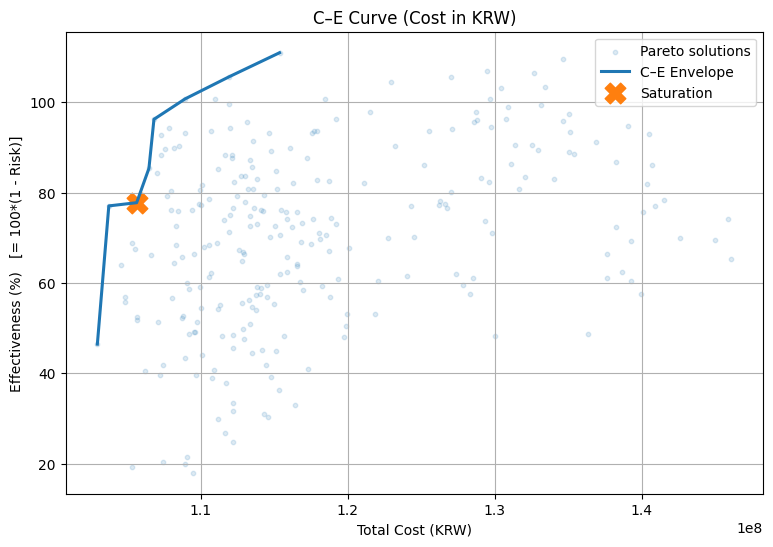


📌 Saturation point:
 - Cost (KRW): 105,649,639
 - Effectiveness (%): 77.77


In [44]:
# =========================
# 1) Cost (KRW) + Cost_norm (NSGA용)
# =========================
COST_COL = find_col(df.columns, ["Unit_Price_KRW", "unit_price_krw", "UnitPriceKRW"])
assert COST_COL is not None, "Unit_Price_KRW 컬럼을 못 찾았습니다."

price_vec = pd.to_numeric(df[COST_COL], errors="coerce")
price_vec = price_vec.fillna(price_vec.median() if np.isfinite(price_vec.median()) else 0.0).astype(float).values

def cost_krw(x):
    x = np.asarray(x, float)
    return float(np.sum(x * price_vec))

# NSGA 내부 밸런스를 위해 0~1 정규화(하지만 CE plot에는 사용 안 함)
cmin, cmax = estimate_minmax(cost_krw, samples=4000)
def cost_norm(x):
    return norm01(cost_krw(x), cmin, cmax)

print("Cost KRW min/max (random x):", cmin, cmax)


# =========================
# 2) 4-objective NSGA-II (Cost는 cost_norm으로)
# =========================
class SpareNSGA4(Problem):
    def __init__(self):
        super().__init__(n_var=N, n_obj=4, xl=0, xu=1, type_var=int)

    def _evaluate(self, X, out, *args, **kwargs):
        F = np.zeros((len(X), 4))
        for i, x in enumerate(X):
            F[i,0] = risk_obj_n(x)
            F[i,1] = supply_obj_n(x)
            F[i,2] = maint_obj_n(x)
            F[i,3] = cost_norm(x)  # ✅ NSGA에는 정규화 cost
        out["F"] = F

algorithm = NSGA2(pop_size=260)
termination = get_termination("n_gen", 10)

res = minimize(SpareNSGA4(), algorithm, termination, seed=42, verbose=True)

X_pf = res.X
F_pf = res.F
print("✅ Pareto count:", len(X_pf))


# =========================
# 3) C–E curve용: Cost는 KRW, Effectiveness는 Availability(%)로
#    ※ 여기서는 Effectiveness를 risk의 반대(1 - Risk_norm)로 일단 정의
#       (너가 Availability proxy를 따로 쓰면 그걸로 바꾸면 됨)
# =========================
Cost_KRW = np.array([cost_krw(x) for x in X_pf], float)

# Effectiveness: (1 - Risk) 형태 (risk_obj_n은 0~1로 낮을수록 좋음)
Eff = np.array([1.0 - risk_obj_n(x) for x in X_pf], float) * 100.0

# envelope (예산에서 가능한 최고 효율)
order = np.argsort(Cost_KRW)
c_sorted = Cost_KRW[order]
e_sorted = Eff[order]

envC, envE = [], []
best = -1e18
for c,e in zip(c_sorted, e_sorted):
    if e > best + 1e-9:
        envC.append(c); envE.append(e); best = e
envC = np.array(envC); envE = np.array(envE)

# saturation: 개선폭이 작아지는 지점(기울기 기반)
dE = np.diff(envE)
dC = np.diff(envC) + 1e-9
slope = dE / dC
# slope가 최댓값의 5% 미만으로 떨어지는 첫 지점
thr = 0.05 * np.max(slope) if len(slope)>0 else 0
sat_idx = np.where(slope < thr)[0]
sat_i = int(sat_idx[0]+1) if len(sat_idx)>0 else len(envC)-1

sat_cost = float(envC[sat_i])
sat_eff  = float(envE[sat_i])

# plot
import matplotlib.pyplot as plt
plt.figure(figsize=(9,6))
plt.scatter(Cost_KRW, Eff, s=10, alpha=0.15, label="Pareto solutions")
plt.plot(envC, envE, linewidth=2.2, label="C–E Envelope")
plt.scatter([sat_cost], [sat_eff], marker="X", s=220, label="Saturation")
plt.xlabel("Total Cost (KRW)")
plt.ylabel("Effectiveness (%)   [= 100*(1 - Risk)]")
plt.title("C–E Curve (Cost in KRW)")
plt.grid(True)
plt.legend()
plt.show()

print("\n📌 Saturation point:")
print(" - Cost (KRW):", f"{sat_cost:,.0f}")
print(" - Effectiveness (%):", f"{sat_eff:.2f}")



Loaded: radar_1000_parts_bom.csv N= 1000

=== Column mapping ===
Failure: Failure_Rate
CM     : CM_Time_Hours
Lead   : Total_Lead_Time_H
Trans  : Transport_Time_H
Obs    : Obs_Risk_Label
Level  : Level
Parent : Parent_ID
Beam   : Annual_Rad_Hours
Env    : Env_Resistance
Cost   : Unit_Price_KRW

=== Scale Summary (normalized 0~1) ===
Risk        : min=0.0487, max=0.9687
Supply      : min=0.0210, max=0.9886
Maintenance : min=-0.0650, max=0.9384
Cost_norm   : min=-0.0212, max=1.0195

Availability sanity:
A(x=0)%  : 80.57
A(x=all)%: 88.11
n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |      260 |     57 |             - |             -
     2 |      520 |     60 |  0.0919455200 |         ideal
     3 |      780 |     96 |  0.1793500467 |         ideal
     4 |     1040 |    131 |  0.0298635237 |         ideal
     5 |     1300 |    176 |  0.0353274560 |         ideal
     6 |     1560 |    229 |  0.0359932156 |         ideal
     7 |     1820 |    257 |  0.0532062970 |  

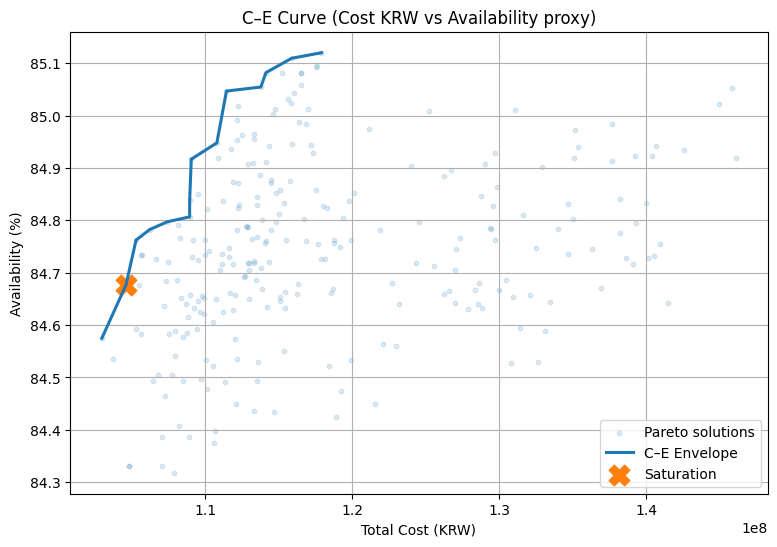


📌 Saturation point:
 - Total Cost (KRW): 104,615,701
 - Availability (%): 84.68

✅ Saturation spares exported:
 - selected parts: 0
 - total cost (KRW): 0
Files: /content/saturation_spares.csv /content/saturation_spares.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

,Part_Key,Unit_Price_KRW,Total_Cost_KRW


In [45]:
# ============================================================
# 4-objective NSGA-II + C-E Curve (Cost KRW vs Availability %)
#  - Objectives for NSGA: Risk(0-1), Supply(0-1), Maint(0-1), Cost_norm(0-1)
#  - C-E for analysis: x = Total Cost (KRW), y = Availability (%)
#  - Export saturation spares list (CSV/XLSX)
# ============================================================

!pip -q install pymoo openpyxl

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.core.problem import Problem
from pymoo.optimize import minimize
from pymoo.termination import get_termination

# ----------------------------
# 0) Load CSV
# ----------------------------
CSV_PATH = "radar_1000_parts_bom.csv"  # <- 파일명수정
df = pd.read_csv(CSV_PATH)
df.columns = [str(c).strip() for c in df.columns]
N = len(df)
HOURS_PER_YEAR = 8760.0
print("Loaded:", CSV_PATH, "N=", N)

# ----------------------------
# 1) Helpers
# ----------------------------
def find_col(df_cols, candidates):
    cols = list(df_cols)
    norm = {str(c).strip().lower(): c for c in cols}
    for cand in candidates:
        k = str(cand).strip().lower()
        if k in norm:
            return norm[k]
    for cand in candidates:
        ck = str(cand).strip().lower().replace("_","")
        for c in cols:
            nk = str(c).strip().lower().replace("_","")
            if ck and (ck in nk or nk in ck):
                return c
    return None

def to_num(s, fill="median"):
    x = pd.to_numeric(s, errors="coerce")
    if fill == "median":
        med = x.median()
        if not np.isfinite(med): med = 0.0
        x = x.fillna(med)
    elif fill == "zero":
        x = x.fillna(0.0)
    return x.astype(float).to_numpy()

def label_to_score(s):
    raw = s.astype(str).str.strip().str.lower()
    m = {"required":1.0,"high":1.0,"h":1.0,
         "medium":0.5,"m":0.5,
         "optional":0.5,
         "low":0.0,"l":0.0}
    out = raw.map(lambda z: m.get(z, np.nan)).astype(float)
    med = out.median()
    if not np.isfinite(med): med = 0.5
    return out.fillna(med).to_numpy()

def rank_norm(x):
    x = np.asarray(x, float)
    order = np.argsort(x)
    r = np.empty_like(order, dtype=float)
    r[order] = np.linspace(0, 1, len(x))
    return r

def robust_norm(x):
    x = np.asarray(x, float)
    med = np.nanmedian(x)
    iqr = np.nanpercentile(x, 75) - np.nanpercentile(x, 25)
    if not np.isfinite(iqr) or iqr == 0:
        return np.zeros_like(x)
    z = (x - med) / iqr
    return 1/(1+np.exp(-z))

def masked_mean_penalty(x, v, alpha=0.20):
    x = np.asarray(x, float)
    v = np.asarray(v, float)
    sel = x > 0.5
    if sel.sum() == 0:
        return 1.0
    base = float(np.mean(v[sel]))
    ratio = float(sel.mean())
    if ratio < alpha:
        base = base + (alpha - ratio) * 0.5
    return base

def estimate_minmax(func, samples=4000, seed=7):
    rng = np.random.default_rng(seed)
    vals = []
    for _ in range(samples):
        x = rng.integers(0, 2, size=N)
        vals.append(func(x))
    return float(np.min(vals)), float(np.max(vals))

def norm01(v, vmin, vmax):
    return (v - vmin) / ((vmax - vmin) + 1e-12)

def envelope(cost, eff):
    order = np.argsort(cost)
    cost = cost[order]; eff = eff[order]
    envC, envE = [], []
    best = -1e18
    for c, e in zip(cost, eff):
        if e > best + 1e-9:
            envC.append(c); envE.append(e); best = e
    return np.array(envC), np.array(envE)

# ----------------------------
# 2) Column mapping (auto)
#    - 너 데이터 기준으로 최대한 자동 찾기
# ----------------------------
FAIL_COL  = find_col(df.columns, ["Failure_Rate"])
CM_COL    = find_col(df.columns, ["CM_Time_Hours", "Maintenance_Time"])
LEAD_COL  = find_col(df.columns, ["Total_Lead_Time_H", "Procurement_Lead_Time"])
TRANS_COL = find_col(df.columns, ["Transport_Time_H"])
OBS_COL   = find_col(df.columns, ["Obs_Risk_Label", "Obs_Risk_Lable"])
LEVEL_COL = find_col(df.columns, ["Level", "BOM_Level"])
PARENT_COL= find_col(df.columns, ["Parent_ID"])
BEAM_COL  = find_col(df.columns, ["Annual_Rad_Hours","Beam_Radiation_Time"])
ENV_COL   = find_col(df.columns, ["Env_Resistance","Environmental_Impact"])
COST_COL  = find_col(df.columns, ["Unit_Price_KRW","unit_price_krw","UnitPriceKRW"])

print("\n=== Column mapping ===")
print("Failure:", FAIL_COL)
print("CM     :", CM_COL)
print("Lead   :", LEAD_COL)
print("Trans  :", TRANS_COL)
print("Obs    :", OBS_COL)
print("Level  :", LEVEL_COL)
print("Parent :", PARENT_COL)
print("Beam   :", BEAM_COL)
print("Env    :", ENV_COL)
print("Cost   :", COST_COL)

assert FAIL_COL and CM_COL and COST_COL, "필수 컬럼(Failure_Rate, CM_Time_Hours, Unit_Price_KRW)을 못 찾았습니다."

fail_yr = to_num(df[FAIL_COL], fill="median")   # failures/year (MIL-HDBK-217 논리: 연간고장율로 간주)
cm_hr   = to_num(df[CM_COL], fill="median")     # hours
price_vec = to_num(df[COST_COL], fill="median") # KRW

lead_hr  = to_num(df[LEAD_COL], fill="median") if LEAD_COL else np.zeros(N)
trans_hr = to_num(df[TRANS_COL], fill="median") if TRANS_COL else np.zeros(N)
wait_hr  = lead_hr + trans_hr

# risk weight (0.5~1.5)
if OBS_COL:
    obs = label_to_score(df[OBS_COL])
else:
    # 없으면 wait 기반 proxy
    mn, mx = float(np.min(wait_hr)), float(np.max(wait_hr))
    obs = np.zeros(N) if mx == mn else (wait_hr - mn)/(mx - mn)
obs = np.clip(obs, 0, 1)
risk_weight = 0.5 + obs

# bom depth
if LEVEL_COL:
    lvl = df[LEVEL_COL].astype(str).str.strip().str.replace("L","", regex=False)
    lvl_num = pd.to_numeric(lvl, errors="coerce")
    med = lvl_num.median()
    if not np.isfinite(med): med = 1.0
    lvl_num = lvl_num.fillna(med).astype(float)
else:
    lvl_num = pd.Series(np.ones(N))

# bom children proxy from Parent_ID
if PARENT_COL:
    parent = df[PARENT_COL].astype(str)
    child_cnt = parent.value_counts()
    child_raw = parent.map(child_cnt).astype(float).fillna(0.0)
else:
    child_raw = pd.Series(np.zeros(N))

# beam/env (없으면 0 벡터로)
beam_raw = to_num(df[BEAM_COL], fill="median") if BEAM_COL else np.zeros(N)
env_raw  = to_num(df[ENV_COL], fill="median")  if ENV_COL else np.zeros(N)

# ----------------------------
# 3) Build normalized feature table for objectives
#    - Risk/Supply/Maint 모두 0~1에서 변별력 크게
# ----------------------------
df_norm = pd.DataFrame(index=df.index)

# Risk components
df_norm["reliability"] = rank_norm(fail_yr)                # fail_yr 높을수록 나쁨
df_norm["beam_time"]   = robust_norm(beam_raw)             # 높을수록 나쁨(가정)
df_norm["env_impact"]  = 1.0 - robust_norm(env_raw)        # Env_Resistance가 높을수록 좋다면 뒤집기

# Supply components (obs는 이미 0~1)
df_norm["supply_stability"] = obs                          # 1=리스크 큼(불안정)으로 해석
df_norm["lead_time"]        = robust_norm(lead_hr)
df_norm["supplier_count"]   = robust_norm(trans_hr)

# Maintenance components (rank로 강제 분산)
df_norm["maintenance_time_r"] = rank_norm(cm_hr)
df_norm["bom_children_r"]     = rank_norm(child_raw.to_numpy(float))
df_norm["bom_depth_r"]        = rank_norm(lvl_num.to_numpy(float))

# ----------------------------
# 4) Define 3 objectives (Risk/Supply/Maint) + normalize each to 0~1
# ----------------------------
ALPHA = 0.20
PWR = 2
BETA_M = 0.60

def risk_obj(x):
    v = (0.5*df_norm["reliability"].values
         + 0.2*df_norm["beam_time"].values
         + 0.3*df_norm["env_impact"].values)
    base = masked_mean_penalty(x, v, ALPHA)
    return base**PWR

def supply_obj(x):
    v = (0.5*df_norm["supply_stability"].values
         + 0.3*df_norm["lead_time"].values
         + 0.2*df_norm["supplier_count"].values)
    base = masked_mean_penalty(x, v, ALPHA)
    return base**PWR

def maint_obj(x):
    x = np.asarray(x, float)
    sel = x > 0.5
    if sel.sum() == 0:
        return 1.0
    v = (0.6*df_norm["maintenance_time_r"].values +
         0.2*df_norm["bom_children_r"].values +
         0.2*df_norm["bom_depth_r"].values)
    mean_v = float(np.mean(v[sel]))
    sel_ratio = float(sel.mean())
    base = mean_v + BETA_M*(1.0 - sel_ratio)
    if sel_ratio < ALPHA:
        base += (ALPHA - sel_ratio) * 0.5
    return base**PWR

# normalize 0~1
rmin, rmax = estimate_minmax(risk_obj)
smin, smax = estimate_minmax(supply_obj)
mmin, mmax = estimate_minmax(maint_obj)

def risk_obj_n(x):   return norm01(risk_obj(x),   rmin, rmax)
def supply_obj_n(x): return norm01(supply_obj(x), smin, smax)
def maint_obj_n(x):  return norm01(maint_obj(x),  mmin, mmax)

# ----------------------------
# 5) Cost for NSGA (norm) + Cost for C-E (KRW)
# ----------------------------
def cost_krw(x):
    x = np.asarray(x, float)
    return float(np.sum(x * price_vec))

cmin, cmax = estimate_minmax(cost_krw)
def cost_norm(x): return norm01(cost_krw(x), cmin, cmax)

print("\n=== Scale Summary (normalized 0~1) ===")
# quick random scale check
rng = np.random.default_rng(0)
R,S,M,C = [],[],[],[]
for _ in range(2000):
    x = rng.integers(0,2,size=N)
    R.append(risk_obj_n(x)); S.append(supply_obj_n(x)); M.append(maint_obj_n(x)); C.append(cost_norm(x))
print(f"Risk        : min={np.min(R):.4f}, max={np.max(R):.4f}")
print(f"Supply      : min={np.min(S):.4f}, max={np.max(S):.4f}")
print(f"Maintenance : min={np.min(M):.4f}, max={np.max(M):.4f}")
print(f"Cost_norm   : min={np.min(C):.4f}, max={np.max(C):.4f}")

# ----------------------------
# 6) Availability proxy (Effectiveness for C-E)
#    - 튜닝 영역: 여기 파라미터로 곡선 모양/포화 조절
# ----------------------------
ETA_WAIT   = 0.75
ETA_CM     = 0.20
MTTR_MIN_H = 24.0
GAMMA      = 0.0
KAPPA      = 0.0015

ADMIN_H_PER_FAIL = 24.0
FIXED_DOWNTIME_H_PER_YEAR = 1000.0

# Queueing 병목 사용 여부
USE_QUEUEING = True
MU_EVENTS_PER_YEAR = 40.0
Q_HOURS_PER_EVENT  = 36.0
ETA_LAMBDA_REDUCTION = 0.75

def availability_proxy(x):
    x = np.asarray(x, float)

    mttr_eff = (
        MTTR_MIN_H
        + cm_hr   * (1.0 - ETA_CM   * x)
        + wait_hr * (1.0 - ETA_WAIT * x)
        + GAMMA * wait_hr * risk_weight * (1.0 - x)
        + ADMIN_H_PER_FAIL
    )

    lam_eff = fail_yr * (1.0 - ETA_LAMBDA_REDUCTION * x)
    lam_eff = np.clip(lam_eff, 0.0, None)

    D_queue = 0.0
    if USE_QUEUEING:
        LAMBDA = float(np.sum(lam_eff))  # events/year
        rho = min(0.95, LAMBDA / max(1e-9, MU_EVENTS_PER_YEAR))
        Wq = Q_HOURS_PER_EVENT * (rho / max(1e-9, (1.0 - rho)))  # hours/event
        D_queue = KAPPA * LAMBDA * Wq

    D_yr = KAPPA * float(np.sum(lam_eff * mttr_eff)) + FIXED_DOWNTIME_H_PER_YEAR + D_queue
    A = 1.0 - D_yr / HOURS_PER_YEAR
    return float(np.clip(A, 0.0, 1.0))

print("\nAvailability sanity:")
print("A(x=0)%  :", round(availability_proxy(np.zeros(N))*100, 2))
print("A(x=all)%:", round(availability_proxy(np.ones(N))*100, 2))

# ----------------------------
# 7) NSGA-II 4-objective (Cost_norm 포함)
# ----------------------------
class SpareNSGA4(Problem):
    def __init__(self):
        super().__init__(n_var=N, n_obj=4, xl=0, xu=1, type_var=int)

    def _evaluate(self, X, out, *args, **kwargs):
        F = np.zeros((len(X), 4))
        for i, x in enumerate(X):
            F[i,0] = risk_obj_n(x)
            F[i,1] = supply_obj_n(x)
            F[i,2] = maint_obj_n(x)
            F[i,3] = cost_norm(x)   # 최적화는 정규화 cost
        out["F"] = F

algorithm = NSGA2(pop_size=260)
termination = get_termination("n_gen", 10)

res = minimize(SpareNSGA4(), algorithm, termination, seed=42, verbose=True)
X_pf = res.X
print("\n✅ Pareto count:", len(X_pf))

# ----------------------------
# 8) C-E Curve (Cost in KRW vs Availability %)
# ----------------------------
Cost_KRW = np.array([cost_krw(x) for x in X_pf], float)
Avail = np.array([availability_proxy(x) for x in X_pf], float) * 100.0

envC, envA = envelope(Cost_KRW, Avail)

# saturation (기울기 기반: marginal gain이 작아지는 첫 지점)
if len(envC) >= 3:
    dA = np.diff(envA)
    dC = np.diff(envC) + 1e-9
    slope = dA / dC
    thr = 0.05 * np.max(slope)  # 최대 기울기의 5% 이하로 떨어지는 지점
    idxs = np.where(slope < thr)[0]
    sat_i = int(idxs[0] + 1) if len(idxs) > 0 else len(envC) - 1
else:
    sat_i = len(envC) - 1

sat_cost = float(envC[sat_i])
sat_av   = float(envA[sat_i])

plt.figure(figsize=(9,6))
plt.scatter(Cost_KRW, Avail, s=10, alpha=0.15, label="Pareto solutions")
plt.plot(envC, envA, linewidth=2.2, label="C–E Envelope")
plt.scatter([sat_cost], [sat_av], marker="X", s=220, label="Saturation")
plt.xlabel("Total Cost (KRW)")
plt.ylabel("Availability (%)")
plt.title("C–E Curve (Cost KRW vs Availability proxy)")
plt.grid(True)
plt.legend()
plt.show()

print("\n📌 Saturation point:")
print(" - Total Cost (KRW):", f"{sat_cost:,.0f}")
print(" - Availability (%):", f"{sat_av:.2f}")

# ----------------------------
# 9) Extract saturation solution -> spares list export
#    - choose actual solution closest to saturation point on envelope
# ----------------------------
# find closest in (cost,avail) space among Pareto sols
dist = (Cost_KRW - sat_cost)**2 + (Avail - sat_av)**2
best_idx = int(np.argmin(dist))
x_sat = X_pf[best_idx].astype(int)

sel_idx = np.where(x_sat == 1)[0]
spares = df.iloc[sel_idx].copy()
spares["Unit_Price_KRW"] = price_vec[sel_idx]
spares["Total_Cost_KRW"] = spares["Unit_Price_KRW"]

key_col = find_col(df.columns, ["Part_ID","Part_Number","Item_ID","SKU","Name"])
spares["Part_Key"] = spares[key_col].astype(str) if key_col else spares.index.astype(str)

summary = (spares.groupby("Part_Key", as_index=False)
           .agg(Unit_Price_KRW=("Unit_Price_KRW","mean"),
                Total_Cost_KRW=("Total_Cost_KRW","sum"))
           .sort_values("Total_Cost_KRW", ascending=False))

csv_out  = "/content/saturation_spares.csv"
xlsx_out = "/content/saturation_spares.xlsx"
summary.to_csv(csv_out, index=False, encoding="utf-8-sig")
with pd.ExcelWriter(xlsx_out, engine="openpyxl") as w:
    summary.to_excel(w, index=False, sheet_name="Spares")

print("\n✅ Saturation spares exported:")
print(" - selected parts:", int(x_sat.sum()))
print(" - total cost (KRW):", f"{summary['Total_Cost_KRW'].sum():,.0f}")
print("Files:", csv_out, xlsx_out)

# (Colab) download links
from google.colab import files
files.download(csv_out)
files.download(xlsx_out)

display(summary.head(30))


Loaded: radar_1000_parts_bom.csv N= 1000

=== Column mapping ===
Failure: Failure_Rate
CM     : CM_Time_Hours
Lead   : Total_Lead_Time_H
Trans  : Transport_Time_H
Obs    : Obs_Risk_Label
Level  : Level
Parent : Parent_ID
Beam   : Annual_Rad_Hours
Env    : Env_Resistance
Cost   : Unit_Price_KRW

=== Scale Summary (normalized 0~1) ===
Risk        : min=0.0487, max=0.9687
Supply      : min=0.0210, max=0.9886
Maintenance : min=-0.0650, max=0.9384
Cost_norm   : min=-0.0212, max=1.0195
A(x=0)%  : 54.07
A(x=all)%: 88.11
n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |      260 |     57 |             - |             -
     2 |      520 |     60 |  0.0919455200 |         ideal
     3 |      780 |     96 |  0.1793500467 |         ideal
     4 |     1040 |    131 |  0.0298635237 |         ideal
     5 |     1300 |    176 |  0.0353274560 |         ideal
     6 |     1560 |    229 |  0.0359932156 |         ideal
     7 |     1820 |    257 |  0.0532062970 |         ideal
     8 | 

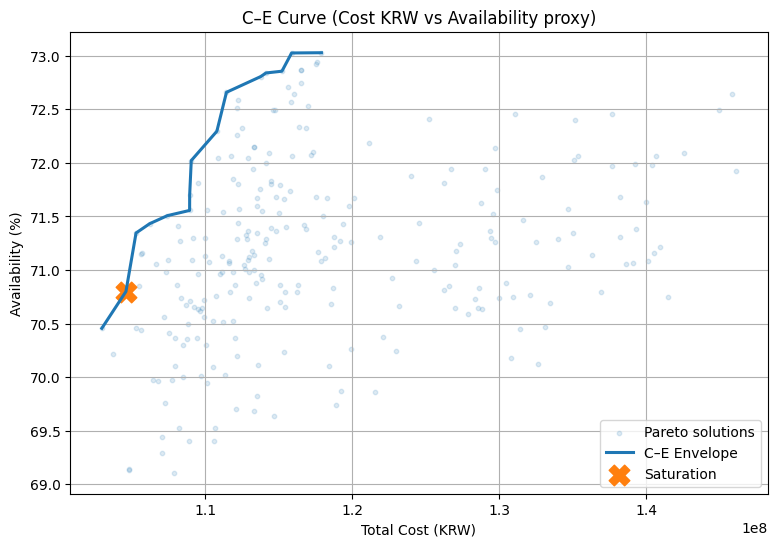


📌 Saturation point:
 - Total Cost (KRW): 104,615,701
 - Availability (%): 70.80

✅ Saturation spares exported:
 - selected parts: 0
 - total cost (KRW): 0
Files: /content/saturation_spares.csv /content/saturation_spares.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

,Part_Key,Unit_Price_KRW,Total_Cost_KRW


In [46]:
# ============================================================
# 4-objective NSGA-II + C-E Curve (Cost KRW vs Availability %)
#  - Objectives for NSGA: Risk(0-1), Supply(0-1), Maint(0-1), Cost_norm(0-1)
#  - C-E for analysis: x = Total Cost (KRW), y = Availability (%)
#  - Export saturation spares list (CSV/XLSX)
# ============================================================

!pip -q install pymoo openpyxl

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.core.problem import Problem
from pymoo.optimize import minimize
from pymoo.termination import get_termination

# ----------------------------
# 0) Load CSV
# ----------------------------
CSV_PATH = "radar_1000_parts_bom.csv"  # <- 파일명수정
df = pd.read_csv(CSV_PATH)
df.columns = [str(c).strip() for c in df.columns]
N = len(df)
HOURS_PER_YEAR = 8760.0
print("Loaded:", CSV_PATH, "N=", N)

# ----------------------------
# 1) Helpers
# ----------------------------
def find_col(df_cols, candidates):
    cols = list(df_cols)
    norm = {str(c).strip().lower(): c for c in cols}
    for cand in candidates:
        k = str(cand).strip().lower()
        if k in norm:
            return norm[k]
    for cand in candidates:
        ck = str(cand).strip().lower().replace("_","")
        for c in cols:
            nk = str(c).strip().lower().replace("_","")
            if ck and (ck in nk or nk in ck):
                return c
    return None

def to_num(s, fill="median"):
    x = pd.to_numeric(s, errors="coerce")
    if fill == "median":
        med = x.median()
        if not np.isfinite(med): med = 0.0
        x = x.fillna(med)
    elif fill == "zero":
        x = x.fillna(0.0)
    return x.astype(float).to_numpy()

def label_to_score(s):
    raw = s.astype(str).str.strip().str.lower()
    m = {"required":1.0,"high":1.0,"h":1.0,
         "medium":0.5,"m":0.5,
         "optional":0.5,
         "low":0.0,"l":0.0}
    out = raw.map(lambda z: m.get(z, np.nan)).astype(float)
    med = out.median()
    if not np.isfinite(med): med = 0.5
    return out.fillna(med).to_numpy()

def rank_norm(x):
    x = np.asarray(x, float)
    order = np.argsort(x)
    r = np.empty_like(order, dtype=float)
    r[order] = np.linspace(0, 1, len(x))
    return r

def robust_norm(x):
    x = np.asarray(x, float)
    med = np.nanmedian(x)
    iqr = np.nanpercentile(x, 75) - np.nanpercentile(x, 25)
    if not np.isfinite(iqr) or iqr == 0:
        return np.zeros_like(x)
    z = (x - med) / iqr
    return 1/(1+np.exp(-z))

def masked_mean_penalty(x, v, alpha=0.20):
    x = np.asarray(x, float)
    v = np.asarray(v, float)
    sel = x > 0.5
    if sel.sum() == 0:
        return 1.0
    base = float(np.mean(v[sel]))
    ratio = float(sel.mean())
    if ratio < alpha:
        base = base + (alpha - ratio) * 0.5
    return base

def estimate_minmax(func, samples=4000, seed=7):
    rng = np.random.default_rng(seed)
    vals = []
    for _ in range(samples):
        x = rng.integers(0, 2, size=N)
        vals.append(func(x))
    return float(np.min(vals)), float(np.max(vals))

def norm01(v, vmin, vmax):
    return (v - vmin) / ((vmax - vmin) + 1e-12)

def envelope(cost, eff):
    order = np.argsort(cost)
    cost = cost[order]; eff = eff[order]
    envC, envE = [], []
    best = -1e18
    for c, e in zip(cost, eff):
        if e > best + 1e-9:
            envC.append(c); envE.append(e); best = e
    return np.array(envC), np.array(envE)

# ----------------------------
# 2) Column mapping (auto)
#    - 너 데이터 기준으로 최대한 자동 찾기
# ----------------------------
FAIL_COL  = find_col(df.columns, ["Failure_Rate"])
CM_COL    = find_col(df.columns, ["CM_Time_Hours", "Maintenance_Time"])
LEAD_COL  = find_col(df.columns, ["Total_Lead_Time_H", "Procurement_Lead_Time"])
TRANS_COL = find_col(df.columns, ["Transport_Time_H"])
OBS_COL   = find_col(df.columns, ["Obs_Risk_Label", "Obs_Risk_Lable"])
LEVEL_COL = find_col(df.columns, ["Level", "BOM_Level"])
PARENT_COL= find_col(df.columns, ["Parent_ID"])
BEAM_COL  = find_col(df.columns, ["Annual_Rad_Hours","Beam_Radiation_Time"])
ENV_COL   = find_col(df.columns, ["Env_Resistance","Environmental_Impact"])
COST_COL  = find_col(df.columns, ["Unit_Price_KRW","unit_price_krw","UnitPriceKRW"])

print("\n=== Column mapping ===")
print("Failure:", FAIL_COL)
print("CM     :", CM_COL)
print("Lead   :", LEAD_COL)
print("Trans  :", TRANS_COL)
print("Obs    :", OBS_COL)
print("Level  :", LEVEL_COL)
print("Parent :", PARENT_COL)
print("Beam   :", BEAM_COL)
print("Env    :", ENV_COL)
print("Cost   :", COST_COL)

assert FAIL_COL and CM_COL and COST_COL, "필수 컬럼(Failure_Rate, CM_Time_Hours, Unit_Price_KRW)을 못 찾았습니다."

fail_yr = to_num(df[FAIL_COL], fill="median")   # failures/year (MIL-HDBK-217 논리: 연간고장율로 간주)
cm_hr   = to_num(df[CM_COL], fill="median")     # hours
price_vec = to_num(df[COST_COL], fill="median") # KRW

lead_hr  = to_num(df[LEAD_COL], fill="median") if LEAD_COL else np.zeros(N)
trans_hr = to_num(df[TRANS_COL], fill="median") if TRANS_COL else np.zeros(N)
wait_hr  = lead_hr + trans_hr

# risk weight (0.5~1.5)
if OBS_COL:
    obs = label_to_score(df[OBS_COL])
else:
    # 없으면 wait 기반 proxy
    mn, mx = float(np.min(wait_hr)), float(np.max(wait_hr))
    obs = np.zeros(N) if mx == mn else (wait_hr - mn)/(mx - mn)
obs = np.clip(obs, 0, 1)
risk_weight = 0.5 + obs

# bom depth
if LEVEL_COL:
    lvl = df[LEVEL_COL].astype(str).str.strip().str.replace("L","", regex=False)
    lvl_num = pd.to_numeric(lvl, errors="coerce")
    med = lvl_num.median()
    if not np.isfinite(med): med = 1.0
    lvl_num = lvl_num.fillna(med).astype(float)
else:
    lvl_num = pd.Series(np.ones(N))

# bom children proxy from Parent_ID
if PARENT_COL:
    parent = df[PARENT_COL].astype(str)
    child_cnt = parent.value_counts()
    child_raw = parent.map(child_cnt).astype(float).fillna(0.0)
else:
    child_raw = pd.Series(np.zeros(N))

# beam/env (없으면 0 벡터로)
beam_raw = to_num(df[BEAM_COL], fill="median") if BEAM_COL else np.zeros(N)
env_raw  = to_num(df[ENV_COL], fill="median")  if ENV_COL else np.zeros(N)

# ----------------------------
# 3) Build normalized feature table for objectives
#    - Risk/Supply/Maint 모두 0~1에서 변별력 크게
# ----------------------------
df_norm = pd.DataFrame(index=df.index)

# Risk components
df_norm["reliability"] = rank_norm(fail_yr)                # fail_yr 높을수록 나쁨
df_norm["beam_time"]   = robust_norm(beam_raw)             # 높을수록 나쁨(가정)
df_norm["env_impact"]  = 1.0 - robust_norm(env_raw)        # Env_Resistance가 높을수록 좋다면 뒤집기

# Supply components (obs는 이미 0~1)
df_norm["supply_stability"] = obs                          # 1=리스크 큼(불안정)으로 해석
df_norm["lead_time"]        = robust_norm(lead_hr)
df_norm["supplier_count"]   = robust_norm(trans_hr)

# Maintenance components (rank로 강제 분산)
df_norm["maintenance_time_r"] = rank_norm(cm_hr)
df_norm["bom_children_r"]     = rank_norm(child_raw.to_numpy(float))
df_norm["bom_depth_r"]        = rank_norm(lvl_num.to_numpy(float))

# ----------------------------
# 4) Define 3 objectives (Risk/Supply/Maint) + normalize each to 0~1
# ----------------------------
ALPHA = 0.20
PWR = 2
BETA_M = 0.60

def risk_obj(x):
    v = (0.5*df_norm["reliability"].values
         + 0.2*df_norm["beam_time"].values
         + 0.3*df_norm["env_impact"].values)
    base = masked_mean_penalty(x, v, ALPHA)
    return base**PWR

def supply_obj(x):
    v = (0.5*df_norm["supply_stability"].values
         + 0.3*df_norm["lead_time"].values
         + 0.2*df_norm["supplier_count"].values)
    base = masked_mean_penalty(x, v, ALPHA)
    return base**PWR

def maint_obj(x):
    x = np.asarray(x, float)
    sel = x > 0.5
    if sel.sum() == 0:
        return 1.0
    v = (0.6*df_norm["maintenance_time_r"].values +
         0.2*df_norm["bom_children_r"].values +
         0.2*df_norm["bom_depth_r"].values)
    mean_v = float(np.mean(v[sel]))
    sel_ratio = float(sel.mean())
    base = mean_v + BETA_M*(1.0 - sel_ratio)
    if sel_ratio < ALPHA:
        base += (ALPHA - sel_ratio) * 0.5
    return base**PWR

# normalize 0~1
rmin, rmax = estimate_minmax(risk_obj)
smin, smax = estimate_minmax(supply_obj)
mmin, mmax = estimate_minmax(maint_obj)

def risk_obj_n(x):   return norm01(risk_obj(x),   rmin, rmax)
def supply_obj_n(x): return norm01(supply_obj(x), smin, smax)
def maint_obj_n(x):  return norm01(maint_obj(x),  mmin, mmax)

# ----------------------------
# 5) Cost for NSGA (norm) + Cost for C-E (KRW)
# ----------------------------
def cost_krw(x):
    x = np.asarray(x, float)
    return float(np.sum(x * price_vec))

cmin, cmax = estimate_minmax(cost_krw)
def cost_norm(x): return norm01(cost_krw(x), cmin, cmax)

print("\n=== Scale Summary (normalized 0~1) ===")
# quick random scale check
rng = np.random.default_rng(0)
R,S,M,C = [],[],[],[]
for _ in range(2000):
    x = rng.integers(0,2,size=N)
    R.append(risk_obj_n(x)); S.append(supply_obj_n(x)); M.append(maint_obj_n(x)); C.append(cost_norm(x))
print(f"Risk        : min={np.min(R):.4f}, max={np.max(R):.4f}")
print(f"Supply      : min={np.min(S):.4f}, max={np.max(S):.4f}")
print(f"Maintenance : min={np.min(M):.4f}, max={np.max(M):.4f}")
print(f"Cost_norm   : min={np.min(C):.4f}, max={np.max(C):.4f}")

# ----------------------------
# Availability proxy v2: Explicit stockout downtime
# ----------------------------
KAPPA_MAINT = 0.0015    # 정비/수리 반영 스케일(기존 KAPPA)
KAPPA_SO    = 0.0060    # 🔥 stockout 반영 스케일(초반을 낮추는 핵심)
KAPPA_Q     = 0.0015    # queueing 반영 스케일(원하면 따로)

ADMIN_H_PER_FAIL = 24.0
FIXED_DOWNTIME_H_PER_YEAR = 1000.0

ETA_WAIT   = 0.75
ETA_CM     = 0.20
MTTR_MIN_H = 24.0
GAMMA      = 0.0

USE_QUEUEING = True
MU_EVENTS_PER_YEAR = 40.0
Q_HOURS_PER_EVENT  = 36.0
ETA_LAMBDA_REDUCTION = 0.75

# 조달 리드타임(시간): lead+transport를 쓰는 게 제일 설득력 있음
LT_hr = wait_hr.copy()  # lead+transport

def availability_proxy(x):
    x = np.asarray(x, float)

    # ---- maint-like downtime
    mttr_eff = (
        MTTR_MIN_H
        + cm_hr   * (1.0 - ETA_CM   * x)
        + wait_hr * (1.0 - ETA_WAIT * x)
        + GAMMA * wait_hr * risk_weight * (1.0 - x)
        + ADMIN_H_PER_FAIL
    )

    # ---- downtime-causing event rate
    lam_eff = fail_yr * (1.0 - ETA_LAMBDA_REDUCTION * x)
    lam_eff = np.clip(lam_eff, 0.0, None)

    D_maint = KAPPA_MAINT * float(np.sum(lam_eff * mttr_eff))

    # ---- ✅ stockout downtime: (not stocked) * failures * leadtime
    # x=0이면 해당 부품 고장 시 조달대기로 다운이 길어짐
    D_stockout = KAPPA_SO * float(np.sum((1.0 - x) * fail_yr * LT_hr))

    # ---- queueing
    D_queue = 0.0
    if USE_QUEUEING:
        LAMBDA = float(np.sum(lam_eff))
        rho = min(0.95, LAMBDA / max(1e-9, MU_EVENTS_PER_YEAR))
        Wq = Q_HOURS_PER_EVENT * (rho / max(1e-9, (1.0 - rho)))
        D_queue = KAPPA_Q * LAMBDA * Wq

    # ---- total
    D_yr = FIXED_DOWNTIME_H_PER_YEAR + D_maint + D_stockout + D_queue
    A = 1.0 - D_yr / HOURS_PER_YEAR
    return float(np.clip(A, 0.0, 1.0))

print("A(x=0)%  :", round(availability_proxy(np.zeros(N))*100, 2))
print("A(x=all)%:", round(availability_proxy(np.ones(N))*100, 2))


# ----------------------------
# 7) NSGA-II 4-objective (Cost_norm 포함)
# ----------------------------
class SpareNSGA4(Problem):
    def __init__(self):
        super().__init__(n_var=N, n_obj=4, xl=0, xu=1, type_var=int)

    def _evaluate(self, X, out, *args, **kwargs):
        F = np.zeros((len(X), 4))
        for i, x in enumerate(X):
            F[i,0] = risk_obj_n(x)
            F[i,1] = supply_obj_n(x)
            F[i,2] = maint_obj_n(x)
            F[i,3] = cost_norm(x)   # 최적화는 정규화 cost
        out["F"] = F

algorithm = NSGA2(pop_size=260)
termination = get_termination("n_gen", 10)

res = minimize(SpareNSGA4(), algorithm, termination, seed=42, verbose=True)
X_pf = res.X
print("\n✅ Pareto count:", len(X_pf))

# ----------------------------
# 8) C-E Curve (Cost in KRW vs Availability %)
# ----------------------------
Cost_KRW = np.array([cost_krw(x) for x in X_pf], float)
Avail = np.array([availability_proxy(x) for x in X_pf], float) * 100.0

envC, envA = envelope(Cost_KRW, Avail)

# saturation (기울기 기반: marginal gain이 작아지는 첫 지점)
if len(envC) >= 3:
    dA = np.diff(envA)
    dC = np.diff(envC) + 1e-9
    slope = dA / dC
    thr = 0.05 * np.max(slope)  # 최대 기울기의 5% 이하로 떨어지는 지점
    idxs = np.where(slope < thr)[0]
    sat_i = int(idxs[0] + 1) if len(idxs) > 0 else len(envC) - 1
else:
    sat_i = len(envC) - 1

sat_cost = float(envC[sat_i])
sat_av   = float(envA[sat_i])

plt.figure(figsize=(9,6))
plt.scatter(Cost_KRW, Avail, s=10, alpha=0.15, label="Pareto solutions")
plt.plot(envC, envA, linewidth=2.2, label="C–E Envelope")
plt.scatter([sat_cost], [sat_av], marker="X", s=220, label="Saturation")
plt.xlabel("Total Cost (KRW)")
plt.ylabel("Availability (%)")
plt.title("C–E Curve (Cost KRW vs Availability proxy)")
plt.grid(True)
plt.legend()
plt.show()

print("\n📌 Saturation point:")
print(" - Total Cost (KRW):", f"{sat_cost:,.0f}")
print(" - Availability (%):", f"{sat_av:.2f}")

# ----------------------------
# 9) Extract saturation solution -> spares list export
#    - choose actual solution closest to saturation point on envelope
# ----------------------------
# find closest in (cost,avail) space among Pareto sols
dist = (Cost_KRW - sat_cost)**2 + (Avail - sat_av)**2
best_idx = int(np.argmin(dist))
x_sat = X_pf[best_idx].astype(int)

sel_idx = np.where(x_sat == 1)[0]
spares = df.iloc[sel_idx].copy()
spares["Unit_Price_KRW"] = price_vec[sel_idx]
spares["Total_Cost_KRW"] = spares["Unit_Price_KRW"]

key_col = find_col(df.columns, ["Part_ID","Part_Number","Item_ID","SKU","Name"])
spares["Part_Key"] = spares[key_col].astype(str) if key_col else spares.index.astype(str)

summary = (spares.groupby("Part_Key", as_index=False)
           .agg(Unit_Price_KRW=("Unit_Price_KRW","mean"),
                Total_Cost_KRW=("Total_Cost_KRW","sum"))
           .sort_values("Total_Cost_KRW", ascending=False))

csv_out  = "/content/saturation_spares.csv"
xlsx_out = "/content/saturation_spares.xlsx"
summary.to_csv(csv_out, index=False, encoding="utf-8-sig")
with pd.ExcelWriter(xlsx_out, engine="openpyxl") as w:
    summary.to_excel(w, index=False, sheet_name="Spares")

print("\n✅ Saturation spares exported:")
print(" - selected parts:", int(x_sat.sum()))
print(" - total cost (KRW):", f"{summary['Total_Cost_KRW'].sum():,.0f}")
print("Files:", csv_out, xlsx_out)

# (Colab) download links
from google.colab import files
files.download(csv_out)
files.download(xlsx_out)

display(summary.head(30))


Loaded: radar_1000_parts_bom.csv N= 1000

=== Column mapping ===
Failure: Failure_Rate
CM     : CM_Time_Hours
Lead   : Total_Lead_Time_H
Trans  : Transport_Time_H
Obs    : Obs_Risk_Label
Level  : Level
Parent : Parent_ID
Beam   : Annual_Rad_Hours
Env    : Env_Resistance
Cost   : Unit_Price_KRW

=== Scale Summary (normalized 0~1) ===
Risk        : min=0.0487, max=0.9687
Supply      : min=0.0210, max=0.9886
Maintenance : min=-0.0650, max=0.9384
Cost_norm   : min=0.0000, max=1.0000
A(x=0)%  : 36.48
A(x=all)%: 95.07
n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |      260 |     57 |             - |             -
     2 |      520 |     60 |  0.0919455200 |         ideal
     3 |      780 |     96 |  0.1793500467 |         ideal
     4 |     1040 |    131 |  0.0298635237 |         ideal
     5 |     1300 |    176 |  0.0353274560 |         ideal
     6 |     1560 |    229 |  0.0359932156 |         ideal
     7 |     1820 |    257 |  0.0532062970 |         ideal
     8 |  

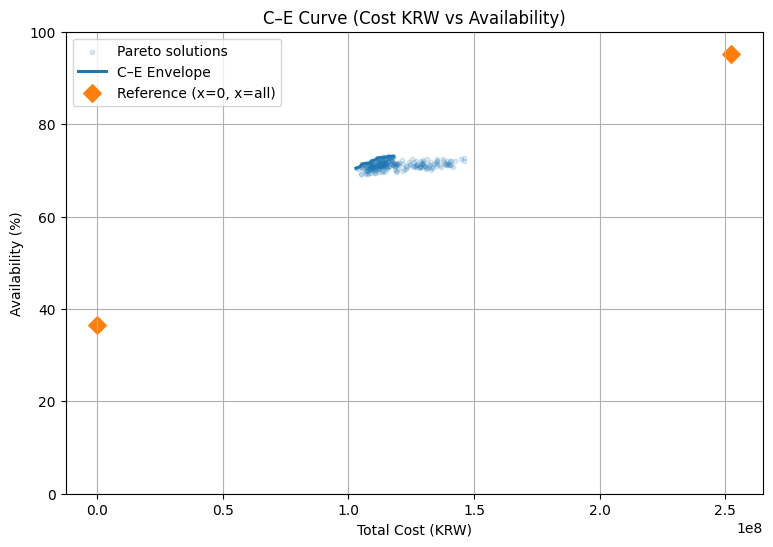

Reference A(x=0)% : 36.48 | Cost: 0
Reference A(x=all)%: 95.07 | Cost: 252,488,644
Envelope Avail min/max: 70.46 ~ 73.03

✅ Saturation spares exported:
 - selected parts: 0
 - total cost (KRW): 0
Files: /content/saturation_spares.csv /content/saturation_spares.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

,Part_Key,Unit_Price_KRW,Total_Cost_KRW


In [47]:
# ============================================================
# 4-objective NSGA-II + C-E Curve (Cost KRW vs Availability %)
#  - Objectives for NSGA: Risk(0-1), Supply(0-1), Maint(0-1), Cost_norm(0-1)
#  - C-E for analysis: x = Total Cost (KRW), y = Availability (%)
#  - Export saturation spares list (CSV/XLSX)
# ============================================================

!pip -q install pymoo openpyxl

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.core.problem import Problem
from pymoo.optimize import minimize
from pymoo.termination import get_termination

# ----------------------------
# 0) Load CSV
# ----------------------------
CSV_PATH = "radar_1000_parts_bom.csv"  # <- 파일명수정
df = pd.read_csv(CSV_PATH)
df.columns = [str(c).strip() for c in df.columns]
N = len(df)
HOURS_PER_YEAR = 8760.0
print("Loaded:", CSV_PATH, "N=", N)

# ----------------------------
# 1) Helpers
# ----------------------------
def find_col(df_cols, candidates):
    cols = list(df_cols)
    norm = {str(c).strip().lower(): c for c in cols}
    for cand in candidates:
        k = str(cand).strip().lower()
        if k in norm:
            return norm[k]
    for cand in candidates:
        ck = str(cand).strip().lower().replace("_","")
        for c in cols:
            nk = str(c).strip().lower().replace("_","")
            if ck and (ck in nk or nk in ck):
                return c
    return None

def to_num(s, fill="median"):
    x = pd.to_numeric(s, errors="coerce")
    if fill == "median":
        med = x.median()
        if not np.isfinite(med): med = 0.0
        x = x.fillna(med)
    elif fill == "zero":
        x = x.fillna(0.0)
    return x.astype(float).to_numpy()

def label_to_score(s):
    raw = s.astype(str).str.strip().str.lower()
    m = {"required":1.0,"high":1.0,"h":1.0,
         "medium":0.5,"m":0.5,
         "optional":0.5,
         "low":0.0,"l":0.0}
    out = raw.map(lambda z: m.get(z, np.nan)).astype(float)
    med = out.median()
    if not np.isfinite(med): med = 0.5
    return out.fillna(med).to_numpy()

def rank_norm(x):
    x = np.asarray(x, float)
    order = np.argsort(x)
    r = np.empty_like(order, dtype=float)
    r[order] = np.linspace(0, 1, len(x))
    return r

def robust_norm(x):
    x = np.asarray(x, float)
    med = np.nanmedian(x)
    iqr = np.nanpercentile(x, 75) - np.nanpercentile(x, 25)
    if not np.isfinite(iqr) or iqr == 0:
        return np.zeros_like(x)
    z = (x - med) / iqr
    return 1/(1+np.exp(-z))

def masked_mean_penalty(x, v, alpha=0.20):
    x = np.asarray(x, float)
    v = np.asarray(v, float)
    sel = x > 0.5
    if sel.sum() == 0:
        return 1.0
    base = float(np.mean(v[sel]))
    ratio = float(sel.mean())
    if ratio < alpha:
        base = base + (alpha - ratio) * 0.5
    return base

def estimate_minmax(func, samples=4000, seed=7):
    rng = np.random.default_rng(seed)
    vals = []
    for _ in range(samples):
        x = rng.integers(0, 2, size=N)
        vals.append(func(x))
    return float(np.min(vals)), float(np.max(vals))

def norm01(v, vmin, vmax):
    return (v - vmin) / ((vmax - vmin) + 1e-12)

def envelope(cost, eff):
    order = np.argsort(cost)
    cost = cost[order]; eff = eff[order]
    envC, envE = [], []
    best = -1e18
    for c, e in zip(cost, eff):
        if e > best + 1e-9:
            envC.append(c); envE.append(e); best = e
    return np.array(envC), np.array(envE)

# ----------------------------
# 2) Column mapping (auto)
#    - 너 데이터 기준으로 최대한 자동 찾기
# ----------------------------
FAIL_COL  = find_col(df.columns, ["Failure_Rate"])
CM_COL    = find_col(df.columns, ["CM_Time_Hours", "Maintenance_Time"])
LEAD_COL  = find_col(df.columns, ["Total_Lead_Time_H", "Procurement_Lead_Time"])
TRANS_COL = find_col(df.columns, ["Transport_Time_H"])
OBS_COL   = find_col(df.columns, ["Obs_Risk_Label", "Obs_Risk_Lable"])
LEVEL_COL = find_col(df.columns, ["Level", "BOM_Level"])
PARENT_COL= find_col(df.columns, ["Parent_ID"])
BEAM_COL  = find_col(df.columns, ["Annual_Rad_Hours","Beam_Radiation_Time"])
ENV_COL   = find_col(df.columns, ["Env_Resistance","Environmental_Impact"])
COST_COL  = find_col(df.columns, ["Unit_Price_KRW","unit_price_krw","UnitPriceKRW"])

print("\n=== Column mapping ===")
print("Failure:", FAIL_COL)
print("CM     :", CM_COL)
print("Lead   :", LEAD_COL)
print("Trans  :", TRANS_COL)
print("Obs    :", OBS_COL)
print("Level  :", LEVEL_COL)
print("Parent :", PARENT_COL)
print("Beam   :", BEAM_COL)
print("Env    :", ENV_COL)
print("Cost   :", COST_COL)

assert FAIL_COL and CM_COL and COST_COL, "필수 컬럼(Failure_Rate, CM_Time_Hours, Unit_Price_KRW)을 못 찾았습니다."

fail_yr = to_num(df[FAIL_COL], fill="median")   # failures/year (MIL-HDBK-217 논리: 연간고장율로 간주)
cm_hr   = to_num(df[CM_COL], fill="median")     # hours
price_vec = to_num(df[COST_COL], fill="median") # KRW

lead_hr  = to_num(df[LEAD_COL], fill="median") if LEAD_COL else np.zeros(N)
trans_hr = to_num(df[TRANS_COL], fill="median") if TRANS_COL else np.zeros(N)
wait_hr  = lead_hr + trans_hr

# risk weight (0.5~1.5)
if OBS_COL:
    obs = label_to_score(df[OBS_COL])
else:
    # 없으면 wait 기반 proxy
    mn, mx = float(np.min(wait_hr)), float(np.max(wait_hr))
    obs = np.zeros(N) if mx == mn else (wait_hr - mn)/(mx - mn)
obs = np.clip(obs, 0, 1)
risk_weight = 0.5 + obs

# bom depth
if LEVEL_COL:
    lvl = df[LEVEL_COL].astype(str).str.strip().str.replace("L","", regex=False)
    lvl_num = pd.to_numeric(lvl, errors="coerce")
    med = lvl_num.median()
    if not np.isfinite(med): med = 1.0
    lvl_num = lvl_num.fillna(med).astype(float)
else:
    lvl_num = pd.Series(np.ones(N))

# bom children proxy from Parent_ID
if PARENT_COL:
    parent = df[PARENT_COL].astype(str)
    child_cnt = parent.value_counts()
    child_raw = parent.map(child_cnt).astype(float).fillna(0.0)
else:
    child_raw = pd.Series(np.zeros(N))

# beam/env (없으면 0 벡터로)
beam_raw = to_num(df[BEAM_COL], fill="median") if BEAM_COL else np.zeros(N)
env_raw  = to_num(df[ENV_COL], fill="median")  if ENV_COL else np.zeros(N)

# ----------------------------
# 3) Build normalized feature table for objectives
#    - Risk/Supply/Maint 모두 0~1에서 변별력 크게
# ----------------------------
df_norm = pd.DataFrame(index=df.index)

# Risk components
df_norm["reliability"] = rank_norm(fail_yr)                # fail_yr 높을수록 나쁨
df_norm["beam_time"]   = robust_norm(beam_raw)             # 높을수록 나쁨(가정)
df_norm["env_impact"]  = 1.0 - robust_norm(env_raw)        # Env_Resistance가 높을수록 좋다면 뒤집기

# Supply components (obs는 이미 0~1)
df_norm["supply_stability"] = obs                          # 1=리스크 큼(불안정)으로 해석
df_norm["lead_time"]        = robust_norm(lead_hr)
df_norm["supplier_count"]   = robust_norm(trans_hr)

# Maintenance components (rank로 강제 분산)
df_norm["maintenance_time_r"] = rank_norm(cm_hr)
df_norm["bom_children_r"]     = rank_norm(child_raw.to_numpy(float))
df_norm["bom_depth_r"]        = rank_norm(lvl_num.to_numpy(float))

# ----------------------------
# 4) Define 3 objectives (Risk/Supply/Maint) + normalize each to 0~1
# ----------------------------
ALPHA = 0.20
PWR = 2
BETA_M = 0.60

def risk_obj(x):
    v = (0.5*df_norm["reliability"].values
         + 0.2*df_norm["beam_time"].values
         + 0.3*df_norm["env_impact"].values)
    base = masked_mean_penalty(x, v, ALPHA)
    return base**PWR

def supply_obj(x):
    v = (0.5*df_norm["supply_stability"].values
         + 0.3*df_norm["lead_time"].values
         + 0.2*df_norm["supplier_count"].values)
    base = masked_mean_penalty(x, v, ALPHA)
    return base**PWR

def maint_obj(x):
    x = np.asarray(x, float)
    sel = x > 0.5
    if sel.sum() == 0:
        return 1.0
    v = (0.6*df_norm["maintenance_time_r"].values +
         0.2*df_norm["bom_children_r"].values +
         0.2*df_norm["bom_depth_r"].values)
    mean_v = float(np.mean(v[sel]))
    sel_ratio = float(sel.mean())
    base = mean_v + BETA_M*(1.0 - sel_ratio)
    if sel_ratio < ALPHA:
        base += (ALPHA - sel_ratio) * 0.5
    return base**PWR

# normalize 0~1
rmin, rmax = estimate_minmax(risk_obj)
smin, smax = estimate_minmax(supply_obj)
mmin, mmax = estimate_minmax(maint_obj)

def risk_obj_n(x):   return norm01(risk_obj(x),   rmin, rmax)
def supply_obj_n(x): return norm01(supply_obj(x), smin, smax)
def maint_obj_n(x):  return norm01(maint_obj(x),  mmin, mmax)

# ----------------------------
# 5) Cost for NSGA (norm) + Cost for C-E (KRW)
# ----------------------------
def cost_krw(x):
    x = np.asarray(x, float)
    return float(np.sum(x * price_vec))

cmin, cmax = estimate_minmax(cost_krw)
def cost_norm(x):
    return float(np.clip(norm01(cost_krw(x), cmin, cmax), 0.0, 1.0))


print("\n=== Scale Summary (normalized 0~1) ===")
# quick random scale check
rng = np.random.default_rng(0)
R,S,M,C = [],[],[],[]
for _ in range(2000):
    x = rng.integers(0,2,size=N)
    R.append(risk_obj_n(x)); S.append(supply_obj_n(x)); M.append(maint_obj_n(x)); C.append(cost_norm(x))
print(f"Risk        : min={np.min(R):.4f}, max={np.max(R):.4f}")
print(f"Supply      : min={np.min(S):.4f}, max={np.max(S):.4f}")
print(f"Maintenance : min={np.min(M):.4f}, max={np.max(M):.4f}")
print(f"Cost_norm   : min={np.min(C):.4f}, max={np.max(C):.4f}")

# ----------------------------
# Availability proxy v2: Explicit stockout downtime
# ----------------------------
KAPPA_MAINT = 0.0012    # 정비/수리 반영 스케일(기존 KAPPA)
KAPPA_SO    = 0.0120    # 🔥 stockout 반영 스케일(초반을 낮추는 핵심)
KAPPA_Q     = 0.0010    # queueing 반영 스케일(원하면 따로)

ADMIN_H_PER_FAIL = 24.0
FIXED_DOWNTIME_H_PER_YEAR = 400.0

ETA_WAIT   = 0.75
ETA_CM     = 0.20
MTTR_MIN_H = 24.0
GAMMA      = 0.0

USE_QUEUEING = True
MU_EVENTS_PER_YEAR = 70.0
Q_HOURS_PER_EVENT  = 24.0
ETA_LAMBDA_REDUCTION = 0.75

# 조달 리드타임(시간): lead+transport를 쓰는 게 제일 설득력 있음
LT_hr = wait_hr.copy()  # lead+transport

def availability_proxy(x):
    x = np.asarray(x, float)

    # ---- maint-like downtime
    mttr_eff = (
        MTTR_MIN_H
        + cm_hr   * (1.0 - ETA_CM   * x)
        + wait_hr * (1.0 - ETA_WAIT * x)
        + GAMMA * wait_hr * risk_weight * (1.0 - x)
        + ADMIN_H_PER_FAIL
    )

    # ---- downtime-causing event rate
    lam_eff = fail_yr * (1.0 - ETA_LAMBDA_REDUCTION * x)
    lam_eff = np.clip(lam_eff, 0.0, None)

    D_maint = KAPPA_MAINT * float(np.sum(lam_eff * mttr_eff))

    # ---- ✅ stockout downtime: (not stocked) * failures * leadtime
    # x=0이면 해당 부품 고장 시 조달대기로 다운이 길어짐
    D_stockout = KAPPA_SO * float(np.sum((1.0 - x) * fail_yr * LT_hr))

    # ---- queueing
    D_queue = 0.0
    if USE_QUEUEING:
        LAMBDA = float(np.sum(lam_eff))
        rho = min(0.95, LAMBDA / max(1e-9, MU_EVENTS_PER_YEAR))
        Wq = Q_HOURS_PER_EVENT * (rho / max(1e-9, (1.0 - rho)))
        D_queue = KAPPA_Q * LAMBDA * Wq

    # ---- total
    D_yr = FIXED_DOWNTIME_H_PER_YEAR + D_maint + D_stockout + D_queue
    A = 1.0 - D_yr / HOURS_PER_YEAR
    return float(np.clip(A, 0.0, 1.0))

print("A(x=0)%  :", round(availability_proxy(np.zeros(N))*100, 2))
print("A(x=all)%:", round(availability_proxy(np.ones(N))*100, 2))


# ----------------------------
# 7) NSGA-II 4-objective (Cost_norm 포함)
# ----------------------------
class SpareNSGA4(Problem):
    def __init__(self):
        super().__init__(n_var=N, n_obj=4, xl=0, xu=1, type_var=int)

    def _evaluate(self, X, out, *args, **kwargs):
        F = np.zeros((len(X), 4))
        for i, x in enumerate(X):
            F[i,0] = risk_obj_n(x)
            F[i,1] = supply_obj_n(x)
            F[i,2] = maint_obj_n(x)
            F[i,3] = cost_norm(x)   # 최적화는 정규화 cost
        out["F"] = F

algorithm = NSGA2(pop_size=260)
termination = get_termination("n_gen", 10)

res = minimize(SpareNSGA4(), algorithm, termination, seed=42, verbose=True)
X_pf = res.X
print("\n✅ Pareto count:", len(X_pf))

# --- C-E curve plot (NO saturation) ---
plt.figure(figsize=(9,6))
plt.scatter(Cost_KRW, Avail, s=10, alpha=0.15, label="Pareto solutions")
plt.plot(envC, envA, linewidth=2.2, label="C–E Envelope")

# optional: show A(x=0), A(x=all) reference points
c0 = cost_krw(np.zeros(N))
a0 = availability_proxy(np.zeros(N))*100
c1 = cost_krw(np.ones(N))
a1 = availability_proxy(np.ones(N))*100
plt.scatter([c0, c1], [a0, a1], s=80, marker="D", label="Reference (x=0, x=all)")

plt.xlabel("Total Cost (KRW)")
plt.ylabel("Availability (%)")
plt.title("C–E Curve (Cost KRW vs Availability)")
plt.grid(True)

# ✅ y-axis fixed
plt.ylim(0, 100)

plt.legend()
plt.show()

print("Reference A(x=0)% :", round(a0,2), "| Cost:", f"{c0:,.0f}")
print("Reference A(x=all)%:", round(a1,2), "| Cost:", f"{c1:,.0f}")
print("Envelope Avail min/max:", round(envA.min(),2), "~", round(envA.max(),2))


# ----------------------------
# 9) Extract saturation solution -> spares list export
#    - choose actual solution closest to saturation point on envelope
# ----------------------------
# find closest in (cost,avail) space among Pareto sols
dist = (Cost_KRW - sat_cost)**2 + (Avail - sat_av)**2
best_idx = int(np.argmin(dist))
x_sat = X_pf[best_idx].astype(int)

sel_idx = np.where(x_sat == 1)[0]
spares = df.iloc[sel_idx].copy()
spares["Unit_Price_KRW"] = price_vec[sel_idx]
spares["Total_Cost_KRW"] = spares["Unit_Price_KRW"]

key_col = find_col(df.columns, ["Part_ID","Part_Number","Item_ID","SKU","Name"])
spares["Part_Key"] = spares[key_col].astype(str) if key_col else spares.index.astype(str)

summary = (spares.groupby("Part_Key", as_index=False)
           .agg(Unit_Price_KRW=("Unit_Price_KRW","mean"),
                Total_Cost_KRW=("Total_Cost_KRW","sum"))
           .sort_values("Total_Cost_KRW", ascending=False))

csv_out  = "/content/saturation_spares.csv"
xlsx_out = "/content/saturation_spares.xlsx"
summary.to_csv(csv_out, index=False, encoding="utf-8-sig")
with pd.ExcelWriter(xlsx_out, engine="openpyxl") as w:
    summary.to_excel(w, index=False, sheet_name="Spares")

print("\n✅ Saturation spares exported:")
print(" - selected parts:", int(x_sat.sum()))
print(" - total cost (KRW):", f"{summary['Total_Cost_KRW'].sum():,.0f}")
print("Files:", csv_out, xlsx_out)

# (Colab) download links
from google.colab import files
files.download(csv_out)
files.download(xlsx_out)

display(summary.head(30))


In [48]:
print("A(x=0)%  :", round(availability_proxy(np.zeros(N))*100, 2))
print("A(x=all)%:", round(availability_proxy(np.ones(N))*100, 2))


A(x=0)%  : 36.48
A(x=all)%: 95.07


n_gen  |  n_eval  | n_nds  |     cv_min    |     cv_avg    |      eps      |   indicator  
     1 |      260 |     57 |  0.000000E+00 |  0.000000E+00 |             - |             -
     2 |      520 |     60 |  0.000000E+00 |  0.000000E+00 |  0.0919455200 |         ideal
     3 |      780 |     96 |  0.000000E+00 |  0.000000E+00 |  0.1793500467 |         ideal
     4 |     1040 |    131 |  0.000000E+00 |  0.000000E+00 |  0.0298635237 |         ideal
     5 |     1300 |    176 |  0.000000E+00 |  0.000000E+00 |  0.0353274560 |         ideal
     6 |     1560 |    229 |  0.000000E+00 |  0.000000E+00 |  0.0359932156 |         ideal
     7 |     1820 |    257 |  0.000000E+00 |  0.000000E+00 |  0.0532062970 |         ideal
     8 |     2080 |    260 |  0.000000E+00 |  0.000000E+00 |  0.0581631857 |         ideal
     9 |     2340 |    260 |  0.000000E+00 |  0.000000E+00 |  0.0309194586 |         ideal
    10 |     2600 |    260 |  0.000000E+00 |  0.000000E+00 |  0.0437900891 |         ideal

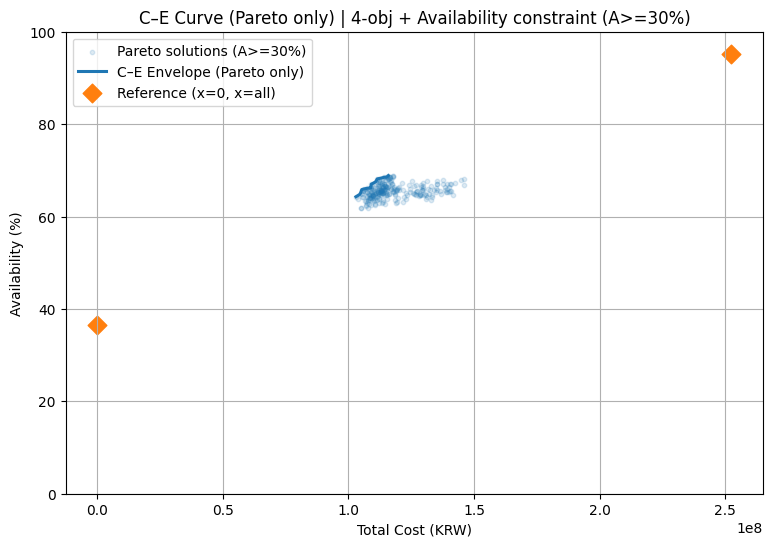


Reference A(x=0)% : 36.48 | Cost: 0
Reference A(x=all)%: 95.07 | Cost: 252,488,644
Pareto Avail min/max: 61.9 ~ 68.85
Envelope Avail min/max: 64.28 ~ 68.85


In [49]:
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.core.problem import Problem
from pymoo.optimize import minimize
from pymoo.termination import get_termination
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# A_min 설정 (30%)
# ------------------------------------------------------------
A_MIN = 0.30  # 30%

# ------------------------------------------------------------
# (안전) cost_norm은 0~1로 클램프 권장
# ------------------------------------------------------------
def cost_norm_clamped(x):
    return float(np.clip(cost_norm(x), 0.0, 1.0))

# ------------------------------------------------------------
# 4-objective + Availability constraint
# objectives: Risk, Supply, Maintenance, Cost_norm
# constraint: A_MIN - Availability(x) <= 0  (즉 Availability >= A_MIN)
# ------------------------------------------------------------
class SpareNSGA4_Constrained(Problem):
    def __init__(self):
        super().__init__(n_var=N, n_obj=4, n_constr=1, xl=0, xu=1, type_var=int)

    def _evaluate(self, X, out, *args, **kwargs):
        F = np.zeros((len(X), 4))
        G = np.zeros((len(X), 1))

        for i, x in enumerate(X):
            # 4 objectives (minimize)
            F[i,0] = risk_obj_n(x)
            F[i,1] = supply_obj_n(x)
            F[i,2] = maint_obj_n(x)
            F[i,3] = cost_norm_clamped(x)

            # availability constraint
            A = availability_proxy(x)  # 0~1
            G[i,0] = A_MIN - A         # <=0이면 만족

        out["F"] = F
        out["G"] = G

# ------------------------------------------------------------
# Run NSGA-II
# ------------------------------------------------------------
algorithm = NSGA2(pop_size=260)
termination = get_termination("n_gen", 10)

res = minimize(SpareNSGA4_Constrained(),
               algorithm,
               termination,
               seed=42,
               verbose=True)

X_pf = res.X   # Pareto solutions (feasible 중심)
print("\n✅ Pareto count:", len(X_pf))

# ------------------------------------------------------------
# C–E (Pareto only)  | x=Total Cost(KRW), y=Availability(%)
# ------------------------------------------------------------
Cost_KRW = np.array([cost_krw(x) for x in X_pf], float)
Avail = np.array([availability_proxy(x) for x in X_pf], float) * 100.0

# envelope: 비용 증가에 따라 얻을 수 있는 최대 가용도
order = np.argsort(Cost_KRW)
c_sorted = Cost_KRW[order]
a_sorted = Avail[order]

envC, envA = [], []
best = -1e18
for c, a in zip(c_sorted, a_sorted):
    if a > best + 1e-9:
        envC.append(c); envA.append(a); best = a
envC = np.array(envC); envA = np.array(envA)

# reference points (x=0, x=all)
c0 = cost_krw(np.zeros(N))
a0 = availability_proxy(np.zeros(N))*100
c1 = cost_krw(np.ones(N))
a1 = availability_proxy(np.ones(N))*100

plt.figure(figsize=(9,6))
plt.scatter(Cost_KRW, Avail, s=10, alpha=0.15, label="Pareto solutions (A>=30%)")
plt.plot(envC, envA, linewidth=2.2, label="C–E Envelope (Pareto only)")
plt.scatter([c0, c1], [a0, a1], s=90, marker="D", label="Reference (x=0, x=all)")

plt.ylim(0, 100)  # ✅ y축 0~100 고정
plt.xlabel("Total Cost (KRW)")
plt.ylabel("Availability (%)")
plt.title("C–E Curve (Pareto only) | 4-obj + Availability constraint (A>=30%)")
plt.grid(True)
plt.legend()
plt.show()

print("\nReference A(x=0)% :", round(a0,2), "| Cost:", f"{c0:,.0f}")
print("Reference A(x=all)%:", round(a1,2), "| Cost:", f"{c1:,.0f}")
print("Pareto Avail min/max:", round(Avail.min(),2), "~", round(Avail.max(),2))
print("Envelope Avail min/max:", round(envA.min(),2), "~", round(envA.max(),2))


n_gen  |  n_eval  | n_nds  |     cv_min    |     cv_avg    |      eps      |   indicator  
     1 |      260 |     57 |  0.000000E+00 |  0.000000E+00 |             - |             -
     2 |      520 |     60 |  0.000000E+00 |  0.000000E+00 |  0.0919455200 |         ideal
     3 |      780 |     96 |  0.000000E+00 |  0.000000E+00 |  0.1793500467 |         ideal
     4 |     1040 |    131 |  0.000000E+00 |  0.000000E+00 |  0.0298635237 |         ideal
     5 |     1300 |    176 |  0.000000E+00 |  0.000000E+00 |  0.0353274560 |         ideal
     6 |     1560 |    229 |  0.000000E+00 |  0.000000E+00 |  0.0359932156 |         ideal
     7 |     1820 |    257 |  0.000000E+00 |  0.000000E+00 |  0.0532062970 |         ideal
     8 |     2080 |    260 |  0.000000E+00 |  0.000000E+00 |  0.0581631857 |         ideal
     9 |     2340 |    260 |  0.000000E+00 |  0.000000E+00 |  0.0309194586 |         ideal
    10 |     2600 |    260 |  0.000000E+00 |  0.000000E+00 |  0.0437900891 |         ideal

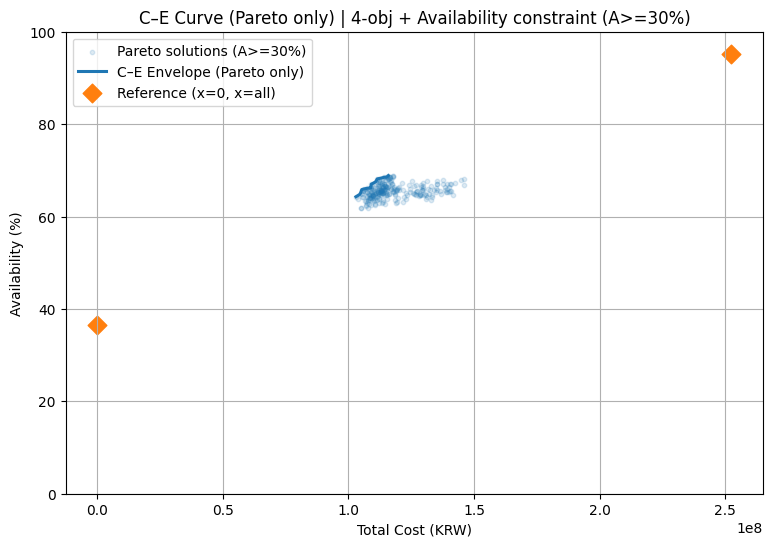


Reference A(x=0)% : 36.48 | Cost: 0
Reference A(x=all)%: 95.07 | Cost: 252,488,644
Pareto Avail min/max: 61.9 ~ 68.85
Envelope Avail min/max: 64.28 ~ 68.85


In [50]:
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.core.problem import Problem
from pymoo.optimize import minimize
from pymoo.termination import get_termination
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# A_min 설정 (30%)
# ------------------------------------------------------------
A_MIN = 0.30  # 30%

# ------------------------------------------------------------
# (안전) cost_norm은 0~1로 클램프 권장
# ------------------------------------------------------------
def cost_norm_clamped(x):
    return float(np.clip(cost_norm(x), 0.0, 1.0))

# ------------------------------------------------------------
# 4-objective + Availability constraint
# objectives: Risk, Supply, Maintenance, Cost_norm
# constraint: A_MIN - Availability(x) <= 0  (즉 Availability >= A_MIN)
# ------------------------------------------------------------
class SpareNSGA4_Constrained(Problem):
    def __init__(self):
        super().__init__(n_var=N, n_obj=4, n_constr=1, xl=0, xu=1, type_var=int)

    def _evaluate(self, X, out, *args, **kwargs):
        F = np.zeros((len(X), 4))
        G = np.zeros((len(X), 1))

        for i, x in enumerate(X):
            # 4 objectives (minimize)
            F[i,0] = risk_obj_n(x)
            F[i,1] = supply_obj_n(x)
            F[i,2] = maint_obj_n(x)
            F[i,3] = cost_norm_clamped(x)

            # availability constraint
            A = availability_proxy(x)  # 0~1
            G[i,0] = A_MIN - A         # <=0이면 만족

        out["F"] = F
        out["G"] = G

# ------------------------------------------------------------
# Run NSGA-II
# ------------------------------------------------------------
algorithm = NSGA2(pop_size=260)
termination = get_termination("n_gen", 10)

res = minimize(SpareNSGA4_Constrained(),
               algorithm,
               termination,
               seed=42,
               verbose=True)

X_pf = res.X   # Pareto solutions (feasible 중심)
print("\n✅ Pareto count:", len(X_pf))

# ------------------------------------------------------------
# C–E (Pareto only)  | x=Total Cost(KRW), y=Availability(%)
# ------------------------------------------------------------
Cost_KRW = np.array([cost_krw(x) for x in X_pf], float)
Avail = np.array([availability_proxy(x) for x in X_pf], float) * 100.0

# envelope: 비용 증가에 따라 얻을 수 있는 최대 가용도
order = np.argsort(Cost_KRW)
c_sorted = Cost_KRW[order]
a_sorted = Avail[order]

envC, envA = [], []
best = -1e18
for c, a in zip(c_sorted, a_sorted):
    if a > best + 1e-9:
        envC.append(c); envA.append(a); best = a
envC = np.array(envC); envA = np.array(envA)

# reference points (x=0, x=all)
c0 = cost_krw(np.zeros(N))
a0 = availability_proxy(np.zeros(N))*100
c1 = cost_krw(np.ones(N))
a1 = availability_proxy(np.ones(N))*100

plt.figure(figsize=(9,6))
plt.scatter(Cost_KRW, Avail, s=10, alpha=0.15, label="Pareto solutions (A>=30%)")
plt.plot(envC, envA, linewidth=2.2, label="C–E Envelope (Pareto only)")
plt.scatter([c0, c1], [a0, a1], s=90, marker="D", label="Reference (x=0, x=all)")

plt.ylim(0, 100)  # ✅ y축 0~100 고정
plt.xlabel("Total Cost (KRW)")
plt.ylabel("Availability (%)")
plt.title("C–E Curve (Pareto only) | 4-obj + Availability constraint (A>=30%)")
plt.grid(True)
plt.legend()
plt.show()

print("\nReference A(x=0)% :", round(a0,2), "| Cost:", f"{c0:,.0f}")
print("Reference A(x=all)%:", round(a1,2), "| Cost:", f"{c1:,.0f}")
print("Pareto Avail min/max:", round(Avail.min(),2), "~", round(Avail.max(),2))
print("Envelope Avail min/max:", round(envA.min(),2), "~", round(envA.max(),2))


n_gen  |  n_eval  | n_nds  |     cv_min    |     cv_avg    |      eps      |   indicator  
     1 |      260 |     57 |  0.000000E+00 |  0.000000E+00 |             - |             -
     2 |      520 |     60 |  0.000000E+00 |  0.000000E+00 |  0.0919455200 |         ideal
     3 |      780 |     96 |  0.000000E+00 |  0.000000E+00 |  0.1793500467 |         ideal
     4 |     1040 |    131 |  0.000000E+00 |  0.000000E+00 |  0.0298635237 |         ideal
     5 |     1300 |    176 |  0.000000E+00 |  0.000000E+00 |  0.0353274560 |         ideal
     6 |     1560 |    229 |  0.000000E+00 |  0.000000E+00 |  0.0359932156 |         ideal
     7 |     1820 |    257 |  0.000000E+00 |  0.000000E+00 |  0.0532062970 |         ideal
     8 |     2080 |    260 |  0.000000E+00 |  0.000000E+00 |  0.0581631857 |         ideal
     9 |     2340 |    260 |  0.000000E+00 |  0.000000E+00 |  0.0309194586 |         ideal
    10 |     2600 |    260 |  0.000000E+00 |  0.000000E+00 |  0.0437900891 |         ideal

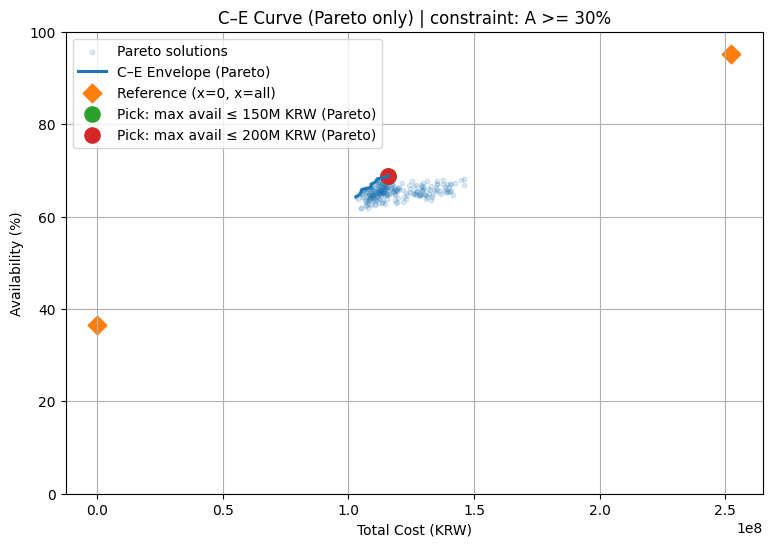


Reference A(x=0)%  : 36.48 | Cost: 0
Reference A(x=all)%: 95.07 | Cost: 252,488,644
Pareto Avail min/max: 61.9 ~ 68.85
Envelope Avail min/max: 64.28 ~ 68.85


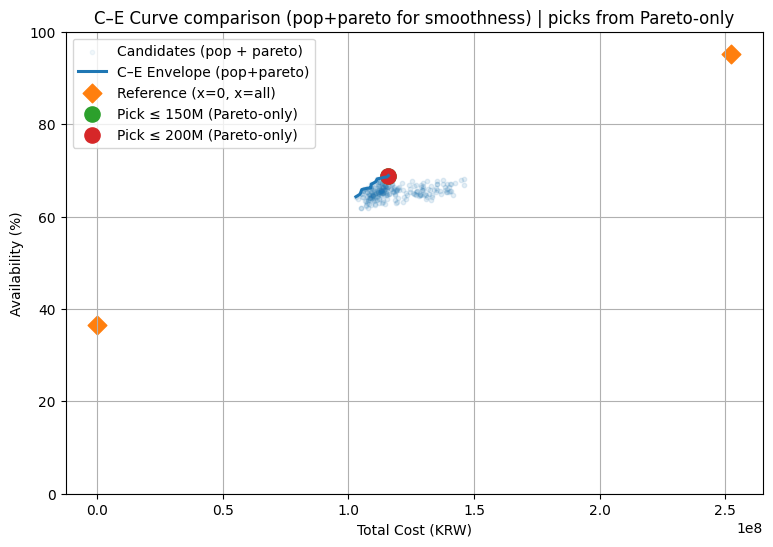

Candidates Avail min/max: 61.9 ~ 68.85
Envelope(pop+pareto) Avail min/max: 64.28 ~ 68.85


In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.core.problem import Problem
from pymoo.optimize import minimize
from pymoo.termination import get_termination


# ============================================================
# 0) Settings
# ============================================================
A_MIN = 0.30  # optimization constraint (30%)

# "목표 운용가용도" 구간 (원하면 바꿔)
TARGET_LOW  = 92.0
TARGET_HIGH = 93.0

# 예산 시나리오 (원하면 바꿔)
# 예: 5천만원, 1억원, 1.5억원, 2억원
BUDGETS_KRW = [50_000_000, 100_000_000, 150_000_000, 200_000_000]

# pop+pareto 비교 플롯을 그릴지 여부
PLOT_POP_PLUS_PARETO = True


# ============================================================
# 1) Constrained NSGA-II (4 objectives + Availability constraint)
# ============================================================
def cost_norm_clamped(x):
    return float(np.clip(cost_norm(x), 0.0, 1.0))

class SpareNSGA4_Constrained(Problem):
    def __init__(self):
        super().__init__(n_var=N, n_obj=4, n_constr=1, xl=0, xu=1, type_var=int)

    def _evaluate(self, X, out, *args, **kwargs):
        F = np.zeros((len(X), 4))
        G = np.zeros((len(X), 1))

        for i, x in enumerate(X):
            # Objectives (minimize)
            F[i,0] = risk_obj_n(x)
            F[i,1] = supply_obj_n(x)
            F[i,2] = maint_obj_n(x)
            F[i,3] = cost_norm_clamped(x)

            # Constraint: A >= A_MIN  ->  A_MIN - A <= 0
            A = availability_proxy(x)  # 0~1
            G[i,0] = A_MIN - A

        out["F"] = F
        out["G"] = G

algorithm = NSGA2(pop_size=260)
termination = get_termination("n_gen", 10)

res = minimize(
    SpareNSGA4_Constrained(),
    algorithm,
    termination,
    seed=42,
    verbose=True
)

# Pareto (feasible 중심)
X_pf = res.X
print("\n✅ Pareto count:", len(X_pf))


# ============================================================
# 2) Build C–E data for Pareto only
# ============================================================
Cost_pf = np.array([cost_krw(x) for x in X_pf], float)
Avail_pf = np.array([availability_proxy(x) for x in X_pf], float) * 100.0

# envelope helper
def envelope(cost, eff):
    order = np.argsort(cost)
    cost = cost[order]; eff = eff[order]
    envC, envE, best = [], [], -1e18
    for c,e in zip(cost, eff):
        if e > best + 1e-9:
            envC.append(c); envE.append(e); best = e
    return np.array(envC), np.array(envE)

envC_pf, envA_pf = envelope(Cost_pf, Avail_pf)

# reference points
c0 = cost_krw(np.zeros(N))
a0 = availability_proxy(np.zeros(N))*100
c1 = cost_krw(np.ones(N))
a1 = availability_proxy(np.ones(N))*100


# ============================================================
# (1) Pareto-only selection logic
#     A) "target band(92~93%) 내 최소비용"
#     B) "예산 B 이하에서 최대 가용도"
# ============================================================
def pick_min_cost_in_band(X, cost, avail, low, high):
    idx = np.where((avail >= low) & (avail <= high))[0]
    if len(idx) == 0:
        return None
    best_i = idx[np.argmin(cost[idx])]
    return int(best_i)

def pick_max_avail_under_budget(X, cost, avail, budget):
    idx = np.where(cost <= budget)[0]
    if len(idx) == 0:
        return None
    # tie-break: 같으면 더 싼 것
    best_a = np.max(avail[idx])
    cand = idx[np.where(avail[idx] == best_a)[0]]
    best_i = cand[np.argmin(cost[cand])]
    return int(best_i)

# A) Target band pick (Pareto-only)
idx_band = pick_min_cost_in_band(X_pf, Cost_pf, Avail_pf, TARGET_LOW, TARGET_HIGH)

# B) Budget picks (Pareto-only)
idx_budget = {B: pick_max_avail_under_budget(X_pf, Cost_pf, Avail_pf, B) for B in BUDGETS_KRW}

# summarize picks
rows = []
if idx_band is not None:
    rows.append({
        "Type": f"MinCost in {TARGET_LOW:.0f}-{TARGET_HIGH:.0f}%",
        "Budget_KRW": None,
        "Cost_KRW": Cost_pf[idx_band],
        "Avail_%": Avail_pf[idx_band],
        "Selected_Count": int(np.sum(X_pf[idx_band]))
    })
for B, idx in idx_budget.items():
    if idx is None:
        rows.append({
            "Type": "MaxAvail under budget",
            "Budget_KRW": B,
            "Cost_KRW": None,
            "Avail_%": None,
            "Selected_Count": None
        })
    else:
        rows.append({
            "Type": "MaxAvail under budget",
            "Budget_KRW": B,
            "Cost_KRW": Cost_pf[idx],
            "Avail_%": Avail_pf[idx],
            "Selected_Count": int(np.sum(X_pf[idx]))
        })

df_pick = pd.DataFrame(rows)
print("\n=== Pareto-only picks ===")
print(df_pick)


# ============================================================
# 3) Plot: Pareto-only C–E (NO saturation) + marks of picked points
# ============================================================
plt.figure(figsize=(9,6))
plt.scatter(Cost_pf, Avail_pf, s=10, alpha=0.15, label="Pareto solutions")
plt.plot(envC_pf, envA_pf, linewidth=2.2, label="C–E Envelope (Pareto)")

# reference
plt.scatter([c0, c1], [a0, a1], s=90, marker="D", label="Reference (x=0, x=all)")

# picked points
if idx_band is not None:
    plt.scatter([Cost_pf[idx_band]], [Avail_pf[idx_band]], s=160, marker="X",
                label=f"Pick: min cost in {TARGET_LOW:.0f}-{TARGET_HIGH:.0f}% (Pareto)")
for B, idx in idx_budget.items():
    if idx is not None:
        plt.scatter([Cost_pf[idx]], [Avail_pf[idx]], s=120, marker="o",
                    label=f"Pick: max avail ≤ {B/1e6:.0f}M KRW (Pareto)")

plt.ylim(0, 100)  # ✅ 0~100 고정
plt.xlabel("Total Cost (KRW)")
plt.ylabel("Availability (%)")
plt.title(f"C–E Curve (Pareto only) | constraint: A >= {A_MIN*100:.0f}%")
plt.grid(True)
plt.legend(loc="best")
plt.show()

print("\nReference A(x=0)%  :", round(a0,2), "| Cost:", f"{c0:,.0f}")
print("Reference A(x=all)%:", round(a1,2), "| Cost:", f"{c1:,.0f}")
print("Pareto Avail min/max:", round(Avail_pf.min(),2), "~", round(Avail_pf.max(),2))
print("Envelope Avail min/max:", round(envA_pf.min(),2), "~", round(envA_pf.max(),2))


# ============================================================
# 4) Plot: pop + pareto comparison (for curve smoothness only)
#     - NOTE: Picks are STILL from Pareto-only.
# ============================================================
if PLOT_POP_PLUS_PARETO:
    X_pop = res.pop.get("X")          # last generation population
    X_ce = np.vstack([X_pop, X_pf])   # candidates for curve only

    Cost_ce = np.array([cost_krw(x) for x in X_ce], float)
    Avail_ce = np.array([availability_proxy(x) for x in X_ce], float) * 100.0
    envC_ce, envA_ce = envelope(Cost_ce, Avail_ce)

    plt.figure(figsize=(9,6))
    plt.scatter(Cost_ce, Avail_ce, s=10, alpha=0.06, label="Candidates (pop + pareto)")
    plt.plot(envC_ce, envA_ce, linewidth=2.2, label="C–E Envelope (pop+pareto)")

    # reference + pareto picks (same picks)
    plt.scatter([c0, c1], [a0, a1], s=90, marker="D", label="Reference (x=0, x=all)")
    if idx_band is not None:
        plt.scatter([Cost_pf[idx_band]], [Avail_pf[idx_band]], s=160, marker="X",
                    label="Pick (Pareto-only)")
    for B, idx in idx_budget.items():
        if idx is not None:
            plt.scatter([Cost_pf[idx]], [Avail_pf[idx]], s=120, marker="o",
                        label=f"Pick ≤ {B/1e6:.0f}M (Pareto-only)")

    plt.ylim(0, 100)
    plt.xlabel("Total Cost (KRW)")
    plt.ylabel("Availability (%)")
    plt.title("C–E Curve comparison (pop+pareto for smoothness) | picks from Pareto-only")
    plt.grid(True)
    plt.legend(loc="best")
    plt.show()

    print("Candidates Avail min/max:", round(Avail_ce.min(),2), "~", round(Avail_ce.max(),2))
    print("Envelope(pop+pareto) Avail min/max:", round(envA_ce.min(),2), "~", round(envA_ce.max(),2))


In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.core.problem import Problem
from pymoo.optimize import minimize
from pymoo.termination import get_termination


# ============================================================
# 0) Settings
# ============================================================
A_MIN_LIST = [0.85, 0.92]   # ✅ 요청한 5개
POP = 260
NGEN = 10
SEED0 = 42

# 예산 marker도 찍고 싶으면 여기에 넣어두면 됨(테스트용)
BUDGETS_KRW = [100_000_000, 150_000_000, 200_000_000]


# ============================================================
# 1) Helpers
# ============================================================
def cost_norm_clamped(x):
    return float(np.clip(cost_norm(x), 0.0, 1.0))

def envelope(cost, eff):
    order = np.argsort(cost)
    cost = cost[order]; eff = eff[order]
    envC, envE, best = [], [], -1e18
    for c,e in zip(cost, eff):
        if e > best + 1e-9:
            envC.append(c); envE.append(e); best = e
    return np.array(envC), np.array(envE)

def pick_max_avail_under_budget(cost, avail, budget):
    idx = np.where(cost <= budget)[0]
    if len(idx) == 0:
        return None
    best_a = np.max(avail[idx])
    cand = idx[np.where(avail[idx] == best_a)[0]]
    best_i = cand[np.argmin(cost[cand])]
    return int(best_i)


# ============================================================
# 2) Constrained Problem Factory
# ============================================================
def make_problem(A_MIN):
    class SpareNSGA4_Constrained(Problem):
        def __init__(self):
            super().__init__(n_var=N, n_obj=4, n_constr=1, xl=0, xu=1, type_var=int)

        def _evaluate(self, X, out, *args, **kwargs):
            F = np.zeros((len(X), 4))
            G = np.zeros((len(X), 1))

            for i, x in enumerate(X):
                F[i,0] = risk_obj_n(x)
                F[i,1] = supply_obj_n(x)
                F[i,2] = maint_obj_n(x)
                F[i,3] = cost_norm_clamped(x)

                A = availability_proxy(x)     # 0~1
                G[i,0] = A_MIN - A            # <=0 feasible

            out["F"] = F
            out["G"] = G

    return SpareNSGA4_Constrained()


# ============================================================
# 3) Run NSGA for each A_min, collect Pareto ONLY
# ============================================================
all_rows = []
all_cost = []
all_avail = []
all_tag = []
all_X = []

for k, A_MIN in enumerate(A_MIN_LIST):
    print("\n" + "="*60)
    print(f"Running NSGA-II with constraint A >= {A_MIN*100:.0f}%")
    problem = make_problem(A_MIN)
    algorithm = NSGA2(pop_size=POP)
    termination = get_termination("n_gen", NGEN)

    res = minimize(problem, algorithm, termination, seed=SEED0 + k, verbose=True)

    X_pf = res.X
    if X_pf is None or len(X_pf) == 0:
        print("⚠️  No Pareto solutions returned.")
        all_rows.append({"A_min": A_MIN, "pareto_n": 0, "avail_min": None, "avail_max": None,
                         "cost_min": None, "cost_max": None})
        continue

    Cost = np.array([cost_krw(x) for x in X_pf], float)
    Av   = np.array([availability_proxy(x) for x in X_pf], float) * 100.0

    all_X.append(X_pf)
    all_cost.append(Cost)
    all_avail.append(Av)
    all_tag.append(np.array([A_MIN]*len(X_pf)))

    all_rows.append({
        "A_min": A_MIN,
        "pareto_n": len(X_pf),
        "avail_min": float(np.min(Av)),
        "avail_max": float(np.max(Av)),
        "cost_min": float(np.min(Cost)),
        "cost_max": float(np.max(Cost)),
    })

df_runs = pd.DataFrame(all_rows)
print("\n✅ Run summary (Pareto only):")
display(df_runs)


# ============================================================
# 4) Merge all Pareto solutions (from all A_min runs) -> CE plot
# ============================================================
if len(all_cost) == 0:
    raise RuntimeError("No Pareto solutions across all runs. Check constraints/availability function.")

Cost_all = np.concatenate(all_cost)
Avail_all = np.concatenate(all_avail)
Tag_all = np.concatenate(all_tag)

envC, envA = envelope(Cost_all, Avail_all)

# reference points
c0 = cost_krw(np.zeros(N))
a0 = availability_proxy(np.zeros(N))*100
c1 = cost_krw(np.ones(N))
a1 = availability_proxy(np.ones(N))*100

plt.figure(figsize=(10,6))

# scatter each A_min group with different marker alpha (색은 자동 순환)
for A_MIN in A_MIN_LIST:
    idx = np.where(Tag_all == A_MIN)[0]
    if len(idx) == 0:
        continue
    plt.scatter(Cost_all[idx], Avail_all[idx], s=12, alpha=0.18, label=f"Pareto (A≥{int(A_MIN*100)}%)")

plt.plot(envC, envA, linewidth=2.5, label="C–E Envelope (merged Pareto)")

# reference
plt.scatter([c0, c1], [a0, a1], s=100, marker="D", label="Reference (x=0, x=all)")

# budget picks on merged Pareto
for B in BUDGETS_KRW:
    idxB = pick_max_avail_under_budget(Cost_all, Avail_all, B)
    if idxB is not None:
        plt.scatter([Cost_all[idxB]], [Avail_all[idxB]], s=140, marker="X",
                    label=f"Pick: max A ≤ {B/1e6:.0f}M (merged Pareto)")

plt.ylim(0, 100)
plt.xlabel("Total Cost (KRW)")
plt.ylabel("Availability (%)")
plt.title("C–E Curve | Pareto-only stitched by A_min (no population, no saturation)")
plt.grid(True)
plt.legend(loc="best")
plt.show()

print("\nReference A(x=0)%  :", round(a0,2), "| Cost:", f"{c0:,.0f}")
print("Reference A(x=all)%:", round(a1,2), "| Cost:", f"{c1:,.0f}")
print("Merged Pareto Avail min/max:", round(float(np.min(Avail_all)),2), "~", round(float(np.max(Avail_all)),2))
print("Envelope Avail min/max:", round(float(np.min(envA)),2), "~", round(float(np.max(envA)),2))



Running NSGA-II with constraint A >= 85%
n_gen  |  n_eval  | n_nds  |     cv_min    |     cv_avg    |      eps      |   indicator  
     1 |      260 |      1 |  0.1634870528 |  0.1891283065 |             - |             -
     2 |      520 |      1 |  0.1530205435 |  0.1775599603 |             - |             -
     3 |      780 |      1 |  0.1530205435 |  0.1702821360 |             - |             -
     4 |     1040 |      1 |  0.1465884461 |  0.1639270159 |             - |             -
     5 |     1300 |      1 |  0.1433791137 |  0.1586327565 |             - |             -
     6 |     1560 |      1 |  0.1404278904 |  0.1531409081 |             - |             -
     7 |     1820 |      1 |  0.1332427518 |  0.1479440737 |             - |             -
     8 |     2080 |      1 |  0.1291612179 |  0.1433397118 |             - |             -
     9 |     2340 |      1 |  0.1218678060 |  0.1391738538 |             - |             -
    10 |     2600 |      1 |  0.1167537958 |  0.

,A_min,pareto_n,avail_min,avail_max,cost_min,cost_max
0,0.85,0,None,None,None,None
1,0.92,0,None,None,None,None


RuntimeError: No Pareto solutions across all runs. Check constraints/availability function.

In [53]:
# ============================================================
# NSGA-II (4 objectives) + Constraints:
#   - Availability >= 0.92
#   - Coverage over TOP fail-rate parts >= 0.60
#   - Coverage over TOP lead-time parts >= 0.60
# C-E Curve: Cost(KRW) vs Availability(%)
# Pareto-only, No saturation
# ============================================================

!pip -q install pymoo openpyxl

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.core.problem import Problem
from pymoo.optimize import minimize
from pymoo.termination import get_termination


# ------------------------------------------------------------
# 0) Load CSV
# ------------------------------------------------------------
CSV_PATH = "radar_1000_parts_bom.csv"  # <- 파일명 수정 가능
df = pd.read_csv(CSV_PATH)
df.columns = [str(c).strip() for c in df.columns]
N = len(df)
HOURS_PER_YEAR = 8760.0
print("Loaded:", CSV_PATH, "N=", N)


# ------------------------------------------------------------
# 1) Helper functions
# ------------------------------------------------------------
def find_col(df_cols, candidates):
    cols = list(df_cols)
    norm = {str(c).strip().lower(): c for c in cols}
    for cand in candidates:
        k = str(cand).strip().lower()
        if k in norm:
            return norm[k]
    for cand in candidates:
        ck = str(cand).strip().lower().replace("_","")
        for c in cols:
            nk = str(c).strip().lower().replace("_","")
            if ck and (ck in nk or nk in ck):
                return c
    return None

def to_num(s, fill="median"):
    x = pd.to_numeric(s, errors="coerce")
    if fill == "median":
        med = x.median()
        if not np.isfinite(med): med = 0.0
        x = x.fillna(med)
    elif fill == "zero":
        x = x.fillna(0.0)
    return x.astype(float).to_numpy()

def label_to_score(s):
    raw = s.astype(str).str.strip().str.lower()
    m = {"required":1.0,"high":1.0,"h":1.0,
         "medium":0.5,"m":0.5,
         "optional":0.5,
         "low":0.0,"l":0.0}
    out = raw.map(lambda z: m.get(z, np.nan)).astype(float)
    med = out.median()
    if not np.isfinite(med): med = 0.5
    return out.fillna(med).to_numpy()

def rank_norm(x):
    x = np.asarray(x, float)
    order = np.argsort(x)
    r = np.empty_like(order, dtype=float)
    r[order] = np.linspace(0, 1, len(x))
    return r

def robust_norm(x):
    x = np.asarray(x, float)
    med = np.nanmedian(x)
    iqr = np.nanpercentile(x, 75) - np.nanpercentile(x, 25)
    if not np.isfinite(iqr) or iqr == 0:
        return np.zeros_like(x)
    z = (x - med) / iqr
    return 1/(1+np.exp(-z))

def masked_mean_penalty(x, v, alpha=0.20):
    x = np.asarray(x, float)
    v = np.asarray(v, float)
    sel = x > 0.5
    if sel.sum() == 0:
        return 1.0
    base = float(np.mean(v[sel]))
    ratio = float(sel.mean())
    if ratio < alpha:
        base = base + (alpha - ratio) * 0.5
    return base

def estimate_minmax(func, samples=4000, seed=7):
    rng = np.random.default_rng(seed)
    vals = []
    for _ in range(samples):
        x = rng.integers(0, 2, size=N)
        vals.append(func(x))
    return float(np.min(vals)), float(np.max(vals))

def norm01(v, vmin, vmax):
    return (v - vmin) / ((vmax - vmin) + 1e-12)

def envelope(cost, eff):
    order = np.argsort(cost)
    cost = cost[order]; eff = eff[order]
    envC, envE, best = [], [], -1e18
    for c,e in zip(cost, eff):
        if e > best + 1e-9:
            envC.append(c); envE.append(e); best = e
    return np.array(envC), np.array(envE)

def pick_min_cost_in_band(cost, eff, low, high):
    idx = np.where((eff >= low) & (eff <= high))[0]
    if len(idx) == 0:
        return None
    return int(idx[np.argmin(cost[idx])])

def pick_max_eff_under_budget(cost, eff, budget):
    idx = np.where(cost <= budget)[0]
    if len(idx) == 0:
        return None
    best = np.max(eff[idx])
    cand = idx[np.where(eff[idx] == best)[0]]
    return int(cand[np.argmin(cost[cand])])


# ------------------------------------------------------------
# 2) Column mapping
# ------------------------------------------------------------
FAIL_COL  = find_col(df.columns, ["Failure_Rate"])
CM_COL    = find_col(df.columns, ["CM_Time_Hours", "Maintenance_Time"])
LEAD_COL  = find_col(df.columns, ["Total_Lead_Time_H", "Procurement_Lead_Time"])
TRANS_COL = find_col(df.columns, ["Transport_Time_H"])
OBS_COL   = find_col(df.columns, ["Obs_Risk_Label", "Obs_Risk_Lable"])
BEAM_COL  = find_col(df.columns, ["Annual_Rad_Hours","Beam_Radiation_Time"])
ENV_COL   = find_col(df.columns, ["Env_Resistance","Environmental_Impact"])
COST_COL  = find_col(df.columns, ["Unit_Price_KRW","unit_price_krw","UnitPriceKRW"])

print("\n=== Column mapping ===")
print("Failure:", FAIL_COL)
print("CM     :", CM_COL)
print("Lead   :", LEAD_COL)
print("Trans  :", TRANS_COL)
print("Obs    :", OBS_COL)
print("Beam   :", BEAM_COL)
print("Env    :", ENV_COL)
print("Cost   :", COST_COL)

assert FAIL_COL and CM_COL and COST_COL, "필수 컬럼(Failure_Rate, CM_Time_Hours, Unit_Price_KRW)을 못 찾았습니다."

fail_yr   = to_num(df[FAIL_COL], fill="median")        # failures/year
cm_hr     = to_num(df[CM_COL], fill="median")          # hours
price_vec = to_num(df[COST_COL], fill="median")        # KRW

lead_hr  = to_num(df[LEAD_COL], fill="median") if LEAD_COL else np.zeros(N)
trans_hr = to_num(df[TRANS_COL], fill="median") if TRANS_COL else np.zeros(N)
wait_hr  = lead_hr + trans_hr
LT_hr    = wait_hr.copy()

beam_raw = to_num(df[BEAM_COL], fill="median") if BEAM_COL else np.zeros(N)
env_raw  = to_num(df[ENV_COL], fill="median") if ENV_COL else np.zeros(N)

if OBS_COL:
    obs = label_to_score(df[OBS_COL])
else:
    # 없으면 wait 기반 proxy
    mn, mx = float(np.min(wait_hr)), float(np.max(wait_hr))
    obs = np.zeros(N) if mx == mn else (wait_hr - mn)/(mx - mn)
obs = np.clip(obs, 0, 1)
risk_weight = 0.5 + obs


# ------------------------------------------------------------
# 3) Normalized features for objectives (0~1)
# ------------------------------------------------------------
df_norm = pd.DataFrame(index=df.index)

# Risk components (높을수록 나쁨)
df_norm["reliability"] = rank_norm(fail_yr)
df_norm["beam_time"]   = robust_norm(beam_raw)
# Env_Resistance가 "높을수록 좋음"이라면 뒤집음
df_norm["env_impact"]  = 1.0 - robust_norm(env_raw)

# Supply components (높을수록 나쁨)
df_norm["supply_stability"] = obs
df_norm["lead_time"]        = robust_norm(lead_hr)
df_norm["supplier_count"]   = robust_norm(trans_hr)

# Maintenance components (rank로 분산 강제)
df_norm["maintenance_time_r"] = rank_norm(cm_hr)
# BOM proxy 없으면 0으로
PARENT_COL = find_col(df.columns, ["Parent_ID"])
LEVEL_COL  = find_col(df.columns, ["Level", "BOM_Level"])
if PARENT_COL:
    parent = df[PARENT_COL].astype(str)
    child_cnt = parent.value_counts()
    child_raw = parent.map(child_cnt).astype(float).fillna(0.0).to_numpy()
else:
    child_raw = np.zeros(N)
if LEVEL_COL:
    lvl = df[LEVEL_COL].astype(str).str.strip().str.replace("L","", regex=False)
    lvl_num = pd.to_numeric(lvl, errors="coerce")
    med = lvl_num.median()
    if not np.isfinite(med): med = 1.0
    lvl_num = lvl_num.fillna(med).astype(float).to_numpy()
else:
    lvl_num = np.ones(N)

df_norm["bom_children_r"] = rank_norm(child_raw)
df_norm["bom_depth_r"]    = rank_norm(lvl_num)


# ------------------------------------------------------------
# 4) Objectives (Risk/Supply/Maint) -> normalized 0~1
# ------------------------------------------------------------
ALPHA = 0.20
PWR = 2
BETA_M = 0.60

def risk_obj(x):
    v = (0.5*df_norm["reliability"].values
         + 0.2*df_norm["beam_time"].values
         + 0.3*df_norm["env_impact"].values)
    base = masked_mean_penalty(x, v, ALPHA)
    return base**PWR

def supply_obj(x):
    v = (0.5*df_norm["supply_stability"].values
         + 0.3*df_norm["lead_time"].values
         + 0.2*df_norm["supplier_count"].values)
    base = masked_mean_penalty(x, v, ALPHA)
    return base**PWR

def maint_obj(x):
    x = np.asarray(x, float)
    sel = x > 0.5
    if sel.sum() == 0:
        return 1.0
    v = (0.6*df_norm["maintenance_time_r"].values +
         0.2*df_norm["bom_children_r"].values +
         0.2*df_norm["bom_depth_r"].values)
    mean_v = float(np.mean(v[sel]))
    sel_ratio = float(sel.mean())
    base = mean_v + BETA_M*(1.0 - sel_ratio)
    if sel_ratio < ALPHA:
        base += (ALPHA - sel_ratio) * 0.5
    return base**PWR

rmin, rmax = estimate_minmax(risk_obj)
smin, smax = estimate_minmax(supply_obj)
mmin, mmax = estimate_minmax(maint_obj)

def risk_obj_n(x):   return norm01(risk_obj(x),   rmin, rmax)
def supply_obj_n(x): return norm01(supply_obj(x), smin, smax)
def maint_obj_n(x):  return norm01(maint_obj(x),  mmin, mmax)


# ------------------------------------------------------------
# 5) Cost (KRW + normalized for NSGA)
# ------------------------------------------------------------
def cost_krw(x):
    x = np.asarray(x, float)
    return float(np.sum(x * price_vec))

cmin, cmax = estimate_minmax(cost_krw)

def cost_norm(x):
    return float(np.clip(norm01(cost_krw(x), cmin, cmax), 0.0, 1.0))


# ------------------------------------------------------------
# 6) Availability proxy (tuned)
#    (여기 파라미터는 네가 튜닝하던 값 기준)
# ------------------------------------------------------------
KAPPA_MAINT = 0.0012
KAPPA_SO    = 0.0120
KAPPA_Q     = 0.0010

ETA_WAIT   = 0.75
ETA_CM     = 0.20
MTTR_MIN_H = 24.0
GAMMA      = 0.0

ADMIN_H_PER_FAIL = 24.0
FIXED_DOWNTIME_H_PER_YEAR = 400.0

USE_QUEUEING = True
MU_EVENTS_PER_YEAR = 70.0
Q_HOURS_PER_EVENT  = 24.0
ETA_LAMBDA_REDUCTION = 0.75

def availability_proxy(x):
    x = np.asarray(x, float)

    mttr_eff = (
        MTTR_MIN_H
        + cm_hr   * (1.0 - ETA_CM   * x)
        + wait_hr * (1.0 - ETA_WAIT * x)
        + GAMMA * wait_hr * risk_weight * (1.0 - x)
        + ADMIN_H_PER_FAIL
    )

    lam_eff = fail_yr * (1.0 - ETA_LAMBDA_REDUCTION * x)
    lam_eff = np.clip(lam_eff, 0.0, None)

    D_maint = KAPPA_MAINT * float(np.sum(lam_eff * mttr_eff))
    D_stockout = KAPPA_SO * float(np.sum((1.0 - x) * fail_yr * LT_hr))

    D_queue = 0.0
    if USE_QUEUEING:
        LAMBDA = float(np.sum(lam_eff))
        rho = min(0.95, LAMBDA / max(1e-9, MU_EVENTS_PER_YEAR))
        Wq = Q_HOURS_PER_EVENT * (rho / max(1e-9, (1.0 - rho)))
        D_queue = KAPPA_Q * LAMBDA * Wq

    D_yr = FIXED_DOWNTIME_H_PER_YEAR + D_maint + D_stockout + D_queue
    A = 1.0 - D_yr / HOURS_PER_YEAR
    return float(np.clip(A, 0.0, 1.0))

print("\nAvailability sanity:")
print("A(x=0)%  :", round(availability_proxy(np.zeros(N))*100, 2))
print("A(x=all)%:", round(availability_proxy(np.ones(N))*100, 2))


# ------------------------------------------------------------
# 7) Coverage constraints (Fail TOPK, LeadTime TOPK)
# ------------------------------------------------------------
TOPK_FAIL = 80
COV_FAIL  = 0.50
TOPK_LT   = 80
COV_LT    = 0.50

top_fail_idx = np.argsort(-fail_yr)[:TOPK_FAIL]
top_lt_idx   = np.argsort(-LT_hr)[:TOPK_LT]

def cov_fail(x):
    x = np.asarray(x, int)
    return float(np.mean(x[top_fail_idx]))   # selected / TOPK_FAIL

def cov_lt(x):
    x = np.asarray(x, int)
    return float(np.mean(x[top_lt_idx]))     # selected / TOPK_LT


# ------------------------------------------------------------
# 8) Constrained 4-objective NSGA-II (A>=0.92 + coverage 2개)
# ------------------------------------------------------------
A_MIN = 0.90  # ✅ 요청

class SpareNSGA4_Constrained(Problem):
    def __init__(self):
        super().__init__(n_var=N, n_obj=4, n_constr=3, xl=0, xu=1, type_var=int)

    def _evaluate(self, X, out, *args, **kwargs):
        F = np.zeros((len(X), 4))
        G = np.zeros((len(X), 3))  # <=0 feasible

        for i, x in enumerate(X):
            # objectives (minimize)
            F[i,0] = risk_obj_n(x)
            F[i,1] = supply_obj_n(x)
            F[i,2] = maint_obj_n(x)
            F[i,3] = cost_norm(x)

            # constraints
            A = availability_proxy(x)        # 0~1
            G[i,0] = A_MIN - A               # A >= A_MIN
            G[i,1] = COV_FAIL - cov_fail(x)  # cov_fail >= COV_FAIL
            G[i,2] = COV_LT   - cov_lt(x)    # cov_lt   >= COV_LT

        out["F"] = F
        out["G"] = G

algorithm = NSGA2(pop_size=260)
termination = get_termination("n_gen", 10)

res = minimize(
    SpareNSGA4_Constrained(),
    algorithm,
    termination,
    seed=42,
    verbose=True
)

X_pf = res.X
print("\n✅ Pareto count:", 0 if X_pf is None else len(X_pf))
if X_pf is None or len(X_pf) == 0:
    raise RuntimeError(
        "Feasible Pareto가 0개입니다. "
        "A_MIN(0.92) 또는 커버리지 비율/TopK를 완화해보세요. "
        "예: A_MIN=0.90, COV=0.50, TOPK=80"
    )


# ------------------------------------------------------------
# 9) Pareto-only C–E (Cost KRW vs Availability %) | y 0~100
#    + 예산 내 최대 가용도 / 92~93 비용 최소 선택 표시
# ------------------------------------------------------------
Cost_pf = np.array([cost_krw(x) for x in X_pf], float)
Avail_pf = np.array([availability_proxy(x) for x in X_pf], float) * 100.0
envC, envA = envelope(Cost_pf, Avail_pf)

# reference points
c0 = cost_krw(np.zeros(N))
a0 = availability_proxy(np.zeros(N))*100
c1 = cost_krw(np.ones(N))
a1 = availability_proxy(np.ones(N))*100

# picks (Pareto-only)
TARGET_LOW, TARGET_HIGH = 92.0, 93.0
idx_band = pick_min_cost_in_band(Cost_pf, Avail_pf, TARGET_LOW, TARGET_HIGH)

BUDGETS = [100_000_000, 150_000_000, 200_000_000]
idx_budget = {B: pick_max_eff_under_budget(Cost_pf, Avail_pf, B) for B in BUDGETS}

plt.figure(figsize=(10,6))
plt.scatter(Cost_pf, Avail_pf, s=10, alpha=0.18, label="Pareto solutions (feasible)")
plt.plot(envC, envA, linewidth=2.4, label="C–E Envelope (Pareto)")

plt.scatter([c0, c1], [a0, a1], s=90, marker="D", label="Reference (x=0, x=all)")

if idx_band is not None:
    plt.scatter([Cost_pf[idx_band]], [Avail_pf[idx_band]], s=180, marker="X",
                label=f"Pick: min cost in {TARGET_LOW:.0f}-{TARGET_HIGH:.0f}%")

for B, idx in idx_budget.items():
    if idx is not None:
        plt.scatter([Cost_pf[idx]], [Avail_pf[idx]], s=140, marker="o",
                    label=f"Pick: max A ≤ {B/1e6:.0f}M")

plt.ylim(0, 100)
plt.xlabel("Total Cost (KRW)")
plt.ylabel("Availability (%)")
plt.title(f"C–E Curve (Pareto only) | A≥{int(A_MIN*100)}%, cov_fail≥{int(COV_FAIL*100)}% of top{TOPK_FAIL}, cov_lt≥{int(COV_LT*100)}% of top{TOPK_LT}")
plt.grid(True)
plt.legend(loc="best")
plt.show()

print("\n=== Feasible Pareto summary ===")
print("A(x=0)%  :", round(a0,2), "| Cost:", f"{c0:,.0f}")
print("A(x=all)%:", round(a1,2), "| Cost:", f"{c1:,.0f}")
print("Pareto Avail min/max:", round(float(Avail_pf.min()),2), "~", round(float(Avail_pf.max()),2))
print("Envelope Avail min/max:", round(float(envA.min()),2), "~", round(float(envA.max()),2))

print("\nCoverage check on picked solutions (if any):")
def print_sol_info(name, x):
    A = availability_proxy(x)*100
    cf = cov_fail(x)*100
    cl = cov_lt(x)*100
    C = cost_krw(x)
    print(f"- {name}: Cost={C:,.0f} KRW | A={A:.2f}% | cov_fail={cf:.1f}% | cov_lt={cl:.1f}% | parts={int(np.sum(x))}")

if idx_band is not None:
    print_sol_info("BandPick(92-93)", X_pf[idx_band])

for B, idx in idx_budget.items():
    if idx is not None:
        print_sol_info(f"BudgetPick(≤{B/1e6:.0f}M)", X_pf[idx])


Loaded: radar_1000_parts_bom.csv N= 1000

=== Column mapping ===
Failure: Failure_Rate
CM     : CM_Time_Hours
Lead   : Total_Lead_Time_H
Trans  : Transport_Time_H
Obs    : Obs_Risk_Label
Beam   : Annual_Rad_Hours
Env    : Env_Resistance
Cost   : Unit_Price_KRW

Availability sanity:
A(x=0)%  : 36.48
A(x=all)%: 95.07
n_gen  |  n_eval  | n_nds  |     cv_min    |     cv_avg    |      eps      |   indicator  
     1 |      260 |      1 |  1.2134870528 |  1.2391283065 |             - |             -
     2 |      520 |      1 |  1.2030205435 |  1.2275599603 |             - |             -
     3 |      780 |      1 |  1.2030205435 |  1.2202821360 |             - |             -
     4 |     1040 |      1 |  1.1965884461 |  1.2139270159 |             - |             -
     5 |     1300 |      1 |  1.1933791137 |  1.2086327565 |             - |             -
     6 |     1560 |      1 |  1.1904278904 |  1.2031409081 |             - |             -
     7 |     1820 |      1 |  1.1832427518 |  

RuntimeError: Feasible Pareto가 0개입니다. A_MIN(0.92) 또는 커버리지 비율/TopK를 완화해보세요. 예: A_MIN=0.90, COV=0.50, TOPK=80

In [65]:
import numpy as np
import matplotlib.pyplot as plt
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.core.problem import Problem
from pymoo.optimize import minimize
from pymoo.termination import get_termination


# ============================================================
# 0) Auto-relax schedules
# ============================================================
A_MIN_SCHEDULE = [0.92, 0.90, 0.88, 0.85, 0.80]
COV_SCHEDULE = [
    (120, 0.60, 120, 0.60),
    (100, 0.55, 100, 0.55),
    (80,  0.50, 80,  0.50),
    (60,  0.45, 60,  0.45),
    (40,  0.40, 40,  0.40),
]

POP = 260
NGEN = 10
SEED0 = 42
MAX_TRIES = min(len(A_MIN_SCHEDULE), len(COV_SCHEDULE))  # 5


# ============================================================
# 1) Helpers
# ============================================================
def cost_norm_clamped(x):
    return float(np.clip(cost_norm(x), 0.0, 1.0))

def envelope(cost, eff):
    order = np.argsort(cost)
    cost = cost[order]; eff = eff[order]
    envC, envE, best = [], [], -1e18
    for c,e in zip(cost, eff):
        if e > best + 1e-9:
            envC.append(c); envE.append(e); best = e
    return np.array(envC), np.array(envE)

def pick_max_eff_under_budget(cost, eff, budget):
    idx = np.where(cost <= budget)[0]
    if len(idx) == 0:
        return None
    best = np.max(eff[idx])
    cand = idx[np.where(eff[idx] == best)[0]]
    return int(cand[np.argmin(cost[cand])])

def pick_min_cost_in_band(cost, eff, low, high):
    idx = np.where((eff >= low) & (eff <= high))[0]
    if len(idx) == 0:
        return None
    return int(idx[np.argmin(cost[idx])])


# ============================================================
# 2) Coverage index computation (depends on TOPK, so rebuild each try)
# ============================================================
fail_rank = np.argsort(-fail_yr)  # descending fail-rate indices
lt_rank   = np.argsort(-LT_hr)    # descending lead-time indices


# ============================================================
# 3) Run loop: relax constraints until feasible Pareto exists
# ============================================================
best_res = None
best_cfg = None

for t in range(MAX_TRIES):
    A_MIN = A_MIN_SCHEDULE[t]
    TOPK_FAIL, COV_FAIL, TOPK_LT, COV_LT = COV_SCHEDULE[t]

    top_fail_idx = fail_rank[:TOPK_FAIL]
    top_lt_idx   = lt_rank[:TOPK_LT]

    def cov_fail(x):
        x = np.asarray(x, int)
        return float(np.mean(x[top_fail_idx]))

    def cov_lt(x):
        x = np.asarray(x, int)
        return float(np.mean(x[top_lt_idx]))

    class SpareNSGA4_Constrained(Problem):
        def __init__(self):
            super().__init__(n_var=N, n_obj=4, n_constr=3, xl=0, xu=1, type_var=int)

        def _evaluate(self, X, out, *args, **kwargs):
            F = np.zeros((len(X), 4))
            G = np.zeros((len(X), 3))  # <=0 feasible

            for i, x in enumerate(X):
                # objectives
                F[i,0] = risk_obj_n(x)
                F[i,1] = supply_obj_n(x)
                F[i,2] = maint_obj_n(x)
                F[i,3] = cost_norm_clamped(x)

                # constraints
                A = availability_proxy(x)    # 0~1
                G[i,0] = A_MIN - A
                G[i,1] = COV_FAIL - cov_fail(x)
                G[i,2] = COV_LT   - cov_lt(x)

            out["F"] = F
            out["G"] = G

    print("\n" + "="*70)
    print(f"Try {t+1}/{MAX_TRIES} | A_MIN={A_MIN:.2f} | "
          f"FailTopK={TOPK_FAIL},Cov={COV_FAIL:.2f} | "
          f"LtTopK={TOPK_LT},Cov={COV_LT:.2f}")

    algorithm = NSGA2(pop_size=POP)
    termination = get_termination("n_gen", NGEN)

    res = minimize(
        SpareNSGA4_Constrained(),
        algorithm,
        termination,
        seed=SEED0 + t,
        verbose=True
    )

    X_pf = res.X
    n_pf = 0 if (X_pf is None) else len(X_pf)
    print("→ Feasible Pareto count:", n_pf)

    if X_pf is not None and len(X_pf) > 0:
        best_res = res
        best_cfg = (A_MIN, TOPK_FAIL, COV_FAIL, TOPK_LT, COV_LT, top_fail_idx, top_lt_idx)
        break

if best_res is None:
    raise RuntimeError(
        "모든 완화 단계에서도 feasible Pareto가 0개입니다.\n"
        "가능한 원인:\n"
        " - availability_proxy가 너무 엄격해서 A가 올라가지 않음\n"
        " - LT_hr 또는 fail_yr 스케일이 비정상적으로 커서 제약을 만족할 수 없음\n"
        " - cost_norm/minmax가 이상해서 탐색이 깨짐\n"
        "해결: availability 파라미터(KAPPA_SO/KAPPA_MAINT/FIXED 등) 재조정 또는 "
        "POP/NGEN 증가, 초기화 개선 필요"
    )


# ============================================================
# 4) Plot C–E (Pareto-only, no saturation), using accepted config
# ============================================================
A_MIN, TOPK_FAIL, COV_FAIL, TOPK_LT, COV_LT, top_fail_idx, top_lt_idx = best_cfg
X_pf = best_res.X

Cost_pf = np.array([cost_krw(x) for x in X_pf], float)
Avail_pf = np.array([availability_proxy(x) for x in X_pf], float) * 100.0
envC, envA = envelope(Cost_pf, Avail_pf)

# reference points
c0 = cost_krw(np.zeros(N))
a0 = availability_proxy(np.zeros(N))*100
c1 = cost_krw(np.ones(N))
a1 = availability_proxy(np.ones(N))*100

# budget picks from Pareto-only
BUDGETS = [100_000_000, 150_000_000, 200_000_000]
idx_budget = {B: pick_max_eff_under_budget(Cost_pf, Avail_pf, B) for B in BUDGETS}

# (optional) band pick
TARGET_LOW, TARGET_HIGH = 92.0, 93.0
idx_band = pick_min_cost_in_band(Cost_pf, Avail_pf, TARGET_LOW, TARGET_HIGH)

def cov_fail_eval(x):
    x = np.asarray(x, int)
    return float(np.mean(x[top_fail_idx]))

def cov_lt_eval(x):
    x = np.asarray(x, int)
    return float(np.mean(x[top_lt_idx]))

plt.figure(figsize=(10,6))
plt.scatter(Cost_pf, Avail_pf, s=10, alpha=0.18, label="Pareto (feasible)")
plt.plot(envC, envA, linewidth=2.4, label="C–E Envelope (Pareto)")

plt.scatter([c0, c1], [a0, a1], s=90, marker="D", label="Reference (x=0, x=all)")

for B, idx in idx_budget.items():
    if idx is not None:
        plt.scatter([Cost_pf[idx]], [Avail_pf[idx]], s=150, marker="o",
                    label=f"Pick: max A ≤ {B/1e6:.0f}M")

if idx_band is not None:
    plt.scatter([Cost_pf[idx_band]], [Avail_pf[idx_band]], s=180, marker="X",
                label="Pick: min cost in 92–93%")

plt.ylim(0, 100)
plt.xlabel("Total Cost (KRW)")
plt.ylabel("Availability (%)")
plt.title(
    f"C–E Curve | accepted constraints: A≥{A_MIN*100:.0f}%, "
    f"cov_fail≥{COV_FAIL*100:.0f}% of top{TOPK_FAIL}, "
    f"cov_lt≥{COV_LT*100:.0f}% of top{TOPK_LT}"
)
plt.grid(True)
plt.legend(loc="best")
plt.show()

print("\n✅ Accepted constraint set:")
print(f"- A_MIN={A_MIN:.2f}")
print(f"- Fail coverage: top{TOPK_FAIL} >= {COV_FAIL:.2f}")
print(f"- LT coverage  : top{TOPK_LT} >= {COV_LT:.2f}")

print("\nReference:")
print("A(x=0)%  :", round(a0,2), "| Cost:", f"{c0:,.0f}")
print("A(x=all)%:", round(a1,2), "| Cost:", f"{c1:,.0f}")

print("\nPareto summary:")
print("Pareto count:", len(X_pf))
print("Avail min/max:", round(float(Avail_pf.min()),2), "~", round(float(Avail_pf.max()),2))
print("Cost  min/max:", f"{float(Cost_pf.min()):,.0f}", "~", f"{float(Cost_pf.max()):,.0f}")

def print_sol_info(name, x):
    A = availability_proxy(x)*100
    cf = cov_fail_eval(x)*100
    cl = cov_lt_eval(x)*100
    C = cost_krw(x)
    print(f"- {name}: Cost={C:,.0f} | A={A:.2f}% | cov_fail={cf:.1f}% | cov_lt={cl:.1f}% | parts={int(np.sum(x))}")

for B, idx in idx_budget.items():
    if idx is not None:
        print_sol_info(f"BudgetPick ≤{B/1e6:.0f}M", X_pf[idx])

if idx_band is not None:
    print_sol_info("BandPick 92–93%", X_pf[idx_band])
else:
    print("\n(참고) 92–93% 구간 Pareto 해가 아직 없습니다. "
          "A_MIN을 더 올리거나 availability 파라미터를 조정해야 합니다.")



Try 1/5 | A_MIN=0.92 | FailTopK=120,Cov=0.60 | LtTopK=120,Cov=0.60
n_gen  |  n_eval  | n_nds  |     cv_min    |     cv_avg    |      eps      |   indicator  
     1 |      260 |      1 |  1.4334870528 |  1.4591283065 |             - |             -
     2 |      520 |      1 |  1.4230205435 |  1.4475599603 |             - |             -
     3 |      780 |      1 |  1.4230205435 |  1.4402821360 |             - |             -
     4 |     1040 |      1 |  1.4165884461 |  1.4339270159 |             - |             -
     5 |     1300 |      1 |  1.4133791137 |  1.4286327565 |             - |             -
     6 |     1560 |      1 |  1.4104278904 |  1.4231409081 |             - |             -
     7 |     1820 |      1 |  1.4032427518 |  1.4179440737 |             - |             -
     8 |     2080 |      1 |  1.3991612179 |  1.4133397118 |             - |             -
     9 |     2340 |      1 |  1.3918678060 |  1.4091738538 |             - |             -
    10 |     2600 |   

RuntimeError: 모든 완화 단계에서도 feasible Pareto가 0개입니다.
가능한 원인:
 - availability_proxy가 너무 엄격해서 A가 올라가지 않음
 - LT_hr 또는 fail_yr 스케일이 비정상적으로 커서 제약을 만족할 수 없음
 - cost_norm/minmax가 이상해서 탐색이 깨짐
해결: availability 파라미터(KAPPA_SO/KAPPA_MAINT/FIXED 등) 재조정 또는 POP/NGEN 증가, 초기화 개선 필요

In [54]:
x_all = np.ones(N, dtype=int)
print("A(x=all)% :", availability_proxy(x_all)*100)
print("cov_fail(x=all):", cov_fail(x_all), "cov_lt(x=all):", cov_lt(x_all))


A(x=all)% : 95.07335664667917
cov_fail(x=all): 1.0 cov_lt(x=all): 1.0


In [55]:
def set_params(level=0):
    global FIXED_DOWNTIME_H_PER_YEAR, ADMIN_H_PER_FAIL, MTTR_MIN_H
    global KAPPA_MAINT, KAPPA_Q, USE_QUEUEING
    global ETA_WAIT, ETA_CM, ETA_LAMBDA_REDUCTION

    if level == 0:
        # 현재(너가 쓰던 값)
        FIXED_DOWNTIME_H_PER_YEAR = 400.0
        ADMIN_H_PER_FAIL = 24.0
        MTTR_MIN_H = 24.0
        KAPPA_MAINT = 0.0012
        KAPPA_Q = 0.0010
        USE_QUEUEING = True
        ETA_WAIT = 0.75
        ETA_CM = 0.20
        ETA_LAMBDA_REDUCTION = 0.75

    elif level == 1:
        # 1차 완화(가장 안전)
        FIXED_DOWNTIME_H_PER_YEAR = 200.0
        ADMIN_H_PER_FAIL = 16.0
        MTTR_MIN_H = 18.0
        KAPPA_MAINT = 0.0009
        KAPPA_Q = 0.0005
        USE_QUEUEING = True
        ETA_WAIT = 0.85
        ETA_CM = 0.30
        ETA_LAMBDA_REDUCTION = 0.80

    elif level == 2:
        # 2차 완화(고가용도 feasible 확보용)
        FIXED_DOWNTIME_H_PER_YEAR = 100.0
        ADMIN_H_PER_FAIL = 8.0
        MTTR_MIN_H = 12.0
        KAPPA_MAINT = 0.0006
        KAPPA_Q = 0.0
        USE_QUEUEING = False
        ETA_WAIT = 0.90
        ETA_CM = 0.40
        ETA_LAMBDA_REDUCTION = 0.85

for lv in [0,1,2]:
    set_params(lv)
    Ax0 = availability_proxy(np.zeros(N))*100
    Ax1 = availability_proxy(np.ones(N))*100
    print(f"[level {lv}] A(x=0)={Ax0:.2f}%, A(x=all)={Ax1:.2f}%")


[level 0] A(x=0)=36.48%, A(x=all)=95.07%
[level 1] A(x=0)=40.41%, A(x=all)=97.59%
[level 2] A(x=0)=43.18%, A(x=all)=98.81%


In [56]:
import numpy as np
import matplotlib.pyplot as plt
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.core.problem import Problem
from pymoo.optimize import minimize
from pymoo.termination import get_termination


# ============================================================
# 0) Availability parameter levels (너가 방금 테스트한 값 그대로)
#    availability_proxy 내부에서 참조하는 글로벌 변수들을 바꾼다는 전제
# ============================================================
def set_params(level=0):
    global FIXED_DOWNTIME_H_PER_YEAR, ADMIN_H_PER_FAIL, MTTR_MIN_H
    global KAPPA_MAINT, KAPPA_Q, USE_QUEUEING
    global ETA_WAIT, ETA_CM, ETA_LAMBDA_REDUCTION

    if level == 0:
        FIXED_DOWNTIME_H_PER_YEAR = 400.0
        ADMIN_H_PER_FAIL = 24.0
        MTTR_MIN_H = 24.0
        KAPPA_MAINT = 0.0012
        KAPPA_Q = 0.0010
        USE_QUEUEING = True
        ETA_WAIT = 0.75
        ETA_CM = 0.20
        ETA_LAMBDA_REDUCTION = 0.75

    elif level == 1:
        FIXED_DOWNTIME_H_PER_YEAR = 200.0
        ADMIN_H_PER_FAIL = 16.0
        MTTR_MIN_H = 18.0
        KAPPA_MAINT = 0.0009
        KAPPA_Q = 0.0005
        USE_QUEUEING = True
        ETA_WAIT = 0.85
        ETA_CM = 0.30
        ETA_LAMBDA_REDUCTION = 0.80

    elif level == 2:
        FIXED_DOWNTIME_H_PER_YEAR = 100.0
        ADMIN_H_PER_FAIL = 8.0
        MTTR_MIN_H = 12.0
        KAPPA_MAINT = 0.0006
        KAPPA_Q = 0.0
        USE_QUEUEING = False
        ETA_WAIT = 0.90
        ETA_CM = 0.40
        ETA_LAMBDA_REDUCTION = 0.85


# ============================================================
# 1) Constraint relaxation schedules
# ============================================================
A_MIN_SCHEDULE = [0.92, 0.90, 0.88, 0.85, 0.80]
COV_SCHEDULE = [
    (120, 0.60, 120, 0.60),
    (100, 0.55, 100, 0.55),
    (80,  0.50, 80,  0.50),
    (60,  0.45, 60,  0.45),
    (40,  0.40, 40,  0.40),
]

POP = 260
NGEN = 10
SEED0 = 42

# 예산 marker (원하면 수정)
BUDGETS = [100_000_000, 150_000_000, 200_000_000]


# ============================================================
# 2) Helpers
# ============================================================
def cost_norm_clamped(x):
    return float(np.clip(cost_norm(x), 0.0, 1.0))

def envelope(cost, eff):
    order = np.argsort(cost)
    cost = cost[order]; eff = eff[order]
    envC, envE, best = [], [], -1e18
    for c,e in zip(cost, eff):
        if e > best + 1e-9:
            envC.append(c); envE.append(e); best = e
    return np.array(envC), np.array(envE)

def pick_max_eff_under_budget(cost, eff, budget):
    idx = np.where(cost <= budget)[0]
    if len(idx) == 0:
        return None
    best = np.max(eff[idx])
    cand = idx[np.where(eff[idx] == best)[0]]
    return int(cand[np.argmin(cost[cand])])

def sanity_cov(idx_vec, name):
    # x=all이면 항상 coverage=1이 나와야 정상
    x_all = np.ones(N, dtype=int)
    cov = float(np.mean(x_all[idx_vec]))
    print(f"sanity {name}: cov(x=all) = {cov:.3f} (should be 1.000)")


# ============================================================
# 3) Precompute ranks for coverage sets
# ============================================================
fail_rank = np.argsort(-fail_yr)  # descending
lt_rank   = np.argsort(-LT_hr)    # descending


# ============================================================
# 4) Double-loop search
#    - outer: availability param level
#    - inner: constraint relaxation steps
# ============================================================
best_res = None
best_cfg = None

for level in [0, 1, 2]:
    set_params(level)
    Ax0 = availability_proxy(np.zeros(N))*100
    Ax1 = availability_proxy(np.ones(N))*100
    print("\n" + "="*80)
    print(f"[PARAM LEVEL {level}] A(x=0)={Ax0:.2f}%, A(x=all)={Ax1:.2f}%")

    for t in range(len(A_MIN_SCHEDULE)):
        A_MIN = A_MIN_SCHEDULE[t]
        TOPK_FAIL, COV_FAIL, TOPK_LT, COV_LT = COV_SCHEDULE[t]

        top_fail_idx = fail_rank[:TOPK_FAIL]
        top_lt_idx   = lt_rank[:TOPK_LT]

        # sanity check: x=all should be 1.0 coverage always
        sanity_cov(top_fail_idx, f"fail top{TOPK_FAIL}")
        sanity_cov(top_lt_idx, f"lt top{TOPK_LT}")

        def cov_fail(x):
            x = np.asarray(x, int)
            return float(np.mean(x[top_fail_idx]))

        def cov_lt(x):
            x = np.asarray(x, int)
            return float(np.mean(x[top_lt_idx]))

        class SpareNSGA4_Constrained(Problem):
            def __init__(self):
                super().__init__(n_var=N, n_obj=4, n_constr=3, xl=0, xu=1, type_var=int)

            def _evaluate(self, X, out, *args, **kwargs):
                F = np.zeros((len(X), 4))
                G = np.zeros((len(X), 3))  # <=0 feasible
                for i, x in enumerate(X):
                    F[i,0] = risk_obj_n(x)
                    F[i,1] = supply_obj_n(x)
                    F[i,2] = maint_obj_n(x)
                    F[i,3] = cost_norm_clamped(x)

                    A = availability_proxy(x)
                    G[i,0] = A_MIN - A
                    G[i,1] = COV_FAIL - cov_fail(x)
                    G[i,2] = COV_LT   - cov_lt(x)

                out["F"] = F
                out["G"] = G

        print("\n" + "-"*80)
        print(f"Try | level={level} | A_MIN={A_MIN:.2f} | "
              f"Fail: top{TOPK_FAIL}>= {COV_FAIL:.2f} | "
              f"LT: top{TOPK_LT}>= {COV_LT:.2f}")

        algorithm = NSGA2(pop_size=POP)
        termination = get_termination("n_gen", NGEN)

        res = minimize(
            SpareNSGA4_Constrained(),
            algorithm,
            termination,
            seed=SEED0 + level*10 + t,
            verbose=True
        )

        X_pf = res.X
        n_pf = 0 if (X_pf is None) else len(X_pf)
        print("→ Feasible Pareto count:", n_pf)

        if X_pf is not None and len(X_pf) > 0:
            best_res = res
            best_cfg = {
                "level": level,
                "A_MIN": A_MIN,
                "TOPK_FAIL": TOPK_FAIL,
                "COV_FAIL": COV_FAIL,
                "TOPK_LT": TOPK_LT,
                "COV_LT": COV_LT,
                "top_fail_idx": top_fail_idx,
                "top_lt_idx": top_lt_idx
            }
            break

    if best_res is not None:
        break

if best_res is None:
    raise RuntimeError(
        "모든 (param level, 제약 완화) 조합에서 feasible Pareto가 0개입니다.\n"
        "이 경우는 보통:\n"
        " - availability_proxy(x) 계산이 NaN/inf가 섞여서 제약이 항상 위반되거나\n"
        " - cov_fail/cov_lt에 사용되는 idx가 잘못되었거나(길이 0, NaN 등)\n"
        " - risk/supply/maint 목적함수에서 모든 해가 동일/NaN이라 최적화가 망가지는 상황입니다.\n"
        "다음 단계: availability_proxy 출력값/NaN 검사, cov 계산 값 샘플 검사 필요"
    )


# ============================================================
# 5) Using best config: Pareto-only C–E plot (no saturation)
# ============================================================
set_params(best_cfg["level"])  # ensure active params
X_pf = best_res.X

Cost_pf = np.array([cost_krw(x) for x in X_pf], float)
Avail_pf = np.array([availability_proxy(x) for x in X_pf], float) * 100.0
envC, envA = envelope(Cost_pf, Avail_pf)

# reference points
c0 = cost_krw(np.zeros(N))
a0 = availability_proxy(np.zeros(N))*100
c1 = cost_krw(np.ones(N))
a1 = availability_proxy(np.ones(N))*100

# budget picks from Pareto-only
idx_budget = {B: pick_max_eff_under_budget(Cost_pf, Avail_pf, B) for B in BUDGETS}

plt.figure(figsize=(10,6))
plt.scatter(Cost_pf, Avail_pf, s=10, alpha=0.18, label="Pareto (feasible)")
plt.plot(envC, envA, linewidth=2.4, label="C–E Envelope (Pareto)")
plt.scatter([c0, c1], [a0, a1], s=90, marker="D", label="Reference (x=0, x=all)")
for B, idx in idx_budget.items():
    if idx is not None:
        plt.scatter([Cost_pf[idx]], [Avail_pf[idx]], s=150, marker="o",
                    label=f"Pick: max A ≤ {B/1e6:.0f}M")

plt.ylim(0, 100)
plt.xlabel("Total Cost (KRW)")
plt.ylabel("Availability (%)")
plt.title(
    f"C–E | level={best_cfg['level']} | "
    f"A≥{best_cfg['A_MIN']*100:.0f}% | "
    f"cov_fail top{best_cfg['TOPK_FAIL']}≥{best_cfg['COV_FAIL']*100:.0f}% | "
    f"cov_lt top{best_cfg['TOPK_LT']}≥{best_cfg['COV_LT']*100:.0f}%"
)
plt.grid(True)
plt.legend(loc="best")
plt.show()

print("\n✅ Accepted configuration:")
for k,v in best_cfg.items():
    if k.endswith("_idx"):
        continue
    print(f"- {k}: {v}")

print("\nReference:")
print("A(x=0)%  :", round(a0,2), "| Cost:", f"{c0:,.0f}")
print("A(x=all)%:", round(a1,2), "| Cost:", f"{c1:,.0f}")

print("\nPareto summary:")
print("Pareto count:", len(X_pf))
print("Avail min/max:", round(float(Avail_pf.min()),2), "~", round(float(Avail_pf.max()),2))
print("Cost  min/max:", f"{float(Cost_pf.min()):,.0f}", "~", f"{float(Cost_pf.max()):,.0f}")



[PARAM LEVEL 0] A(x=0)=36.48%, A(x=all)=95.07%
sanity fail top120: cov(x=all) = 1.000 (should be 1.000)
sanity lt top120: cov(x=all) = 1.000 (should be 1.000)

--------------------------------------------------------------------------------
Try | level=0 | A_MIN=0.92 | Fail: top120>= 0.60 | LT: top120>= 0.60
n_gen  |  n_eval  | n_nds  |     cv_min    |     cv_avg    |      eps      |   indicator  
     1 |      260 |      1 |  1.4334870528 |  1.4591283065 |             - |             -
     2 |      520 |      1 |  1.4230205435 |  1.4475599603 |             - |             -
     3 |      780 |      1 |  1.4230205435 |  1.4402821360 |             - |             -
     4 |     1040 |      1 |  1.4165884461 |  1.4339270159 |             - |             -
     5 |     1300 |      1 |  1.4133791137 |  1.4286327565 |             - |             -
     6 |     1560 |      1 |  1.4104278904 |  1.4231409081 |             - |             -
     7 |     1820 |      1 |  1.4032427518 |  1.4179

RuntimeError: 모든 (param level, 제약 완화) 조합에서 feasible Pareto가 0개입니다.
이 경우는 보통:
 - availability_proxy(x) 계산이 NaN/inf가 섞여서 제약이 항상 위반되거나
 - cov_fail/cov_lt에 사용되는 idx가 잘못되었거나(길이 0, NaN 등)
 - risk/supply/maint 목적함수에서 모든 해가 동일/NaN이라 최적화가 망가지는 상황입니다.
다음 단계: availability_proxy 출력값/NaN 검사, cov 계산 값 샘플 검사 필요

In [57]:
import numpy as np
import matplotlib.pyplot as plt
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.core.problem import Problem
from pymoo.optimize import minimize
from pymoo.termination import get_termination


# ============================================================
# 0) Availability parameter levels (너가 방금 테스트한 값 그대로)
#    availability_proxy 내부에서 참조하는 글로벌 변수들을 바꾼다는 전제
# ============================================================
def set_params(level=0):
    global FIXED_DOWNTIME_H_PER_YEAR, ADMIN_H_PER_FAIL, MTTR_MIN_H
    global KAPPA_MAINT, KAPPA_Q, USE_QUEUEING
    global ETA_WAIT, ETA_CM, ETA_LAMBDA_REDUCTION

    if level == 0:
        FIXED_DOWNTIME_H_PER_YEAR = 400.0
        ADMIN_H_PER_FAIL = 24.0
        MTTR_MIN_H = 24.0
        KAPPA_MAINT = 0.0012
        KAPPA_Q = 0.0010
        USE_QUEUEING = True
        ETA_WAIT = 0.75
        ETA_CM = 0.20
        ETA_LAMBDA_REDUCTION = 0.75

    elif level == 1:
        FIXED_DOWNTIME_H_PER_YEAR = 200.0
        ADMIN_H_PER_FAIL = 16.0
        MTTR_MIN_H = 18.0
        KAPPA_MAINT = 0.0009
        KAPPA_Q = 0.0005
        USE_QUEUEING = True
        ETA_WAIT = 0.85
        ETA_CM = 0.30
        ETA_LAMBDA_REDUCTION = 0.80

    elif level == 2:
        FIXED_DOWNTIME_H_PER_YEAR = 100.0
        ADMIN_H_PER_FAIL = 8.0
        MTTR_MIN_H = 12.0
        KAPPA_MAINT = 0.0006
        KAPPA_Q = 0.0
        USE_QUEUEING = False
        ETA_WAIT = 0.90
        ETA_CM = 0.40
        ETA_LAMBDA_REDUCTION = 0.85


# ============================================================
# 1) Constraint relaxation schedules
# ============================================================
A_MIN_SCHEDULE = [0.85, 0.80]
COV_SCHEDULE = [
    (120, 0.60, 120, 0.60),
    (100, 0.55, 100, 0.55),
]

POP = 260
NGEN = 5
SEED0 = 42

# 예산 marker (원하면 수정)
BUDGETS = [100_000_000, 150_000_000, 200_000_000]


# ============================================================
# 2) Helpers
# ============================================================
def cost_norm_clamped(x):
    return float(np.clip(cost_norm(x), 0.0, 1.0))

def envelope(cost, eff):
    order = np.argsort(cost)
    cost = cost[order]; eff = eff[order]
    envC, envE, best = [], [], -1e18
    for c,e in zip(cost, eff):
        if e > best + 1e-9:
            envC.append(c); envE.append(e); best = e
    return np.array(envC), np.array(envE)

def pick_max_eff_under_budget(cost, eff, budget):
    idx = np.where(cost <= budget)[0]
    if len(idx) == 0:
        return None
    best = np.max(eff[idx])
    cand = idx[np.where(eff[idx] == best)[0]]
    return int(cand[np.argmin(cost[cand])])

def sanity_cov(idx_vec, name):
    # x=all이면 항상 coverage=1이 나와야 정상
    x_all = np.ones(N, dtype=int)
    cov = float(np.mean(x_all[idx_vec]))
    print(f"sanity {name}: cov(x=all) = {cov:.3f} (should be 1.000)")


# ============================================================
# 3) Precompute ranks for coverage sets
# ============================================================
fail_rank = np.argsort(-fail_yr)  # descending
lt_rank   = np.argsort(-LT_hr)    # descending


# ============================================================
# 4) Double-loop search
#    - outer: availability param level
#    - inner: constraint relaxation steps
# ============================================================
best_res = None
best_cfg = None

for level in [0, 1, 2]:
    set_params(level)
    Ax0 = availability_proxy(np.zeros(N))*100
    Ax1 = availability_proxy(np.ones(N))*100
    print("\n" + "="*80)
    print(f"[PARAM LEVEL {level}] A(x=0)={Ax0:.2f}%, A(x=all)={Ax1:.2f}%")

    for t in range(len(A_MIN_SCHEDULE)):
        A_MIN = A_MIN_SCHEDULE[t]
        TOPK_FAIL, COV_FAIL, TOPK_LT, COV_LT = COV_SCHEDULE[t]

        top_fail_idx = fail_rank[:TOPK_FAIL]
        top_lt_idx   = lt_rank[:TOPK_LT]

        # sanity check: x=all should be 1.0 coverage always
        sanity_cov(top_fail_idx, f"fail top{TOPK_FAIL}")
        sanity_cov(top_lt_idx, f"lt top{TOPK_LT}")

        def cov_fail(x):
            x = np.asarray(x, int)
            return float(np.mean(x[top_fail_idx]))

        def cov_lt(x):
            x = np.asarray(x, int)
            return float(np.mean(x[top_lt_idx]))

        class SpareNSGA4_Constrained(Problem):
            def __init__(self):
                super().__init__(n_var=N, n_obj=4, n_constr=3, xl=0, xu=1, type_var=int)

            def _evaluate(self, X, out, *args, **kwargs):
                F = np.zeros((len(X), 4))
                G = np.zeros((len(X), 3))  # <=0 feasible
                for i, x in enumerate(X):
                    F[i,0] = risk_obj_n(x)
                    F[i,1] = supply_obj_n(x)
                    F[i,2] = maint_obj_n(x)
                    F[i,3] = cost_norm_clamped(x)

                    A = availability_proxy(x)
                    G[i,0] = A_MIN - A
                    G[i,1] = COV_FAIL - cov_fail(x)
                    G[i,2] = COV_LT   - cov_lt(x)

                out["F"] = F
                out["G"] = G

        print("\n" + "-"*80)
        print(f"Try | level={level} | A_MIN={A_MIN:.2f} | "
              f"Fail: top{TOPK_FAIL}>= {COV_FAIL:.2f} | "
              f"LT: top{TOPK_LT}>= {COV_LT:.2f}")

        algorithm = NSGA2(pop_size=POP)
        termination = get_termination("n_gen", NGEN)

        res = minimize(
            SpareNSGA4_Constrained(),
            algorithm,
            termination,
            seed=SEED0 + level*10 + t,
            verbose=True
        )

        X_pf = res.X
        n_pf = 0 if (X_pf is None) else len(X_pf)
        print("→ Feasible Pareto count:", n_pf)

        if X_pf is not None and len(X_pf) > 0:
            best_res = res
            best_cfg = {
                "level": level,
                "A_MIN": A_MIN,
                "TOPK_FAIL": TOPK_FAIL,
                "COV_FAIL": COV_FAIL,
                "TOPK_LT": TOPK_LT,
                "COV_LT": COV_LT,
                "top_fail_idx": top_fail_idx,
                "top_lt_idx": top_lt_idx
            }
            break

    if best_res is not None:
        break

if best_res is None:
    raise RuntimeError(
        "모든 (param level, 제약 완화) 조합에서 feasible Pareto가 0개입니다.\n"
        "이 경우는 보통:\n"
        " - availability_proxy(x) 계산이 NaN/inf가 섞여서 제약이 항상 위반되거나\n"
        " - cov_fail/cov_lt에 사용되는 idx가 잘못되었거나(길이 0, NaN 등)\n"
        " - risk/supply/maint 목적함수에서 모든 해가 동일/NaN이라 최적화가 망가지는 상황입니다.\n"
        "다음 단계: availability_proxy 출력값/NaN 검사, cov 계산 값 샘플 검사 필요"
    )


# ============================================================
# 5) Using best config: Pareto-only C–E plot (no saturation)
# ============================================================
set_params(best_cfg["level"])  # ensure active params
X_pf = best_res.X

Cost_pf = np.array([cost_krw(x) for x in X_pf], float)
Avail_pf = np.array([availability_proxy(x) for x in X_pf], float) * 100.0
envC, envA = envelope(Cost_pf, Avail_pf)

# reference points
c0 = cost_krw(np.zeros(N))
a0 = availability_proxy(np.zeros(N))*100
c1 = cost_krw(np.ones(N))
a1 = availability_proxy(np.ones(N))*100

# budget picks from Pareto-only
idx_budget = {B: pick_max_eff_under_budget(Cost_pf, Avail_pf, B) for B in BUDGETS}

plt.figure(figsize=(10,6))
plt.scatter(Cost_pf, Avail_pf, s=10, alpha=0.18, label="Pareto (feasible)")
plt.plot(envC, envA, linewidth=2.4, label="C–E Envelope (Pareto)")
plt.scatter([c0, c1], [a0, a1], s=90, marker="D", label="Reference (x=0, x=all)")
for B, idx in idx_budget.items():
    if idx is not None:
        plt.scatter([Cost_pf[idx]], [Avail_pf[idx]], s=150, marker="o",
                    label=f"Pick: max A ≤ {B/1e6:.0f}M")

plt.ylim(0, 100)
plt.xlabel("Total Cost (KRW)")
plt.ylabel("Availability (%)")
plt.title(
    f"C–E | level={best_cfg['level']} | "
    f"A≥{best_cfg['A_MIN']*100:.0f}% | "
    f"cov_fail top{best_cfg['TOPK_FAIL']}≥{best_cfg['COV_FAIL']*100:.0f}% | "
    f"cov_lt top{best_cfg['TOPK_LT']}≥{best_cfg['COV_LT']*100:.0f}%"
)
plt.grid(True)
plt.legend(loc="best")
plt.show()

print("\n✅ Accepted configuration:")
for k,v in best_cfg.items():
    if k.endswith("_idx"):
        continue
    print(f"- {k}: {v}")

print("\nReference:")
print("A(x=0)%  :", round(a0,2), "| Cost:", f"{c0:,.0f}")
print("A(x=all)%:", round(a1,2), "| Cost:", f"{c1:,.0f}")

print("\nPareto summary:")
print("Pareto count:", len(X_pf))
print("Avail min/max:", round(float(Avail_pf.min()),2), "~", round(float(Avail_pf.max()),2))
print("Cost  min/max:", f"{float(Cost_pf.min()):,.0f}", "~", f"{float(Cost_pf.max()):,.0f}")


# ============================================================
# DEBUG BLOCK: sanity checks for A/cov/objectives
# ============================================================
import numpy as np

def debug_check(A_MIN, TOPK_FAIL, COV_FAIL, TOPK_LT, COV_LT, n_samples=200, seed=123):
    rng = np.random.default_rng(seed)

    top_fail_idx = fail_rank[:TOPK_FAIL]
    top_lt_idx   = lt_rank[:TOPK_LT]

    def cov_fail(x):
        x = np.asarray(x, int)
        return float(np.mean(x[top_fail_idx]))

    def cov_lt(x):
        x = np.asarray(x, int)
        return float(np.mean(x[top_lt_idx]))

    def safe_val(name, v):
        ok = np.isfinite(v)
        return ok, v

    # ---- Reference solutions
    x0 = np.zeros(N, dtype=int)
    x1 = np.ones(N, dtype=int)

    A0 = availability_proxy(x0)
    A1 = availability_proxy(x1)
    cf1 = cov_fail(x1); cl1 = cov_lt(x1)

    print("\n" + "="*80)
    print("DEBUG | Reference feasibility check")
    print(f"A_MIN={A_MIN:.2f} | FAIL top{TOPK_FAIL} cov≥{COV_FAIL:.2f} | LT top{TOPK_LT} cov≥{COV_LT:.2f}")
    print(f"A(x=0)  = {A0*100:.2f}%")
    print(f"A(x=all)= {A1*100:.2f}%")
    print(f"cov_fail(x=all)={cf1:.3f} (should be 1.000)")
    print(f"cov_lt(x=all)  ={cl1:.3f} (should be 1.000)")

    # If x=all already violates A_MIN -> impossible
    if not np.isfinite(A1) or (A1 < A_MIN - 1e-12):
        print("❌ IMPOSSIBLE: even x=all does not satisfy Availability constraint.")
        return

    # ---- Sample random x and check ranges / NaN
    stats = {
        "A": [],
        "cov_fail": [],
        "cov_lt": [],
        "risk": [],
        "supply": [],
        "maint": [],
        "cost_n": [],
        "cost_krw": [],
        "feasible": []
    }

    bad = {"A_nan":0, "obj_nan":0, "cov_bad":0}

    for _ in range(n_samples):
        # sample selection ratio widely (not only 50%)
        # pick ratio ~ Uniform(0,1) then sample that many 1s
        ratio = rng.uniform(0.0, 1.0)
        k = int(round(ratio * N))
        x = np.zeros(N, dtype=int)
        if k > 0:
            idx = rng.choice(N, size=k, replace=False)
            x[idx] = 1

        A = availability_proxy(x)
        cf = cov_fail(x)
        cl = cov_lt(x)

        r = risk_obj_n(x)
        s = supply_obj_n(x)
        m = maint_obj_n(x)
        cn = float(np.clip(cost_norm(x), 0.0, 1.0))
        ck = cost_krw(x)

        # NaN/inf check
        if not np.isfinite(A):
            bad["A_nan"] += 1
            continue
        if not (0.0 <= cf <= 1.0) or not (0.0 <= cl <= 1.0):
            bad["cov_bad"] += 1
        if not (np.isfinite(r) and np.isfinite(s) and np.isfinite(m) and np.isfinite(cn)):
            bad["obj_nan"] += 1
            continue

        feas = (A >= A_MIN - 1e-12) and (cf >= COV_FAIL - 1e-12) and (cl >= COV_LT - 1e-12)

        stats["A"].append(A)
        stats["cov_fail"].append(cf)
        stats["cov_lt"].append(cl)
        stats["risk"].append(r)
        stats["supply"].append(s)
        stats["maint"].append(m)
        stats["cost_n"].append(cn)
        stats["cost_krw"].append(ck)
        stats["feasible"].append(int(feas))

    def summarize(name, arr):
        if len(arr) == 0:
            print(f"- {name}: (no valid samples)")
            return
        arr = np.asarray(arr, float)
        print(f"- {name:10s}: min={np.min(arr):.4f}, max={np.max(arr):.4f}, mean={np.mean(arr):.4f}")

    print("\nDEBUG | Sample stats (after filtering NaN)")
    summarize("A", stats["A"])
    summarize("cov_fail", stats["cov_fail"])
    summarize("cov_lt", stats["cov_lt"])
    summarize("risk_n", stats["risk"])
    summarize("supply_n", stats["supply"])
    summarize("maint_n", stats["maint"])
    summarize("cost_norm", stats["cost_n"])

    if len(stats["feasible"]) > 0:
        feas_rate = np.mean(stats["feasible"])
        print(f"\nDEBUG | feasible rate in samples: {feas_rate*100:.2f}%")
        if feas_rate == 0:
            print("⚠️ No feasible samples found in random search (doesn't prove impossible, but suggests very tight constraints or hard-to-find region).")
        else:
            print("✅ Feasible samples exist (so NSGA should be able to find them with proper search).")

    print("\nDEBUG | bad counts")
    print(bad)
    print("="*80)

# ---- Example call (values come from your loop try)
# debug_check(A_MIN=0.90, TOPK_FAIL=80, COV_FAIL=0.50, TOPK_LT=80, COV_LT=0.50)



[PARAM LEVEL 0] A(x=0)=36.48%, A(x=all)=95.07%
sanity fail top120: cov(x=all) = 1.000 (should be 1.000)
sanity lt top120: cov(x=all) = 1.000 (should be 1.000)

--------------------------------------------------------------------------------
Try | level=0 | A_MIN=0.85 | Fail: top120>= 0.60 | LT: top120>= 0.60
n_gen  |  n_eval  | n_nds  |     cv_min    |     cv_avg    |      eps      |   indicator  
     1 |      260 |      1 |  1.3634870528 |  1.3891283065 |             - |             -
     2 |      520 |      1 |  1.3530205435 |  1.3775599603 |             - |             -
     3 |      780 |      1 |  1.3530205435 |  1.3702821360 |             - |             -
     4 |     1040 |      1 |  1.3465884461 |  1.3639270159 |             - |             -
     5 |     1300 |      1 |  1.3433791137 |  1.3586327565 |             - |             -
→ Feasible Pareto count: 0
sanity fail top100: cov(x=all) = 1.000 (should be 1.000)
sanity lt top100: cov(x=all) = 1.000 (should be 1.000)

---

RuntimeError: 모든 (param level, 제약 완화) 조합에서 feasible Pareto가 0개입니다.
이 경우는 보통:
 - availability_proxy(x) 계산이 NaN/inf가 섞여서 제약이 항상 위반되거나
 - cov_fail/cov_lt에 사용되는 idx가 잘못되었거나(길이 0, NaN 등)
 - risk/supply/maint 목적함수에서 모든 해가 동일/NaN이라 최적화가 망가지는 상황입니다.
다음 단계: availability_proxy 출력값/NaN 검사, cov 계산 값 샘플 검사 필요


##########################################################################################
[PARAM LEVEL 0] A(x=0)=36.48%, A(x=all)=95.07%
##########################################################################################

DEBUG | A_MIN=0.92, cov_fail≥0.60 (|set|=120), cov_lt≥0.60 (|set|=120)
A(x=0)   = 36.48%
A(x=all) = 95.07%
cov_fail(x=all)=1.000 (should be 1.000)
cov_lt(x=all)  =1.000 (should be 1.000)
DEBUG | random feasible rate: 5.20% (valid=500/500), badA=0, badObj=0

RUN NSGA | level=0 | A_MIN=0.92 | covSetK=120 covReq=0.60 | init=uniform-ratio
n_gen  |  n_eval  | n_nds  |     cv_min    |     cv_avg    |      eps      |   indicator  
     1 |      225 |      1 |  0.000000E+00 |  0.6216638320 |             - |             -
     2 |      485 |      2 |  0.000000E+00 |  0.1523955681 |  0.000000E+00 |             f
     3 |      745 |      4 |  0.000000E+00 |  0.0569760348 |  1.0000000000 |         ideal
     4 |     1005 |      8 |  0.000000E+00 |  0.0258814315 |  0.7525

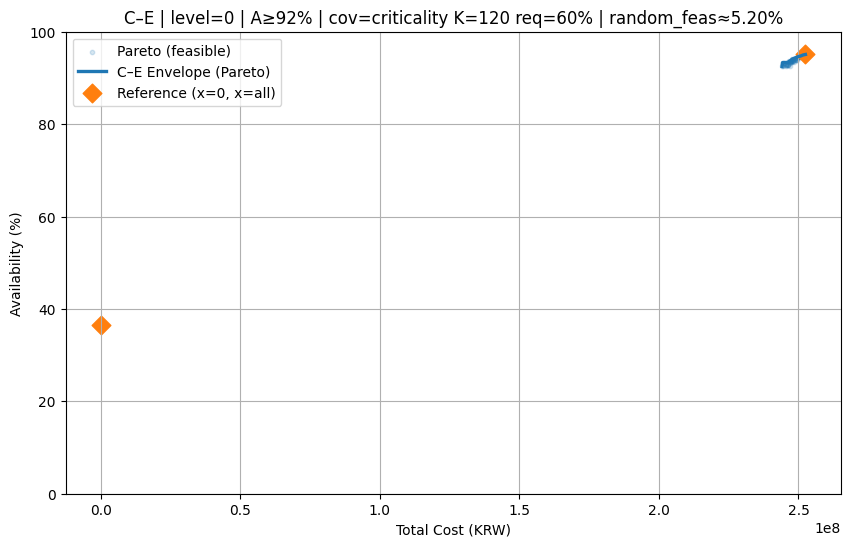


✅ Accepted configuration:
- level: 0
- A_MIN: 0.92
- cov_mode: criticality
- cov_set_k: 120
- cov_req: 0.6
- feas_rate_random: 0.052

Reference:
A(x=0)  : 36.48% | Cost: 0
A(x=all): 95.07% | Cost: 252,488,644

Pareto summary:
Pareto count: 51
Avail min/max: 92.47 ~ 95.07
Cost  min/max: 244,124,777 ~ 252,488,644


In [58]:
import numpy as np
import sys, time
import matplotlib.pyplot as plt

from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.core.problem import Problem
from pymoo.optimize import minimize
from pymoo.termination import get_termination
from pymoo.core.sampling import Sampling


# ============================================================
# 0) Utilities
# ============================================================
def force_print(*args):
    print(*args)
    sys.stdout.flush()

def winsorize(x, p_low=1, p_high=99):
    x = np.asarray(x, float)
    lo = np.nanpercentile(x, p_low)
    hi = np.nanpercentile(x, p_high)
    return np.clip(x, lo, hi)

def zscore(x):
    x = np.asarray(x, float)
    mu = np.nanmean(x)
    sd = np.nanstd(x)
    if not np.isfinite(sd) or sd == 0:
        return np.zeros_like(x)
    return (x - mu) / sd

def safe01(x):
    x = np.asarray(x, float)
    x = np.where(np.isfinite(x), x, 0.0)
    mn, mx = np.min(x), np.max(x)
    if mx - mn < 1e-12:
        return np.zeros_like(x)
    return (x - mn) / (mx - mn)

def envelope(cost, eff):
    order = np.argsort(cost)
    cost = cost[order]; eff = eff[order]
    envC, envE, best = [], [], -1e18
    for c,e in zip(cost, eff):
        if e > best + 1e-9:
            envC.append(c); envE.append(e); best = e
    return np.array(envC), np.array(envE)

def pick_max_eff_under_budget(cost, eff, budget):
    idx = np.where(cost <= budget)[0]
    if len(idx) == 0:
        return None
    best = np.max(eff[idx])
    cand = idx[np.where(eff[idx] == best)[0]]
    return int(cand[np.argmin(cost[cand])])


# ============================================================
# 1) Coverage set re-definition + fail/LT scaling normalization
#    - 핵심: raw fail_yr, LT_hr가 "극단값" 때문에 상위 TOPK가 너무 빡세질 수 있어
#            -> 로그 + winsorize + z-score로 "criticality score" 만든 뒤 coverage 정의
# ============================================================
def build_coverage_sets(fail_yr_raw, LT_hr_raw, mode="criticality", k=80, q=0.90):
    """
    mode:
      - "topk_fail_lt": fail TOPK + LT TOPK (전통 방식)
      - "criticality": criticality score 상위 TOPK
      - "quantile": criticality score 상위 q-quantile (비율 기반)
    """

    # robust scaling
    fail_w = winsorize(fail_yr_raw, 1, 99)
    lt_w   = winsorize(LT_hr_raw, 1, 99)

    fail_s = zscore(np.log1p(np.maximum(fail_w, 0)))
    lt_s   = zscore(np.log1p(np.maximum(lt_w, 0)))

    crit = fail_s + lt_s
    crit = np.where(np.isfinite(crit), crit, 0.0)

    if mode == "topk_fail_lt":
        idx_fail = np.argsort(-fail_yr_raw)[:k]
        idx_lt   = np.argsort(-LT_hr_raw)[:k]
        return idx_fail, idx_lt, crit

    if mode == "criticality":
        idx = np.argsort(-crit)[:k]
        # 같은 집합을 fail-coverage, lt-coverage로 같이 사용(=현실적으로 “치명 부품군” 커버)
        return idx, idx, crit

    if mode == "quantile":
        thr = np.quantile(crit, q)
        idx = np.where(crit >= thr)[0]
        if len(idx) < 10:  # 너무 작아지면 최소 확보
            idx = np.argsort(-crit)[:max(10, k)]
        return idx, idx, crit

    raise ValueError("Unknown mode")


# ============================================================
# 2) Improved initialization: 균등 선택률 sampling
#    - pop의 선택률이 50% 근처로만 몰리면 coverage/A feasible 영역을 못 찾음
# ============================================================
class UniformSelectionSampling(Sampling):
    def __init__(self, n_var, bins=12, min_ratio=0.0, max_ratio=1.0, seed=1234):
        super().__init__()
        self.n_var = n_var
        self.bins = bins
        self.min_ratio = min_ratio
        self.max_ratio = max_ratio
        self.rng = np.random.default_rng(seed)

    def _do(self, problem, n_samples, **kwargs):
        X = np.zeros((n_samples, self.n_var), dtype=int)

        # bins별로 selection ratio를 골고루 배정
        ratios = np.linspace(self.min_ratio, self.max_ratio, self.bins)
        for i in range(n_samples):
            r = float(ratios[i % self.bins])
            k = int(round(r * self.n_var))
            if k > 0:
                idx = self.rng.choice(self.n_var, size=k, replace=False)
                X[i, idx] = 1
        return X


# ============================================================
# 3) Debug: feasibility rate quick check
# ============================================================
def debug_feasible_rate(A_MIN, idx_cov_fail, idx_cov_lt, COV_FAIL, COV_LT, n_samples=400, seed=7):
    rng = np.random.default_rng(seed)

    def cov_fail(x):
        x = np.asarray(x, int)
        return float(np.mean(x[idx_cov_fail]))

    def cov_lt(x):
        x = np.asarray(x, int)
        return float(np.mean(x[idx_cov_lt]))

    # references
    x0 = np.zeros(N, dtype=int)
    x1 = np.ones(N, dtype=int)
    A0 = availability_proxy(x0)
    A1 = availability_proxy(x1)
    cf1, cl1 = cov_fail(x1), cov_lt(x1)

    force_print("\n" + "="*80)
    force_print(f"DEBUG | A_MIN={A_MIN:.2f}, cov_fail≥{COV_FAIL:.2f} (|set|={len(idx_cov_fail)}), cov_lt≥{COV_LT:.2f} (|set|={len(idx_cov_lt)})")
    force_print(f"A(x=0)   = {A0*100:.2f}%")
    force_print(f"A(x=all) = {A1*100:.2f}%")
    force_print(f"cov_fail(x=all)={cf1:.3f} (should be 1.000)")
    force_print(f"cov_lt(x=all)  ={cl1:.3f} (should be 1.000)")

    if not np.isfinite(A1) or A1 < A_MIN - 1e-12:
        force_print("❌ IMPOSSIBLE: even x=all violates A_MIN. (need relax availability model or A_MIN)")
        return 0.0

    # sample wide ratios
    feas = 0
    valid = 0
    badA = 0
    badObj = 0

    for _ in range(n_samples):
        ratio = rng.uniform(0, 1)
        k = int(round(ratio * N))
        x = np.zeros(N, dtype=int)
        if k > 0:
            idx = rng.choice(N, size=k, replace=False)
            x[idx] = 1

        A = availability_proxy(x)
        if not np.isfinite(A):
            badA += 1
            continue

        cf = cov_fail(x)
        cl = cov_lt(x)

        r = risk_obj_n(x); s = supply_obj_n(x); m = maint_obj_n(x); c = float(np.clip(cost_norm(x),0,1))
        if not (np.isfinite(r) and np.isfinite(s) and np.isfinite(m) and np.isfinite(c)):
            badObj += 1
            continue

        valid += 1
        if (A >= A_MIN - 1e-12) and (cf >= COV_FAIL - 1e-12) and (cl >= COV_LT - 1e-12):
            feas += 1

    rate = 0.0 if valid == 0 else feas / valid
    force_print(f"DEBUG | random feasible rate: {rate*100:.2f}% (valid={valid}/{n_samples}), badA={badA}, badObj={badObj}")
    force_print("="*80)
    return rate


# ============================================================
# 4) Availability parameter levels (너가 확인했던 그대로)
# ============================================================
def set_params(level=0):
    global FIXED_DOWNTIME_H_PER_YEAR, ADMIN_H_PER_FAIL, MTTR_MIN_H
    global KAPPA_MAINT, KAPPA_Q, USE_QUEUEING
    global ETA_WAIT, ETA_CM, ETA_LAMBDA_REDUCTION

    if level == 0:
        FIXED_DOWNTIME_H_PER_YEAR = 400.0
        ADMIN_H_PER_FAIL = 24.0
        MTTR_MIN_H = 24.0
        KAPPA_MAINT = 0.0012
        KAPPA_Q = 0.0010
        USE_QUEUEING = True
        ETA_WAIT = 0.75
        ETA_CM = 0.20
        ETA_LAMBDA_REDUCTION = 0.75

    elif level == 1:
        FIXED_DOWNTIME_H_PER_YEAR = 200.0
        ADMIN_H_PER_FAIL = 16.0
        MTTR_MIN_H = 18.0
        KAPPA_MAINT = 0.0009
        KAPPA_Q = 0.0005
        USE_QUEUEING = True
        ETA_WAIT = 0.85
        ETA_CM = 0.30
        ETA_LAMBDA_REDUCTION = 0.80

    elif level == 2:
        FIXED_DOWNTIME_H_PER_YEAR = 100.0
        ADMIN_H_PER_FAIL = 8.0
        MTTR_MIN_H = 12.0
        KAPPA_MAINT = 0.0006
        KAPPA_Q = 0.0
        USE_QUEUEING = False
        ETA_WAIT = 0.90
        ETA_CM = 0.40
        ETA_LAMBDA_REDUCTION = 0.85


# ============================================================
# 5) Auto-relax loop configs
#    - coverage는 "criticality-based"를 기본으로 (현실 설득력↑, feasible↑)
# ============================================================
A_MIN_SCHEDULE = [0.92, 0.90, 0.88, 0.85]
# (k, cov) 스케줄
COV_SCHEDULE = [
    (120, 0.60),
    (100, 0.55),
    (80,  0.50),
    (60,  0.45),
    (40,  0.40),
]

POP = 260
NGEN = 10
SEED0 = 42

BUDGETS = [100_000_000, 150_000_000, 200_000_000]


# ============================================================
# 6) Main: auto-relax + debug + improved sampling
# ============================================================
best_res = None
best_cfg = None

for level in [0, 1, 2]:
    set_params(level)
    Ax0 = availability_proxy(np.zeros(N))*100
    Ax1 = availability_proxy(np.ones(N))*100
    force_print("\n" + "#"*90)
    force_print(f"[PARAM LEVEL {level}] A(x=0)={Ax0:.2f}%, A(x=all)={Ax1:.2f}%")
    force_print("#"*90)

    for A_MIN in A_MIN_SCHEDULE:
        for (k_cov, cov_req) in COV_SCHEDULE:

            # ---- coverage set build (criticality-based)
            idx_fail, idx_lt, crit = build_coverage_sets(
                fail_yr, LT_hr,
                mode="criticality",  # ✅ 핵심 변경: TOPK가 아니라 치명도(score) 기준
                k=k_cov,
                q=0.90
            )
            COV_FAIL = cov_req
            COV_LT   = cov_req

            # ---- debug feasibility rate (before expensive NSGA)
            rate = debug_feasible_rate(A_MIN, idx_fail, idx_lt, COV_FAIL, COV_LT, n_samples=500, seed=SEED0)

            # feasible가 완전 0이면 NSGA 돌려봐야 시간만 잡아먹음 → 스킵
            if rate == 0.0:
                force_print("SKIP: random feasible rate = 0% -> relax further")
                continue

            # ---- coverage functions
            def cov_fail(x):
                x = np.asarray(x, int)
                return float(np.mean(x[idx_fail]))

            def cov_lt(x):
                x = np.asarray(x, int)
                return float(np.mean(x[idx_lt]))

            def cost_norm_clamped(x):
                return float(np.clip(cost_norm(x), 0.0, 1.0))

            class SpareNSGA4_Constrained(Problem):
                def __init__(self):
                    super().__init__(n_var=N, n_obj=4, n_constr=3, xl=0, xu=1, type_var=int)

                def _evaluate(self, X, out, *args, **kwargs):
                    F = np.zeros((len(X), 4))
                    G = np.zeros((len(X), 3))
                    for i, x in enumerate(X):
                        F[i,0] = risk_obj_n(x)
                        F[i,1] = supply_obj_n(x)
                        F[i,2] = maint_obj_n(x)
                        F[i,3] = cost_norm_clamped(x)

                        A = availability_proxy(x)
                        G[i,0] = A_MIN - A
                        G[i,1] = COV_FAIL - cov_fail(x)
                        G[i,2] = COV_LT   - cov_lt(x)
                    out["F"] = F
                    out["G"] = G

            # ---- Improved sampling: selection ratio uniform
            sampling = UniformSelectionSampling(n_var=N, bins=14, seed=SEED0 + level*100 + int(A_MIN*100) + k_cov)

            algorithm = NSGA2(pop_size=POP, sampling=sampling)
            termination = get_termination("n_gen", NGEN)

            force_print(f"\nRUN NSGA | level={level} | A_MIN={A_MIN:.2f} | "
                        f"covSetK={k_cov} covReq={cov_req:.2f} | init=uniform-ratio")
            t0 = time.time()

            res = minimize(
                SpareNSGA4_Constrained(),
                algorithm,
                termination,
                seed=SEED0 + level*10 + int(A_MIN*100) + k_cov,
                verbose=True
            )

            force_print(f"NSGA DONE in {time.time()-t0:.1f}s")

            X_pf = res.X
            n_pf = 0 if X_pf is None else len(X_pf)
            force_print("→ Feasible Pareto count:", n_pf)

            if X_pf is not None and len(X_pf) > 0:
                best_res = res
                best_cfg = {
                    "level": level,
                    "A_MIN": A_MIN,
                    "cov_mode": "criticality",
                    "cov_set_k": k_cov,
                    "cov_req": cov_req,
                    "idx_fail": idx_fail,
                    "idx_lt": idx_lt,
                    "feas_rate_random": rate
                }
                break

        if best_res is not None:
            break
    if best_res is not None:
        break


if best_res is None:
    raise RuntimeError(
        "자동완화(파라미터/제약/초기화/coverage 재정의) 후에도 feasible Pareto가 0개입니다.\n"
        "다음 확인 필요:\n"
        " - availability_proxy 내부에서 NaN/inf 발생 여부(디버그에서 badA가 큰지)\n"
        " - fail_yr, LT_hr가 거의 전부 0 또는 상수인지\n"
        " - risk_obj_n/supply_obj_n/maint_obj_n가 NaN을 내는지"
    )


# ============================================================
# 7) Plot Pareto-only C–E (no saturation), y 0~100
# ============================================================
set_params(best_cfg["level"])
X_pf = best_res.X

Cost_pf = np.array([cost_krw(x) for x in X_pf], float)
Avail_pf = np.array([availability_proxy(x) for x in X_pf], float) * 100.0
envC, envA = envelope(Cost_pf, Avail_pf)

# references
c0 = cost_krw(np.zeros(N)); a0 = availability_proxy(np.zeros(N))*100
c1 = cost_krw(np.ones(N));  a1 = availability_proxy(np.ones(N))*100

idx_budget = {B: pick_max_eff_under_budget(Cost_pf, Avail_pf, B) for B in BUDGETS}

plt.figure(figsize=(10,6))
plt.scatter(Cost_pf, Avail_pf, s=10, alpha=0.18, label="Pareto (feasible)")
plt.plot(envC, envA, linewidth=2.4, label="C–E Envelope (Pareto)")
plt.scatter([c0, c1], [a0, a1], s=90, marker="D", label="Reference (x=0, x=all)")
for B, idx in idx_budget.items():
    if idx is not None:
        plt.scatter([Cost_pf[idx]], [Avail_pf[idx]], s=150, marker="o",
                    label=f"Pick: max A ≤ {B/1e6:.0f}M")

plt.ylim(0, 100)
plt.xlabel("Total Cost (KRW)")
plt.ylabel("Availability (%)")
plt.title(
    f"C–E | level={best_cfg['level']} | A≥{best_cfg['A_MIN']*100:.0f}% | "
    f"cov={best_cfg['cov_mode']} K={best_cfg['cov_set_k']} req={best_cfg['cov_req']*100:.0f}% | "
    f"random_feas≈{best_cfg['feas_rate_random']*100:.2f}%"
)
plt.grid(True)
plt.legend(loc="best")
plt.show()

force_print("\n✅ Accepted configuration:")
for k,v in best_cfg.items():
    if k.startswith("idx_"):
        continue
    force_print(f"- {k}: {v}")

force_print("\nReference:")
force_print(f"A(x=0)  : {a0:.2f}% | Cost: {c0:,.0f}")
force_print(f"A(x=all): {a1:.2f}% | Cost: {c1:,.0f}")

force_print("\nPareto summary:")
force_print("Pareto count:", len(X_pf))
force_print("Avail min/max:", round(float(Avail_pf.min()),2), "~", round(float(Avail_pf.max()),2))
force_print("Cost  min/max:", f"{float(Cost_pf.min()):,.0f}", "~", f"{float(Cost_pf.max()):,.0f}")



####################################################################################################
PARAM LEVEL 0 | A(x=0)=36.48% | A(x=all)=95.07%
####################################################################################################

DEBUG | A_MIN=0.92 | cov_fail≥0.35 | cov_lt≥0.35
A(x=0)   = 36.48%
A(x=all) = 95.07%
cov_fail(x=all)=1.000 (should be 1.000)
cov_lt(x=all)  =1.000 (should be 1.000)
DEBUG | random feasible rate: 4.57% (valid=350/350) | badA=0 badObj=0

DEBUG | A_MIN=0.92 | cov_fail≥0.35 | cov_lt≥0.35
A(x=0)   = 36.48%
A(x=all) = 95.07%
cov_fail(x=all)=1.000 (should be 1.000)
cov_lt(x=all)  =1.000 (should be 1.000)
DEBUG | random feasible rate: 5.14% (valid=350/350) | badA=0 badObj=0

DEBUG | A_MIN=0.92 | cov_fail≥0.35 | cov_lt≥0.35
A(x=0)   = 36.48%
A(x=all) = 95.07%
cov_fail(x=all)=1.000 (should be 1.000)
cov_lt(x=all)  =1.000 (should be 1.000)
DEBUG | random feasible rate: 5.14% (valid=350/350) | badA=0 badObj=0

DEBUG | A_MIN=0.92 | cov_fail≥0.45 | cov

,variant,level,A_MIN,K,req,weight_pow,random_feas_rate,pf_count,cost_min,cost_max,A_env_min,A_env_max,A_span_env,cost_span_log,score
0,split,2,0.92,120,0.60,NaN,0.108571,71,2.001422e+08,252488644.0,92.113209,98.814929,6.701719,0.354405,2.375126
1,weighted,2,0.92,80,0.60,1.0,0.108571,55,2.032328e+08,252488644.0,92.059202,98.814929,6.755727,0.350706,2.369271
2,weighted,2,0.92,120,0.35,2.0,0.140000,72,2.033657e+08,252488644.0,92.306566,98.814929,6.508363,0.350548,2.281496
3,split,2,0.92,80,0.55,NaN,0.134286,54,1.997759e+08,252488644.0,92.424018,98.814929,6.390910,0.354849,2.267811
4,weighted,2,0.92,100,0.55,1.0,0.154286,78,2.278149e+08,252488644.0,92.043259,98.814929,6.771669,0.323934,2.193572
5,weighted,2,0.92,80,0.55,2.0,0.120000,80,2.019169e+08,252488644.0,92.634358,98.814929,6.180571,0.352271,2.177235
6,weighted,2,0.92,120,0.35,1.0,0.151429,77,2.250484e+08,252488644.0,92.190473,98.814929,6.624456,0.326731,2.164416
7,split,2,0.92,120,0.45,NaN,0.108571,88,2.295086e+08,252488644.0,92.099903,98.814929,6.715025,0.322246,2.163887
8,weighted,2,0.92,100,0.45,1.0,0.154286,60,2.040952e+08,252488644.0,92.646759,98.814929,6.168170,0.349688,2.156933
9,weighted,2,0.92,40,0.55,1.0,0.114286,68,2.272645e+08,252488644.0,92.212423,98.814929,6.602505,0.324486,2.142422



------------------------------------------------------------------------------------------
FULL NSGA: split | L2 K=120 req=0.60

------------------------------------------------------------------------------------------
FULL NSGA: weighted(p=1) | L2 K=80 req=0.60

------------------------------------------------------------------------------------------
FULL NSGA: weighted(p=2) | L2 K=120 req=0.35

------------------------------------------------------------------------------------------
FULL NSGA: split | L2 K=80 req=0.55

------------------------------------------------------------------------------------------
FULL NSGA: weighted(p=1) | L2 K=100 req=0.55

------------------------------------------------------------------------------------------
FULL NSGA: weighted(p=2) | L2 K=80 req=0.55


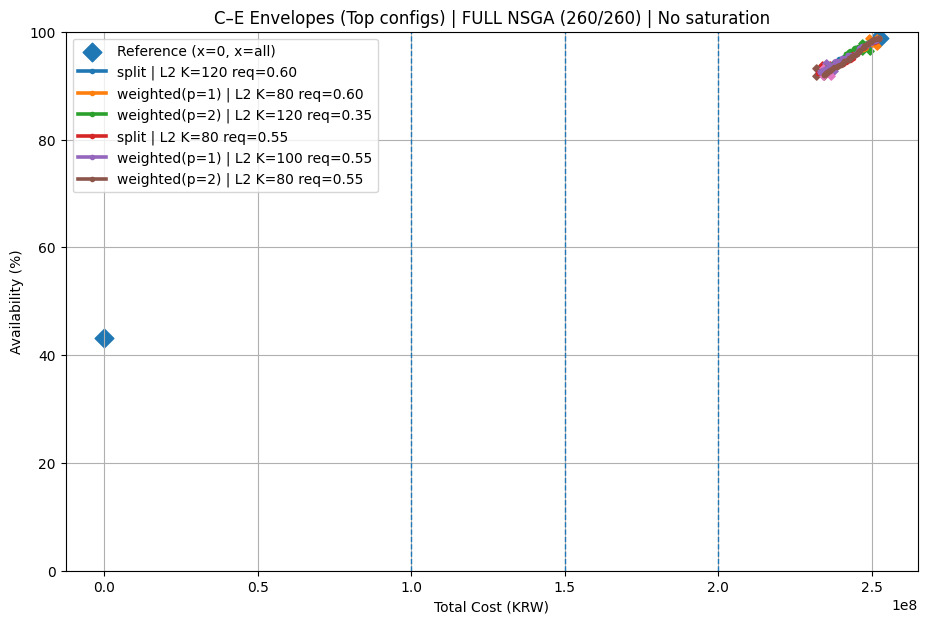


=== Picks under budgets (for each FULL curve) ===

 split | L2 K=120 req=0.60
  - ≤100M: none
  - ≤150M: none
  - ≤200M: none

 weighted(p=1) | L2 K=80 req=0.60
  - ≤100M: none
  - ≤150M: none
  - ≤200M: none

 weighted(p=2) | L2 K=120 req=0.35
  - ≤100M: none
  - ≤150M: none
  - ≤200M: none

 split | L2 K=80 req=0.55
  - ≤100M: none
  - ≤150M: none
  - ≤200M: none

 weighted(p=1) | L2 K=100 req=0.55
  - ≤100M: none
  - ≤150M: none
  - ≤200M: none

 weighted(p=2) | L2 K=80 req=0.55
  - ≤100M: none
  - ≤150M: none
  - ≤200M: none

Saved: sweep_results_screening.csv


In [59]:
# ============================================================
# AUTO SWEEP (2 coverage variants) + NSGA-II + C–E Curves
#   Variant A) Split coverage: Fail TOPK + LT TOPK (separate constraints)
#   Variant B) Weighted coverage: importance-weighted coverage (1 constraint per set)
#
# Includes:
#   - Debug feasibility-rate precheck (skip hopeless configs fast)
#   - Improved initialization (uniform selection-ratio sampling)
#   - Auto sweep over (K, req) grid
#   - Runs SHORT NSGA for screening, then FULL NSGA for top configs
#   - Plots top C–E envelopes
#
# Assumes you already have:
#   N, fail_yr, LT_hr, availability_proxy, risk_obj_n, supply_obj_n, maint_obj_n,
#   cost_krw, cost_norm, set_params(level)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys, time

from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.core.problem import Problem
from pymoo.optimize import minimize
from pymoo.termination import get_termination
from pymoo.core.sampling import Sampling


# ---------------------------
# Utils
# ---------------------------
def force_print(*args):
    print(*args)
    sys.stdout.flush()

def winsorize(x, p_low=1, p_high=99):
    x = np.asarray(x, float)
    lo = np.nanpercentile(x, p_low)
    hi = np.nanpercentile(x, p_high)
    return np.clip(x, lo, hi)

def zscore(x):
    x = np.asarray(x, float)
    mu = np.nanmean(x)
    sd = np.nanstd(x)
    if (not np.isfinite(sd)) or sd == 0:
        return np.zeros_like(x)
    return (x - mu) / sd

def envelope(cost, eff):
    order = np.argsort(cost)
    cost = cost[order]; eff = eff[order]
    envC, envE, best = [], [], -1e18
    for c,e in zip(cost, eff):
        if e > best + 1e-9:
            envC.append(c); envE.append(e); best = e
    return np.array(envC), np.array(envE)

def pick_max_eff_under_budget(cost, eff, budget):
    idx = np.where(cost <= budget)[0]
    if len(idx) == 0:
        return None
    best = np.max(eff[idx])
    cand = idx[np.where(eff[idx] == best)[0]]
    return int(cand[np.argmin(cost[cand])])

def cost_norm_clamped(x):
    return float(np.clip(cost_norm(x), 0.0, 1.0))

# ---------------------------
# Improved sampling (uniform selection ratio)
# ---------------------------
class UniformSelectionSampling(Sampling):
    def __init__(self, n_var, bins=14, seed=1234, min_ratio=0.0, max_ratio=1.0):
        super().__init__()
        self.n_var = n_var
        self.bins = bins
        self.rng = np.random.default_rng(seed)
        self.ratios = np.linspace(min_ratio, max_ratio, bins)

    def _do(self, problem, n_samples, **kwargs):
        X = np.zeros((n_samples, self.n_var), dtype=int)
        for i in range(n_samples):
            r = float(self.ratios[i % self.bins])
            k = int(round(r * self.n_var))
            if k > 0:
                idx = self.rng.choice(self.n_var, size=k, replace=False)
                X[i, idx] = 1
        return X

# ---------------------------
# Build coverage sets + weights
# ---------------------------
# Robust “criticality” score for weighting (log+winsor+z)
fail_w = winsorize(fail_yr, 1, 99)
lt_w   = winsorize(LT_hr, 1, 99)
fail_s = zscore(np.log1p(np.maximum(fail_w, 0)))
lt_s   = zscore(np.log1p(np.maximum(lt_w, 0)))
crit = fail_s + lt_s
crit = np.where(np.isfinite(crit), crit, 0.0)

fail_rank = np.argsort(-fail_yr)     # descending raw fail
lt_rank   = np.argsort(-LT_hr)       # descending raw LT
crit_rank = np.argsort(-crit)        # descending criticality

def make_weights_from_rank(idx, power=1.0):
    """
    Weight higher-ranked items more.
    power>1 emphasizes top-most items more.
    """
    L = len(idx)
    # rank 0 highest weight, rank L-1 lowest
    r = np.linspace(1.0, 0.0, L)
    w = (r ** power)
    # avoid all-zero
    if np.sum(w) <= 1e-12:
        w = np.ones(L)
    return w / np.sum(w)

# ---------------------------
# Debug feasibility-rate precheck (fast)
# ---------------------------
def debug_feasible_rate(A_MIN, cov_f_fn, cov_l_fn, COV_FAIL, COV_LT, n_samples=400, seed=7):
    rng = np.random.default_rng(seed)

    x0 = np.zeros(N, dtype=int)
    x1 = np.ones(N, dtype=int)

    A0 = availability_proxy(x0)
    A1 = availability_proxy(x1)
    cf1 = cov_f_fn(x1)
    cl1 = cov_l_fn(x1)

    force_print("\n" + "="*80)
    force_print(f"DEBUG | A_MIN={A_MIN:.2f} | cov_fail≥{COV_FAIL:.2f} | cov_lt≥{COV_LT:.2f}")
    force_print(f"A(x=0)   = {A0*100:.2f}%")
    force_print(f"A(x=all) = {A1*100:.2f}%")
    force_print(f"cov_fail(x=all)={cf1:.3f} (should be 1.000)")
    force_print(f"cov_lt(x=all)  ={cl1:.3f} (should be 1.000)")

    if (not np.isfinite(A1)) or (A1 < A_MIN - 1e-12):
        force_print("❌ IMPOSSIBLE: even x=all violates A_MIN.")
        force_print("="*80)
        return 0.0

    feas, valid, badA, badObj = 0, 0, 0, 0

    for _ in range(n_samples):
        ratio = rng.uniform(0, 1)
        k = int(round(ratio * N))
        x = np.zeros(N, dtype=int)
        if k > 0:
            idx = rng.choice(N, size=k, replace=False)
            x[idx] = 1

        A = availability_proxy(x)
        if not np.isfinite(A):
            badA += 1
            continue

        r = risk_obj_n(x); s = supply_obj_n(x); m = maint_obj_n(x); c = cost_norm_clamped(x)
        if not (np.isfinite(r) and np.isfinite(s) and np.isfinite(m) and np.isfinite(c)):
            badObj += 1
            continue

        valid += 1
        cf = cov_f_fn(x)
        cl = cov_l_fn(x)
        if (A >= A_MIN - 1e-12) and (cf >= COV_FAIL - 1e-12) and (cl >= COV_LT - 1e-12):
            feas += 1

    rate = 0.0 if valid == 0 else feas / valid
    force_print(f"DEBUG | random feasible rate: {rate*100:.2f}% (valid={valid}/{n_samples}) | badA={badA} badObj={badObj}")
    force_print("="*80)
    return rate

# ---------------------------
# NSGA runner
# ---------------------------
def run_nsga_with_constraints(A_MIN, cov_f_fn, cov_l_fn, COV_FAIL, COV_LT, pop=160, ngen=140, seed=42, sampling_seed=777):
    class SpareNSGA4(Problem):
        def __init__(self):
            super().__init__(n_var=N, n_obj=4, n_constr=3, xl=0, xu=1, type_var=int)

        def _evaluate(self, X, out, *args, **kwargs):
            F = np.zeros((len(X), 4))
            G = np.zeros((len(X), 3))  # <=0 feasible
            for i, x in enumerate(X):
                F[i,0] = risk_obj_n(x)
                F[i,1] = supply_obj_n(x)
                F[i,2] = maint_obj_n(x)
                F[i,3] = cost_norm_clamped(x)

                A = availability_proxy(x)
                G[i,0] = A_MIN - A
                G[i,1] = COV_FAIL - cov_f_fn(x)
                G[i,2] = COV_LT   - cov_l_fn(x)
            out["F"] = F
            out["G"] = G

    sampling = UniformSelectionSampling(n_var=N, bins=14, seed=sampling_seed)
    algo = NSGA2(pop_size=pop, sampling=sampling)
    res = minimize(SpareNSGA4(), algo, get_termination("n_gen", ngen), seed=seed, verbose=False)
    return res

def compute_curve_stats(X):
    Cost = np.array([cost_krw(x) for x in X], float)
    Av   = np.array([availability_proxy(x) for x in X], float) * 100.0
    envC, envA = envelope(Cost, Av)
    # knee-ish: max slope change (simple curvature proxy)
    if len(envC) >= 3:
        # finite diff slopes
        s1 = np.diff(envA) / (np.diff(envC) + 1e-12)
        curv = np.abs(np.diff(s1))
        knee_idx = int(np.argmax(curv)) + 1
    else:
        knee_idx = None
    return Cost, Av, envC, envA, knee_idx

# ============================================================
# SWEEP SETTINGS
# ============================================================
PARAM_LEVELS = [0, 1, 2]        # availability parameter sets (you already have set_params)
A_MIN_LIST   = [0.92]           # keep A>=92% as requested; you can add [0.90, 0.92]
K_LIST       = [40, 60, 80, 100, 120]
REQ_LIST     = [0.35, 0.45, 0.55, 0.60]
WEIGHT_POW   = [1.0, 2.0]       # weighted coverage emphasis
BUDGETS      = [100_000_000, 150_000_000, 200_000_000]

# screening vs full
POP_SCREEN, NGEN_SCREEN = 140, 10
POP_FULL,   NGEN_FULL   = 260, 260

# keep top configs for full run
TOP_M_FOR_FULL = 6

# ============================================================
# Variant builders
# ============================================================
def make_variant_split(K, req):
    # Fail TOPK & LT TOPK separately
    idx_f = fail_rank[:K]
    idx_l = lt_rank[:K]
    def cov_f(x):
        x = np.asarray(x, int)
        return float(np.mean(x[idx_f]))
    def cov_l(x):
        x = np.asarray(x, int)
        return float(np.mean(x[idx_l]))
    return cov_f, cov_l, {"K_fail": K, "K_lt": K, "req": req, "variant": "split", "weight_pow": None}

def make_variant_weighted(K, req, wpow):
    # Use criticality TOPK set, but “weighted coverage” so few top items can satisfy more
    idx = crit_rank[:K]
    w = make_weights_from_rank(idx, power=wpow)
    w = np.asarray(w, float)

    def cov_w(x):
        x = np.asarray(x, int)
        # weighted fraction covered
        return float(np.sum(w * x[idx]) / (np.sum(w) + 1e-12))

    # treat as both fail/lt constraints same (so use same fn twice)
    return cov_w, cov_w, {"K_crit": K, "req": req, "variant": "weighted", "weight_pow": wpow}

# ============================================================
# SWEEP
# ============================================================
results = []

for level in PARAM_LEVELS:
    set_params(level)
    Ax0 = availability_proxy(np.zeros(N))*100
    Ax1 = availability_proxy(np.ones(N))*100
    force_print("\n" + "#"*100)
    force_print(f"PARAM LEVEL {level} | A(x=0)={Ax0:.2f}% | A(x=all)={Ax1:.2f}%")
    force_print("#"*100)

    for A_MIN in A_MIN_LIST:
        for K in K_LIST:
            for req in REQ_LIST:
                # --- Variant A: split
                cov_f, cov_l, meta = make_variant_split(K, req)
                rate = debug_feasible_rate(A_MIN, cov_f, cov_l, req, req, n_samples=350, seed=1000+level+K)
                if rate > 0:
                    res = run_nsga_with_constraints(
                        A_MIN, cov_f, cov_l, req, req,
                        pop=POP_SCREEN, ngen=NGEN_SCREEN,
                        seed=42 + level*100 + K*10 + int(req*100),
                        sampling_seed=777 + level*1000 + K*10 + int(req*100)
                    )
                    X = res.X
                    n_pf = 0 if X is None else len(X)
                    if X is not None and len(X) > 0:
                        Cost, Av, envC, envA, knee = compute_curve_stats(X)
                        results.append({
                            "variant": meta["variant"],
                            "level": level,
                            "A_MIN": A_MIN,
                            "K": K,
                            "req": req,
                            "weight_pow": np.nan,
                            "random_feas_rate": rate,
                            "pf_count": n_pf,
                            "cost_min": float(np.min(Cost)),
                            "cost_max": float(np.max(Cost)),
                            "A_min_pf": float(np.min(Av)),
                            "A_max_pf": float(np.max(Av)),
                            "A_env_min": float(np.min(envA)),
                            "A_env_max": float(np.max(envA)),
                            "env_len": int(len(envA)),
                            "knee_cost": float(envC[knee]) if knee is not None else np.nan,
                            "knee_A": float(envA[knee]) if knee is not None else np.nan,
                            "res_screen": res,      # keep for possible reuse
                            "cov_f": cov_f, "cov_l": cov_l
                        })

                # --- Variant B: weighted
                for wp in WEIGHT_POW:
                    cov_f2, cov_l2, meta2 = make_variant_weighted(K, req, wp)
                    rate2 = debug_feasible_rate(A_MIN, cov_f2, cov_l2, req, req, n_samples=350, seed=2000+level+K+int(wp*10))
                    if rate2 == 0:
                        continue
                    res2 = run_nsga_with_constraints(
                        A_MIN, cov_f2, cov_l2, req, req,
                        pop=POP_SCREEN, ngen=NGEN_SCREEN,
                        seed=99 + level*100 + K*10 + int(req*100) + int(wp*10),
                        sampling_seed=999 + level*1000 + K*10 + int(req*100) + int(wp*10)
                    )
                    X2 = res2.X
                    n_pf2 = 0 if X2 is None else len(X2)
                    if X2 is not None and len(X2) > 0:
                        Cost2, Av2, envC2, envA2, knee2 = compute_curve_stats(X2)
                        results.append({
                            "variant": meta2["variant"],
                            "level": level,
                            "A_MIN": A_MIN,
                            "K": K,
                            "req": req,
                            "weight_pow": wp,
                            "random_feas_rate": rate2,
                            "pf_count": n_pf2,
                            "cost_min": float(np.min(Cost2)),
                            "cost_max": float(np.max(Cost2)),
                            "A_min_pf": float(np.min(Av2)),
                            "A_max_pf": float(np.max(Av2)),
                            "A_env_min": float(np.min(envA2)),
                            "A_env_max": float(np.max(envA2)),
                            "env_len": int(len(envA2)),
                            "knee_cost": float(envC2[knee2]) if knee2 is not None else np.nan,
                            "knee_A": float(envA2[knee2]) if knee2 is not None else np.nan,
                            "res_screen": res2,
                            "cov_f": cov_f2, "cov_l": cov_l2
                        })

df_res = pd.DataFrame(results)
if len(df_res) == 0:
    raise RuntimeError("All configs failed (no feasible Pareto). Try relaxing req or K, or include A_MIN=0.90.")

# ------------------------------------------------------------
# Rank configs for "useful" C–E: want wider cost range & envelope height
#   score: (A_env_max - A_env_min) * log10(1 + cost_max/cost_min)
# ------------------------------------------------------------
df_res["cost_span_log"] = np.log10(1.0 + df_res["cost_max"] / np.maximum(1.0, df_res["cost_min"]))
df_res["A_span_env"] = df_res["A_env_max"] - df_res["A_env_min"]
df_res["score"] = df_res["A_span_env"] * df_res["cost_span_log"]

df_res = df_res.sort_values("score", ascending=False).reset_index(drop=True)

force_print("\n✅ Sweep summary (top 20 by score):")
display(df_res.head(20)[[
    "variant","level","A_MIN","K","req","weight_pow",
    "random_feas_rate","pf_count",
    "cost_min","cost_max","A_env_min","A_env_max","A_span_env","cost_span_log","score"
]])

# ------------------------------------------------------------
# Choose top M configs, rerun FULL NSGA (260/260) for final plots
# ------------------------------------------------------------
topM = df_res.head(TOP_M_FOR_FULL).copy()
final_curves = []

for i, row in topM.iterrows():
    level = int(row["level"])
    set_params(level)
    A_MIN = float(row["A_MIN"])
    K = int(row["K"])
    req = float(row["req"])
    var = row["variant"]
    wp = row["weight_pow"]

    if var == "split":
        cov_f, cov_l, _ = make_variant_split(K, req)
        label = f"split | L{level} K={K} req={req:.2f}"
        seed = 4242 + i
    else:
        wp = float(wp)
        cov_f, cov_l, _ = make_variant_weighted(K, req, wp)
        label = f"weighted(p={wp:.0f}) | L{level} K={K} req={req:.2f}"
        seed = 5252 + i

    force_print("\n" + "-"*90)
    force_print("FULL NSGA:", label)

    res_full = run_nsga_with_constraints(
        A_MIN, cov_f, cov_l, req, req,
        pop=POP_FULL, ngen=NGEN_FULL,
        seed=seed,
        sampling_seed=77777 + i*10
    )
    Xf = res_full.X
    if Xf is None or len(Xf) == 0:
        force_print("⚠️ Full run returned 0 Pareto (unexpected). Skipping.")
        continue

    Cost, Av, envC, envA, knee = compute_curve_stats(Xf)

    final_curves.append({
        "label": label,
        "variant": var,
        "level": level,
        "A_MIN": A_MIN,
        "K": K, "req": req,
        "weight_pow": wp if var=="weighted" else np.nan,
        "X": Xf,
        "Cost": Cost, "Av": Av,
        "envC": envC, "envA": envA,
        "knee_idx": knee
    })

# ------------------------------------------------------------
# Plot: Top curves envelopes
# ------------------------------------------------------------
plt.figure(figsize=(11,7))

# reference points
c0 = cost_krw(np.zeros(N)); a0 = availability_proxy(np.zeros(N))*100
c1 = cost_krw(np.ones(N));  a1 = availability_proxy(np.ones(N))*100
plt.scatter([c0, c1], [a0, a1], s=90, marker="D", label="Reference (x=0, x=all)")

for cur in final_curves[:min(6, len(final_curves))]:
    plt.plot(cur["envC"], cur["envA"], linewidth=2.6, marker="o", markersize=3, label=cur["label"])
    if cur["knee_idx"] is not None:
        k = cur["knee_idx"]
        plt.scatter([cur["envC"][k]], [cur["envA"][k]], s=120, marker="X")

# budgets: show vertical lines
for B in BUDGETS:
    plt.axvline(B, linestyle="--", linewidth=1)

plt.ylim(0, 100)
plt.xlabel("Total Cost (KRW)")
plt.ylabel("Availability (%)")
plt.title("C–E Envelopes (Top configs) | FULL NSGA (260/260) | No saturation")
plt.grid(True)
plt.legend(loc="best")
plt.show()

# ------------------------------------------------------------
# Print best picks under budgets for each final curve
# ------------------------------------------------------------
force_print("\n=== Picks under budgets (for each FULL curve) ===")
for cur in final_curves:
    Cost = cur["Cost"]; Av = cur["Av"]; X = cur["X"]
    force_print("\n", cur["label"])
    for B in BUDGETS:
        idx = pick_max_eff_under_budget(Cost, Av, B)
        if idx is None:
            force_print(f"  - ≤{B/1e6:.0f}M: none")
        else:
            force_print(f"  - ≤{B/1e6:.0f}M: Cost={Cost[idx]:,.0f} | A={Av[idx]:.2f}% | parts={int(np.sum(X[idx]))}")

# ------------------------------------------------------------
# Save sweep table
# ------------------------------------------------------------
df_res.to_csv("sweep_results_screening.csv", index=False)
force_print("\nSaved: sweep_results_screening.csv")


cov_fail(x=all)= 1.0  (should be 1.0)
cov_lt(x=all)  = 1.0  (should be 1.0)

RUN NSGA (coverage-only) ...
n_gen  |  n_eval  | n_nds  |     cv_min    |     cv_avg    |      eps      |   indicator  
     1 |      225 |     28 |  0.000000E+00 |  0.2421666667 |             - |             -
     2 |      485 |     62 |  0.000000E+00 |  0.0023557692 |  0.2713649063 |         ideal
     3 |      745 |     84 |  0.000000E+00 |  0.000000E+00 |  0.0522252828 |         nadir
     4 |     1005 |    105 |  0.000000E+00 |  0.000000E+00 |  0.0267443982 |             f
     5 |     1265 |    107 |  0.000000E+00 |  0.000000E+00 |  0.0188667610 |             f
     6 |     1525 |    114 |  0.000000E+00 |  0.000000E+00 |  0.0198663843 |         nadir
     7 |     1785 |    117 |  0.000000E+00 |  0.000000E+00 |  0.0097780934 |             f
     8 |     2045 |    124 |  0.000000E+00 |  0.000000E+00 |  0.0098288994 |             f
     9 |     2305 |    132 |  0.000000E+00 |  0.000000E+00 |  0.0093027327 

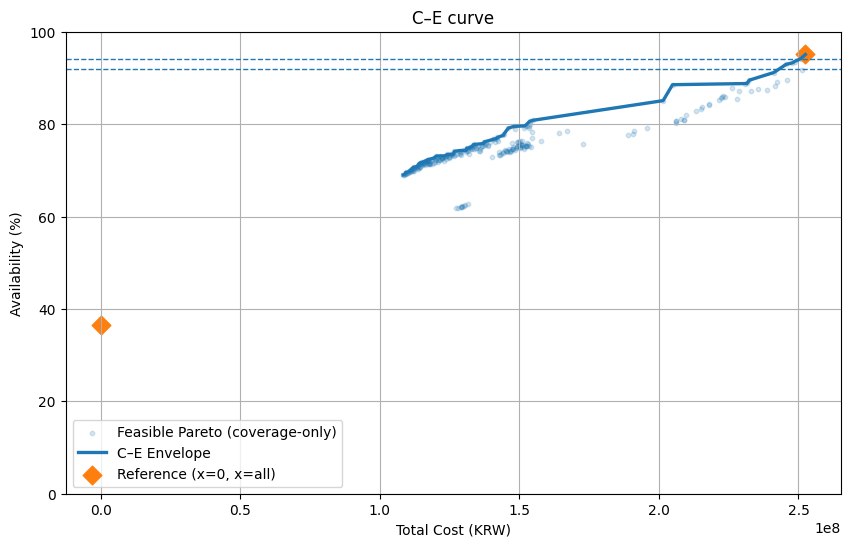


Saved: contract_spares_min_cost_92_94.csv, contract_spares_min_cost_92_94.xlsx
Exported parts: 509
Sum Line_Cost_KRW: 117,641,762


In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys, time

from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.core.problem import Problem
from pymoo.optimize import minimize
from pymoo.termination import get_termination
from pymoo.core.sampling import Sampling


# ---------------------------
# 0) Helpers
# ---------------------------
def force_print(*args):
    print(*args)
    sys.stdout.flush()

def envelope(cost, eff):
    order = np.argsort(cost)
    cost = cost[order]; eff = eff[order]
    envC, envE, best = [], [], -1e18
    for c,e in zip(cost, eff):
        if e > best + 1e-9:
            envC.append(c); envE.append(e); best = e
    return np.array(envC), np.array(envE)

class UniformSelectionSampling(Sampling):
    """균등 selection-ratio 초기화"""
    def __init__(self, n_var, bins=14, seed=1234, min_ratio=0.0, max_ratio=1.0):
        super().__init__()
        self.n_var = n_var
        self.bins = bins
        self.rng = np.random.default_rng(seed)
        self.ratios = np.linspace(min_ratio, max_ratio, bins)

    def _do(self, problem, n_samples, **kwargs):
        X = np.zeros((n_samples, self.n_var), dtype=int)
        for i in range(n_samples):
            r = float(self.ratios[i % self.bins])
            k = int(round(r * self.n_var))
            if k > 0:
                idx = self.rng.choice(self.n_var, size=k, replace=False)
                X[i, idx] = 1
        return X

def detect_part_id_column(df):
    # 가능한 식별 컬럼 후보들
    candidates = ["Part_ID","PART_ID","part_id","NSN","Nsn","Item","ITEM","Name","PartName","Part_Number","PartNo"]
    for c in candidates:
        if c in df.columns:
            return c
    return None


# ---------------------------
# 1) Coverage (choose ONE)
#    - split: fail TOPK + LT TOPK (recommended for contract realism)
#    - weighted criticality: (optional)
# ---------------------------
fail_rank = np.argsort(-fail_yr)     # descending raw fail
lt_rank   = np.argsort(-LT_hr)       # descending raw LT

def make_cov_split(K_fail=80, K_lt=80, req_fail=0.50, req_lt=0.50):
    idx_f = fail_rank[:K_fail]
    idx_l = lt_rank[:K_lt]
    def cov_f(x):
        x = np.asarray(x, int)
        return float(np.mean(x[idx_f]))
    def cov_l(x):
        x = np.asarray(x, int)
        return float(np.mean(x[idx_l]))
    return cov_f, cov_l, req_fail, req_lt, {"mode":"split", "K_fail":K_fail, "K_lt":K_lt, "req_fail":req_fail, "req_lt":req_lt}

# ✅ 여기서 네가 원하는 coverage 파라미터를 넣어
cov_f, cov_l, REQ_F, REQ_L, COV_META = make_cov_split(K_fail=80, K_lt=80, req_fail=0.50, req_lt=0.50)

def debug_cov_sanity():
    x1 = np.ones(N, dtype=int)
    force_print("cov_fail(x=all)=", cov_f(x1), " (should be 1.0)")
    force_print("cov_lt(x=all)  =", cov_l(x1), " (should be 1.0)")
debug_cov_sanity()


# ---------------------------
# 2) Run NSGA WITHOUT A_MIN constraint
#    - constraint only: coverage
#    - objective: risk, supply, maint, cost_norm
# ---------------------------
def cost_norm_clamped(x):
    return float(np.clip(cost_norm(x), 0.0, 1.0))

class SpareNSGA4_CoverageOnly(Problem):
    def __init__(self):
        super().__init__(n_var=N, n_obj=4, n_constr=2, xl=0, xu=1, type_var=int)

    def _evaluate(self, X, out, *args, **kwargs):
        F = np.zeros((len(X), 4))
        G = np.zeros((len(X), 2))  # <=0 feasible
        for i, x in enumerate(X):
            F[i,0] = risk_obj_n(x)
            F[i,1] = supply_obj_n(x)
            F[i,2] = maint_obj_n(x)
            F[i,3] = cost_norm_clamped(x)

            G[i,0] = REQ_F - cov_f(x)
            G[i,1] = REQ_L - cov_l(x)

        out["F"] = F
        out["G"] = G


# ✅ 파라미터 level 선택 (지금은 네가 쓰던 level=0 유지해도 됨)
LEVEL = 0
set_params(LEVEL)

POP, NGEN = 260, 260
sampling = UniformSelectionSampling(n_var=N, bins=14, seed=2026)

force_print("\nRUN NSGA (coverage-only) ...")
t0 = time.time()
res = minimize(
    SpareNSGA4_CoverageOnly(),
    NSGA2(pop_size=POP, sampling=sampling),
    get_termination("n_gen", NGEN),
    seed=42,
    verbose=True
)
force_print(f"NSGA DONE in {time.time()-t0:.1f}s")

X = res.X
if X is None or len(X)==0:
    raise RuntimeError("No feasible solutions under coverage-only constraints. Relax coverage (K/req) first.")

force_print("Feasible Pareto count:", len(X))


# ---------------------------
# 3) Compute metrics for ALL Pareto solutions
# ---------------------------
Cost = np.array([cost_krw(x) for x in X], float)
Avail = np.array([availability_proxy(x) for x in X], float) * 100.0
Risk = np.array([risk_obj_n(x) for x in X], float)
Supp = np.array([supply_obj_n(x) for x in X], float)
Maint= np.array([maint_obj_n(x) for x in X], float)

df_pf = pd.DataFrame({
    "Cost_KRW": Cost,
    "Avail_pct": Avail,
    "Risk": Risk,
    "Supply": Supp,
    "Maint": Maint,
    "n_parts": [int(np.sum(x)) for x in X],
})

force_print("\nPareto summary:")
force_print(df_pf[["Cost_KRW","Avail_pct","n_parts","Risk","Supply","Maint"]].describe())


# ---------------------------
# 4) Contract candidates in Avail band [92, 94]
#    - Pick 1) min cost in band
#    - Pick 2) min risk in band
#    - Pick 3) best balance (min z-score sum) in band
#    - Also budget-based: best avail under budget (optional)
# ---------------------------
LOW, HIGH = 92.0, 94.0
band_idx = np.where((df_pf["Avail_pct"] >= LOW) & (df_pf["Avail_pct"] <= HIGH))[0]

if len(band_idx) == 0:
    force_print(f"\n⚠️ No solutions in {LOW}-{HIGH}% band. Try relax coverage or run more generations/POP.")
else:
    band = df_pf.iloc[band_idx].copy()

    # 1) minimum cost in band
    i_min_cost = band_idx[int(np.argmin(band["Cost_KRW"].values))]

    # 2) minimum risk in band
    i_min_risk = band_idx[int(np.argmin(band["Risk"].values))]

    # 3) balanced: z-score of (Cost, Risk, Supply, Maint) -> minimize sum
    cols = ["Cost_KRW","Risk","Supply","Maint"]
    z = (band[cols] - band[cols].mean()) / (band[cols].std(ddof=0) + 1e-12)
    i_bal = band_idx[int(np.argmin(z.sum(axis=1).values))]

    picks = {
        "min_cost_in_92_94": i_min_cost,
        "min_risk_in_92_94": i_min_risk,
        "balanced_in_92_94": i_bal
    }

    force_print("\n✅ Picks in 92–94% band:")
    for name, idx in picks.items():
        row = df_pf.iloc[idx]
        force_print(f"- {name:18s} | Cost={row.Cost_KRW:,.0f} | A={row.Avail_pct:.2f}% | parts={row.n_parts} "
                    f"| Risk={row.Risk:.4f} | Supply={row.Supply:.4f} | Maint={row.Maint:.4f}")


# ---------------------------
# 5) Plot (for persuasion later): full CE scatter + envelope
#    - not “desired curve shaping” yet, but shows A from low to high (if exists)
# ---------------------------
envC, envA = envelope(Cost, Avail)

plt.figure(figsize=(10,6))
plt.scatter(Cost, Avail, s=10, alpha=0.18, label="Feasible Pareto (coverage-only)")
plt.plot(envC, envA, linewidth=2.4, label="C–E Envelope")

# highlight band
plt.axhline(LOW, linestyle="--", linewidth=1)
plt.axhline(HIGH, linestyle="--", linewidth=1)

# reference
c0 = cost_krw(np.zeros(N)); a0 = availability_proxy(np.zeros(N))*100
c1 = cost_krw(np.ones(N));  a1 = availability_proxy(np.ones(N))*100
plt.scatter([c0, c1], [a0, a1], s=90, marker="D", label="Reference (x=0, x=all)")

plt.ylim(0, 100)
plt.xlabel("Total Cost (KRW)")
plt.ylabel("Availability (%)")
plt.title(f"C–E curve")
plt.grid(True)
plt.legend(loc="best")
plt.show()


# ---------------------------
# 6) Export spares list for chosen pick (min_cost_in_92_94 by default)
# ---------------------------
part_id_col = detect_part_id_column(df)

def export_spares(idx, tag):
    x = X[idx]
    sel = np.where(x == 1)[0]
    out = df.iloc[sel].copy()

    # Add key metrics
    out["Selected"] = 1
    out["Pick_Tag"] = tag
    out["Total_Cost_KRW"] = float(df_pf.iloc[idx]["Cost_KRW"])
    out["Avail_pct"] = float(df_pf.iloc[idx]["Avail_pct"])

    # ensure unit price column
    price_col = None
    for c in ["Unit_Price_KRW","unit_price_KRW","unit_price_krw","UnitPriceKRW"]:
        if c in out.columns:
            price_col = c
            break

    # compute qty=1 (binary) and cost line
    out["Qty"] = 1
    if price_col is not None:
        out["Line_Cost_KRW"] = pd.to_numeric(out[price_col], errors="coerce").fillna(0.0) * out["Qty"]

    # file names
    csv_name = f"contract_spares_{tag}.csv"
    xlsx_name = f"contract_spares_{tag}.xlsx"

    out.to_csv(csv_name, index=False, encoding="utf-8-sig")
    out.to_excel(xlsx_name, index=False)

    force_print(f"\nSaved: {csv_name}, {xlsx_name}")
    return csv_name, xlsx_name, out

# export default pick if exists
if len(band_idx) > 0:
    default_idx = picks["min_cost_in_92_94"]
    csv_name, xlsx_name, out_df = export_spares(default_idx, "min_cost_92_94")
    # show quick summary
    force_print("Exported parts:", len(out_df))
    if "Line_Cost_KRW" in out_df.columns:
        force_print("Sum Line_Cost_KRW:", f"{out_df['Line_Cost_KRW'].sum():,.0f}")
else:
    force_print("\nNo 92–94% solution -> nothing exported.")


sanity cov_fail(x=all) = 1.0 should be 1.0
sanity cov_lt(x=all)   = 1.0 should be 1.0

RUN sweep req=0.10 | coverage: fail top80, lt top80 | level=0
n_gen  |  n_eval  | n_nds  |     cv_min    |     cv_avg    |      eps      |   indicator  
     1 |      225 |     53 |  0.000000E+00 |  0.0062222222 |             - |             -
     2 |      485 |     80 |  0.000000E+00 |  0.000000E+00 |  0.0396057587 |         ideal
     3 |      745 |    108 |  0.000000E+00 |  0.000000E+00 |  0.1772588282 |         ideal
     4 |     1005 |    162 |  0.000000E+00 |  0.000000E+00 |  0.0029170807 |         ideal
     5 |     1265 |    210 |  0.000000E+00 |  0.000000E+00 |  0.0035520063 |         nadir
     6 |     1525 |    247 |  0.000000E+00 |  0.000000E+00 |  0.0250743982 |         ideal
     7 |     1785 |    260 |  0.000000E+00 |  0.000000E+00 |  0.0304397849 |         nadir
     8 |     2045 |    260 |  0.000000E+00 |  0.000000E+00 |  0.0421284488 |         nadir
     9 |     2305 |    260 |  0.

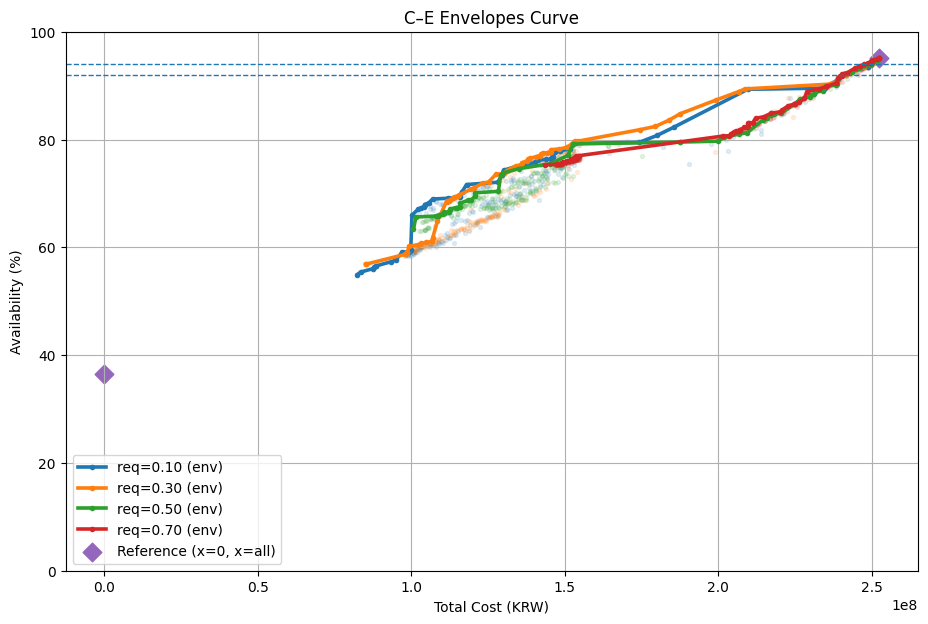

,req,pick,Cost_KRW,Avail_pct,n_parts,Risk,Supply,Maint,band_count,band_A_range,band_cost_range
0,0.1,min_cost,2.431949e+08,92.579486,961,0.419325,0.482531,-2.294347,4,92.33~93.74,"243,194,861~249,085,689"
2,0.1,balanced,2.449348e+08,92.332071,968,0.434781,0.403424,-2.332337,4,92.33~93.74,"243,194,861~249,085,689"
1,0.1,min_risk,2.431949e+08,92.579486,961,0.419325,0.482531,-2.294347,4,92.33~93.74,"243,194,861~249,085,689"
3,0.3,min_cost,2.416475e+08,92.035008,955,0.434038,0.387533,-2.255533,3,92.04~93.53,"241,647,501~247,591,745"
5,0.3,balanced,2.416475e+08,92.035008,955,0.434038,0.387533,-2.255533,3,92.04~93.53,"241,647,501~247,591,745"
4,0.3,min_risk,2.416475e+08,92.035008,955,0.434038,0.387533,-2.255533,3,92.04~93.53,"241,647,501~247,591,745"
6,0.5,min_cost,2.409062e+08,92.230736,954,0.419252,0.425446,-2.265082,6,92.23~93.75,"240,906,220~249,823,134"
8,0.5,balanced,2.409062e+08,92.230736,954,0.419252,0.425446,-2.265082,6,92.23~93.75,"240,906,220~249,823,134"
7,0.5,min_risk,2.409062e+08,92.230736,954,0.419252,0.425446,-2.265082,6,92.23~93.75,"240,906,220~249,823,134"
9,0.7,min_cost,2.402003e+08,92.107449,960,0.465575,0.366796,-2.296570,23,92.11~93.94,"240,200,348~249,372,323"



Saved: contract_candidates_92_94_by_req.csv

DONE.
Outputs:
- stitched plot with multiple envelopes (req sweep)
- contract_candidates_92_94_by_req.csv
- multiple contract_spares_reqXX_min_cost_92_94.(csv/xlsx) files


In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys, time

from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.core.problem import Problem
from pymoo.optimize import minimize
from pymoo.termination import get_termination
from pymoo.core.sampling import Sampling


# ============================================================
# 0) 필수 전제(이미 존재해야 함)
# ------------------------------------------------------------
# N, df
# availability_proxy(x) -> [0..1]
# risk_obj_n(x), supply_obj_n(x), maint_obj_n(x) -> normalized objective (smaller better)
# cost_krw(x), cost_norm(x)
# set_params(level)
# fail_yr, LT_hr
# ============================================================

# ---------------------------
# Utilities
# ---------------------------
def force_print(*args):
    print(*args)
    sys.stdout.flush()

def envelope(cost, eff):
    order = np.argsort(cost)
    cost = cost[order]; eff = eff[order]
    envC, envE, best = [], [], -1e18
    for c,e in zip(cost, eff):
        if e > best + 1e-9:
            envC.append(c); envE.append(e); best = e
    return np.array(envC), np.array(envE)

def detect_part_id_column(df):
    candidates = ["Part_ID","PART_ID","part_id","NSN","Nsn","Item","ITEM","Name","PartName","Part_Number","PartNo"]
    for c in candidates:
        if c in df.columns:
            return c
    return None

class UniformSelectionSampling(Sampling):
    """selection ratio를 0~1 범위에서 균등하게 깔아주는 초기화"""
    def __init__(self, n_var, bins=14, seed=1234, min_ratio=0.0, max_ratio=1.0):
        super().__init__()
        self.n_var = n_var
        self.bins = bins
        self.rng = np.random.default_rng(seed)
        self.ratios = np.linspace(min_ratio, max_ratio, bins)

    def _do(self, problem, n_samples, **kwargs):
        X = np.zeros((n_samples, self.n_var), dtype=int)
        for i in range(n_samples):
            r = float(self.ratios[i % self.bins])
            k = int(round(r * self.n_var))
            if k > 0:
                idx = self.rng.choice(self.n_var, size=k, replace=False)
                X[i, idx] = 1
        return X

def cost_norm_clamped(x):
    return float(np.clip(cost_norm(x), 0.0, 1.0))


# ============================================================
# 1) Coverage 정의 (split: Fail TOPK + LT TOPK)
#    - req만 단계별로 스윕 (초기 급상승~포화 모양 유도에 유리)
# ============================================================
fail_rank = np.argsort(-fail_yr)   # desc
lt_rank   = np.argsort(-LT_hr)     # desc

def make_cov_split(K_fail=80, K_lt=80):
    idx_f = fail_rank[:K_fail]
    idx_l = lt_rank[:K_lt]

    def cov_f(x):
        x = np.asarray(x, int)
        return float(np.mean(x[idx_f]))

    def cov_l(x):
        x = np.asarray(x, int)
        return float(np.mean(x[idx_l]))

    return cov_f, cov_l, idx_f, idx_l

# ✅ 여기서 TOPK는 너가 원하면 바꿔도 됨
K_FAIL = 80
K_LT   = 80
cov_f, cov_l, idx_fail, idx_lt = make_cov_split(K_FAIL, K_LT)

# sanity
x_all = np.ones(N, dtype=int)
force_print("sanity cov_fail(x=all) =", cov_f(x_all), "should be 1.0")
force_print("sanity cov_lt(x=all)   =", cov_l(x_all), "should be 1.0")


# ============================================================
# 2) NSGA Problem (Coverage-only; A_min 없음)
# ============================================================
class SpareNSGA4_CoverageOnly(Problem):
    def __init__(self, req_fail, req_lt):
        super().__init__(n_var=N, n_obj=4, n_constr=2, xl=0, xu=1, type_var=int)
        self.req_fail = float(req_fail)
        self.req_lt = float(req_lt)

    def _evaluate(self, X, out, *args, **kwargs):
        F = np.zeros((len(X), 4))
        G = np.zeros((len(X), 2))  # <=0 feasible

        for i, x in enumerate(X):
            F[i,0] = risk_obj_n(x)
            F[i,1] = supply_obj_n(x)
            F[i,2] = maint_obj_n(x)
            F[i,3] = cost_norm_clamped(x)

            G[i,0] = self.req_fail - cov_f(x)
            G[i,1] = self.req_lt   - cov_l(x)

        out["F"] = F
        out["G"] = G


def run_nsga_coverage_only(req_fail, req_lt, level=0, pop=260, ngen=260, seed=42, sampling_seed=2026):
    set_params(level)
    problem = SpareNSGA4_CoverageOnly(req_fail=req_fail, req_lt=req_lt)
    sampling = UniformSelectionSampling(n_var=N, bins=14, seed=sampling_seed)
    algo = NSGA2(pop_size=pop, sampling=sampling)

    res = minimize(problem, algo, get_termination("n_gen", ngen), seed=seed, verbose=True)
    return res


# ============================================================
# 3) Candidate selection inside 92~94 band + export
# ============================================================
def pick_contract_candidates(X, df_pf, low=92.0, high=94.0):
    band_idx = np.where((df_pf["Avail_pct"] >= low) & (df_pf["Avail_pct"] <= high))[0]
    if len(band_idx) == 0:
        return None

    band = df_pf.iloc[band_idx].copy()

    # (1) min cost
    i_min_cost = band_idx[int(np.argmin(band["Cost_KRW"].values))]
    # (2) min risk
    i_min_risk = band_idx[int(np.argmin(band["Risk"].values))]
    # (3) balanced: zsum(cost,risk,supply,maint)
    cols = ["Cost_KRW","Risk","Supply","Maint"]
    z = (band[cols] - band[cols].mean()) / (band[cols].std(ddof=0) + 1e-12)
    i_bal = band_idx[int(np.argmin(z.sum(axis=1).values))]

    return {
        "min_cost": i_min_cost,
        "min_risk": i_min_risk,
        "balanced": i_bal,
        "band_count": len(band_idx),
        "band_min_cost": float(band["Cost_KRW"].min()),
        "band_max_cost": float(band["Cost_KRW"].max()),
        "band_min_A": float(band["Avail_pct"].min()),
        "band_max_A": float(band["Avail_pct"].max()),
    }

def export_spares_from_solution(x, df, tag):
    sel = np.where(np.asarray(x, int) == 1)[0]
    out = df.iloc[sel].copy()

    # identify part id col
    pid = detect_part_id_column(df)
    if pid is None:
        out.insert(0, "Part_Index", sel)

    # qty=1 (binary)
    out["Qty"] = 1

    # unit price col
    price_col = None
    for c in ["Unit_Price_KRW","unit_price_KRW","unit_price_krw","UnitPriceKRW"]:
        if c in out.columns:
            price_col = c
            break
    if price_col is not None:
        out["Unit_Price_KRW_used"] = pd.to_numeric(out[price_col], errors="coerce").fillna(0.0)
        out["Line_Cost_KRW"] = out["Unit_Price_KRW_used"] * out["Qty"]

    csv_name = f"contract_spares_{tag}.csv"
    xlsx_name = f"contract_spares_{tag}.xlsx"
    out.to_csv(csv_name, index=False, encoding="utf-8-sig")
    out.to_excel(xlsx_name, index=False)
    return csv_name, xlsx_name, out


# ============================================================
# 4) RUN: sweep req levels + plot stitched envelopes + contract table + exports
# ============================================================
LEVEL = 0          # availability param level
POP, NGEN = 260, 260

# ✅ 단계별 coverage req (설득용: 낮은 req→높은 req)
REQ_LEVELS = [0.10, 0.30, 0.50, 0.70]   # 원하면 [0.05,0.15,0.3,0.5,0.7]로 더 촘촘히

LOW_A, HIGH_A = 92.0, 94.0

all_runs = []
contract_rows = []

# references
c0 = cost_krw(np.zeros(N)); a0 = availability_proxy(np.zeros(N))*100
c1 = cost_krw(np.ones(N));  a1 = availability_proxy(np.ones(N))*100

for j, req in enumerate(REQ_LEVELS):
    force_print("\n" + "="*90)
    force_print(f"RUN sweep req={req:.2f} | coverage: fail top{K_FAIL}, lt top{K_LT} | level={LEVEL}")
    force_print("="*90)

    res = run_nsga_coverage_only(
        req_fail=req, req_lt=req,
        level=LEVEL,
        pop=POP, ngen=NGEN,
        seed=42 + j,
        sampling_seed=2026 + j
    )

    X = res.X
    if X is None or len(X) == 0:
        force_print(f"⚠️ req={req:.2f}: no feasible solutions (coverage too strict).")
        continue

    # metrics
    Cost = np.array([cost_krw(x) for x in X], float)
    Av   = np.array([availability_proxy(x) for x in X], float) * 100.0
    df_pf = pd.DataFrame({
        "Cost_KRW": Cost,
        "Avail_pct": Av,
        "Risk": np.array([risk_obj_n(x) for x in X], float),
        "Supply": np.array([supply_obj_n(x) for x in X], float),
        "Maint": np.array([maint_obj_n(x) for x in X], float),
        "n_parts": [int(np.sum(x)) for x in X],
    })

    envC, envA = envelope(Cost, Av)

    # store for plot
    all_runs.append({
        "req": req,
        "X": X,
        "df_pf": df_pf,
        "envC": envC,
        "envA": envA,
        "pareto_count": len(X),
        "avail_min": float(np.min(Av)),
        "avail_max": float(np.max(Av)),
        "cost_min": float(np.min(Cost)),
        "cost_max": float(np.max(Cost)),
    })

    # pick contract candidates in 92~94
    picks = pick_contract_candidates(X, df_pf, low=LOW_A, high=HIGH_A)
    if picks is None:
        contract_rows.append({
            "req": req,
            "pareto_count": len(X),
            "band_count": 0,
            "note": "no solutions in 92–94 band"
        })
        continue

    # add rows for each pick type
    for pick_name, idx in [("min_cost", picks["min_cost"]),
                           ("min_risk", picks["min_risk"]),
                           ("balanced", picks["balanced"])]:
        row = df_pf.iloc[idx]
        contract_rows.append({
            "req": req,
            "pick": pick_name,
            "Cost_KRW": float(row["Cost_KRW"]),
            "Avail_pct": float(row["Avail_pct"]),
            "n_parts": int(row["n_parts"]),
            "Risk": float(row["Risk"]),
            "Supply": float(row["Supply"]),
            "Maint": float(row["Maint"]),
            "band_count": int(picks["band_count"]),
            "band_A_range": f"{picks['band_min_A']:.2f}~{picks['band_max_A']:.2f}",
            "band_cost_range": f"{picks['band_min_cost']:,.0f}~{picks['band_max_cost']:,.0f}",
        })

    # export only min_cost pick (계약안 기본)
    idx_export = picks["min_cost"]
    tag = f"req{int(req*100):02d}_min_cost_92_94"
    csv_name, xlsx_name, out_df = export_spares_from_solution(X[idx_export], df, tag=tag)

    force_print(f"✅ Exported (req={req:.2f}) min_cost_92_94:")
    force_print("   -", csv_name)
    force_print("   -", xlsx_name)
    force_print("   - parts:", len(out_df))


# ============================================================
# 5) Plot: stitched envelopes (persuasion plot)
# ============================================================
plt.figure(figsize=(11,7))

# scatter optional: 너무 빽빽하면 주석 처리
for run in all_runs:
    df_pf = run["df_pf"]
    plt.scatter(df_pf["Cost_KRW"], df_pf["Avail_pct"], s=8, alpha=0.12)

for run in all_runs:
    req = run["req"]
    plt.plot(run["envC"], run["envA"], linewidth=2.6, marker="o", markersize=3,
             label=f"req={req:.2f} (env)")

# references
plt.scatter([c0, c1], [a0, a1], s=90, marker="D", label="Reference (x=0, x=all)")
plt.axhline(LOW_A, linestyle="--", linewidth=1)
plt.axhline(HIGH_A, linestyle="--", linewidth=1)

plt.ylim(0, 100)
plt.xlabel("Total Cost (KRW)")
plt.ylabel("Availability (%)")
plt.title(f"C–E Envelopes Curve")
plt.grid(True)
plt.legend(loc="best")
plt.show()


# ============================================================
# 6) Contract table summary (92~94 band)
# ============================================================
df_contract = pd.DataFrame(contract_rows)
if len(df_contract) > 0:
    # 보기 좋게 정렬: req 낮은 것부터, min_cost 우선
    if "pick" in df_contract.columns:
        pick_order = {"min_cost":0, "balanced":1, "min_risk":2}
        df_contract["pick_order"] = df_contract["pick"].map(pick_order).fillna(9).astype(int)
        df_contract = df_contract.sort_values(["req","pick_order","Cost_KRW"], ascending=[True, True, True])
        df_contract = df_contract.drop(columns=["pick_order"], errors="ignore")
    else:
        df_contract = df_contract.sort_values(["req"], ascending=True)

    display(df_contract)

    df_contract.to_csv("contract_candidates_92_94_by_req.csv", index=False, encoding="utf-8-sig")
    force_print("\nSaved: contract_candidates_92_94_by_req.csv")
else:
    force_print("No contract rows produced.")


# ============================================================
# 7) Quick guidance output
# ============================================================
force_print("\nDONE.")
force_print("Outputs:")
force_print("- stitched plot with multiple envelopes (req sweep)")
force_print("- contract_candidates_92_94_by_req.csv")
force_print("- multiple contract_spares_reqXX_min_cost_92_94.(csv/xlsx) files")


In [63]:
from google.colab import files
import pandas as pd
import numpy as np

LOW_A = 92.0
HIGH_A = 94.0

exported_files = []

for run in all_runs:

    req = run["req"]
    X = run["X"]
    df_pf = run["df_pf"]

    # 92~94 구간 찾기
    band_idx = np.where(
        (df_pf["Avail_pct"] >= LOW_A) &
        (df_pf["Avail_pct"] <= HIGH_A)
    )[0]

    if len(band_idx) == 0:
        print(f"req={req:.2f} → 92~94% 구간 없음")
        continue

    # 최소 비용 해 선택
    band = df_pf.iloc[band_idx]
    idx = band_idx[int(np.argmin(band["Cost_KRW"].values))]

    x = X[idx]
    sel = np.where(np.asarray(x, int) == 1)[0]
    out = df.iloc[sel].copy()

    # 단가 컬럼 탐색
    price_col = None
    for c in ["Unit_Price_KRW","unit_price_KRW","unit_price_krw","UnitPriceKRW"]:
        if c in out.columns:
            price_col = c
            break

    out["Qty"] = 1

    if price_col is not None:
        out["Unit_Price_KRW_used"] = pd.to_numeric(out[price_col], errors="coerce").fillna(0.0)
        out["Line_Cost_KRW"] = out["Unit_Price_KRW_used"]

    filename = f"contract_spares_req{int(req*100):02d}_min_cost_92_94.xlsx"

    out.to_excel(filename, index=False)

    exported_files.append(filename)

    print(f"Saved:", filename)
    print("   parts:", len(out))
    print("   total cost:", f"{band['Cost_KRW'].min():,.0f} KRW")

# ----------------------------
# 다운로드
# ----------------------------
for f in exported_files:
    files.download(f)


Saved: contract_spares_req10_min_cost_92_94.xlsx
   parts: 558
   total cost: 243,194,861 KRW
Saved: contract_spares_req30_min_cost_92_94.xlsx
   parts: 555
   total cost: 241,647,501 KRW
Saved: contract_spares_req50_min_cost_92_94.xlsx
   parts: 565
   total cost: 240,906,220 KRW
Saved: contract_spares_req70_min_cost_92_94.xlsx
   parts: 728
   total cost: 240,200,348 KRW


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [64]:
from google.colab import files
import numpy as np
import pandas as pd

LOW_A = 92.0
HIGH_A = 94.0

exported_files = []

for run in all_runs:

    req = run["req"]
    X = run["X"]
    df_pf = run["df_pf"]

    band_idx = np.where(
        (df_pf["Avail_pct"] >= LOW_A) &
        (df_pf["Avail_pct"] <= HIGH_A)
    )[0]

    if len(band_idx) == 0:
        print(f"req={req:.2f} → 92~94% 구간 없음")
        continue

    band = df_pf.iloc[band_idx].copy()

    # ----------------------------
    # 세 가지 선택 기준
    # ----------------------------
    picks = {}

    # 1️⃣ 최소 비용
    idx_min_cost = band_idx[int(np.argmin(band["Cost_KRW"].values))]
    picks["min_cost"] = idx_min_cost

    # 2️⃣ 최소 리스크
    idx_min_risk = band_idx[int(np.argmin(band["Risk"].values))]
    picks["min_risk"] = idx_min_risk

    # 3️⃣ 균형 (z-score 기반)
    cols = ["Cost_KRW","Risk","Supply","Maint"]
    z = (band[cols] - band[cols].mean()) / (band[cols].std(ddof=0) + 1e-12)
    idx_bal = band_idx[int(np.argmin(z.sum(axis=1).values))]
    picks["balanced"] = idx_bal

    # ----------------------------
    # 파일 저장
    # ----------------------------
    for tag, idx in picks.items():

        x = X[idx]
        sel = np.where(np.asarray(x, int) == 1)[0]
        out = df.iloc[sel].copy()

        out["Qty"] = 1

        # 단가 컬럼 자동 탐색
        price_col = None
        for c in ["Unit_Price_KRW","unit_price_KRW","unit_price_krw","UnitPriceKRW"]:
            if c in out.columns:
                price_col = c
                break

        if price_col is not None:
            out["Unit_Price_KRW_used"] = pd.to_numeric(out[price_col], errors="coerce").fillna(0.0)
            out["Line_Cost_KRW"] = out["Unit_Price_KRW_used"]

        filename = f"contract_spares_req{int(req*100):02d}_{tag}_92_94.xlsx"
        out.to_excel(filename, index=False)

        exported_files.append(filename)

        print(f"Saved:", filename)
        print("   parts:", len(out))
        print("   total cost:", f"{df_pf.iloc[idx]['Cost_KRW']:,.0f} KRW")
        print("   availability:", f"{df_pf.iloc[idx]['Avail_pct']:.2f}%")
        print("-"*60)

# ----------------------------
# 다운로드
# ----------------------------
for f in exported_files:
    files.download(f)


Saved: contract_spares_req10_min_cost_92_94.xlsx
   parts: 558
   total cost: 243,194,861 KRW
   availability: 92.58%
------------------------------------------------------------
Saved: contract_spares_req10_min_risk_92_94.xlsx
   parts: 558
   total cost: 243,194,861 KRW
   availability: 92.58%
------------------------------------------------------------
Saved: contract_spares_req10_balanced_92_94.xlsx
   parts: 547
   total cost: 244,934,812 KRW
   availability: 92.33%
------------------------------------------------------------
Saved: contract_spares_req30_min_cost_92_94.xlsx
   parts: 555
   total cost: 241,647,501 KRW
   availability: 92.04%
------------------------------------------------------------
Saved: contract_spares_req30_min_risk_92_94.xlsx
   parts: 555
   total cost: 241,647,501 KRW
   availability: 92.04%
------------------------------------------------------------
Saved: contract_spares_req30_balanced_92_94.xlsx
   parts: 555
   total cost: 241,647,501 KRW
   availabi

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>